In [2]:
print("Parkinson Detection Project")
print("Step 1: Data Understanding")

Parkinson Detection Project
Step 1: Data Understanding


In [3]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]

Python executable:
C:\Users\vatsa\.venv\Scripts\python.exe


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Everything is working!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Everything is working!
NumPy: 2.0.2
Pandas: 2.3.3
Matplotlib: 3.9.4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

NumPy: 2.0.2
Pandas: 2.3.3
Matplotlib: 3.9.4


In [4]:
acc = pd.read_csv(
    r"C:\Users\vatsa\Parkinson_Project\data\u001_w001\accelerometer.log",
    sep="\t"
)

acc.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\vatsa\\Parkinson_Project\\data\\u001_w001\\accelerometer.log'

In [5]:
from pathlib import Path

project_path = Path(r"C:\Users\vatsa\Parkinson_Project")

print("Project exists:", project_path.exists())

print("\nFolders inside project:")
for item in project_path.iterdir():
    print(item)

Project exists: True

Folders inside project:
C:\Users\vatsa\Parkinson_Project\.ipynb_checkpoints
C:\Users\vatsa\Parkinson_Project\01_understand_data.ipynb.ipynb
C:\Users\vatsa\Parkinson_Project\data
C:\Users\vatsa\Parkinson_Project\models
C:\Users\vatsa\Parkinson_Project\notebooks
C:\Users\vatsa\Parkinson_Project\processed
C:\Users\vatsa\Parkinson_Project\results


In [6]:
from pathlib import Path

log_files = list(project_path.rglob("*.log"))

print("Number of .log files found:", len(log_files))

for file in log_files[:20]:
    print(file)

Number of .log files found: 6
C:\Users\vatsa\Parkinson_Project\data\u001_w001\u001_w001_accelerometer.log
C:\Users\vatsa\Parkinson_Project\data\u001_w001\u001_w001_gravity.log
C:\Users\vatsa\Parkinson_Project\data\u001_w001\u001_w001_gyroscope.log
C:\Users\vatsa\Parkinson_Project\data\u001_w001\u001_w001_linearaccelerometer.log
C:\Users\vatsa\Parkinson_Project\data\u001_w001\u001_w001_magnetometer.log
C:\Users\vatsa\Parkinson_Project\data\u001_w001\u001_w001_rotvec.log


In [7]:
from pathlib import Path

data_path = Path(r"C:\Users\vatsa\Parkinson_Project\data")

# Show the first 20 recording folders
folders = sorted([p for p in data_path.iterdir() if p.is_dir()])

print("Number of folders:", len(folders))

for folder in folders[:20]:
    print(folder.name)

Number of folders: 1
u001_w001


In [8]:
sample_folder = data_path / "u001_w001"

print("Folder:", sample_folder)
print("\nFiles inside:")

for file in sorted(sample_folder.iterdir()):
    print(file.name)

Folder: C:\Users\vatsa\Parkinson_Project\data\u001_w001

Files inside:
u001_w001_accelerometer.log
u001_w001_gravity.log
u001_w001_gyroscope.log
u001_w001_linearaccelerometer.log
u001_w001_magnetometer.log
u001_w001_rotvec.log


In [9]:
sensor_files = {}

for file in sample_folder.iterdir():
    name = file.name.lower()

    if "accelerometer" in name:
        sensor_files["accelerometer"] = file
    elif "gyroscope" in name or "gyro" in name:
        sensor_files["gyroscope"] = file
    elif "magnetometer" in name or "magnet" in name:
        sensor_files["magnetometer"] = file

print(sensor_files)

{'accelerometer': WindowsPath('C:/Users/vatsa/Parkinson_Project/data/u001_w001/u001_w001_linearaccelerometer.log'), 'gyroscope': WindowsPath('C:/Users/vatsa/Parkinson_Project/data/u001_w001/u001_w001_gyroscope.log'), 'magnetometer': WindowsPath('C:/Users/vatsa/Parkinson_Project/data/u001_w001/u001_w001_magnetometer.log')}


In [10]:
import pandas as pd

acc = pd.read_csv(
    sensor_files["accelerometer"],
    sep="\t"
)

print(acc.head())

   linearaccelerometer_timestamp  linearaccelerometer_x_data  \
0                924313418840345                    1.242813   
1                924313427141127                    1.117246   
2                924313435441908                    0.912846   
3                924313443742689                    0.874858   
4                924313452043470                    0.834022   

   linearaccelerometer_y_data  linearaccelerometer_z_data  
0                   -0.160181                   -0.900440  
1                   -0.187921                   -1.529893  
2                   -0.192566                   -1.570929  
3                   -0.227208                   -1.453511  
4                   -0.282976                   -1.292671  


In [11]:
print("Shape:", acc.shape)
print("\nColumns:")
print(acc.columns.tolist())

Shape: (32273, 4)

Columns:
['linearaccelerometer_timestamp', 'linearaccelerometer_x_data', 'linearaccelerometer_y_data', 'linearaccelerometer_z_data']


In [12]:
mag = pd.read_csv(
    sensor_files["magnetometer"],
    sep="\t"
)

print(mag.head())
print("\nShape:", mag.shape)
print("\nColumns:")
print(mag.columns.tolist())

   magnetometer_timestamp  magnetometer_x_data  magnetometer_y_data  \
0         924312954759535           -22.257996             0.367737   
1         924312971635756           -22.596740            -0.651550   
2         924312987047133           -23.104858            -0.141907   
3         924313004075941           -23.104858            -0.820923   
4         924313022203383           -22.596740            -1.670837   

   magnetometer_z_data  
0           -42.485046  
1           -44.807434  
2           -43.646240  
3           -42.651367  
4           -43.148804  

Shape: (15985, 4)

Columns:
['magnetometer_timestamp', 'magnetometer_x_data', 'magnetometer_y_data', 'magnetometer_z_data']


In [13]:
gyro = pd.read_csv(
    sensor_files["gyroscope"],
    sep="\t"
)

print(gyro.head())
print("\nShape:", gyro.shape)
print("\nColumns:")
print(gyro.columns.tolist())

   gyroscope_timestamp  gyroscope_x_data  gyroscope_y_data  gyroscope_z_data
0      924313414537367          0.194931         -0.004242          0.163818
1      924313420823988          0.230347          0.091034          0.141846
2      924313425889906          0.242569          0.061722          0.124741
3      924313430925306          0.237686          0.028748          0.113739
4      924313435991224          0.214462         -0.004242          0.102753

Shape: (52900, 4)

Columns:
['gyroscope_timestamp', 'gyroscope_x_data', 'gyroscope_y_data', 'gyroscope_z_data']


In [14]:
print("ACCELEROMETER")
print(acc.isnull().sum())

print("\nMAGNETOMETER")
print(mag.isnull().sum())

if "gyroscope" in sensor_files:
    print("\nGYROSCOPE")
    print(gyro.isnull().sum())

ACCELEROMETER
linearaccelerometer_timestamp    0
linearaccelerometer_x_data       0
linearaccelerometer_y_data       0
linearaccelerometer_z_data       0
dtype: int64

MAGNETOMETER
magnetometer_timestamp    0
magnetometer_x_data       0
magnetometer_y_data       0
magnetometer_z_data       0
dtype: int64

GYROSCOPE
gyroscope_timestamp    0
gyroscope_x_data       0
gyroscope_y_data       0
gyroscope_z_data       0
dtype: int64


In [15]:
print("Accelerometer samples:", len(acc))
print("Magnetometer samples:", len(mag))

if "gyroscope" in sensor_files:
    print("Gyroscope samples:", len(gyro))

Accelerometer samples: 32273
Magnetometer samples: 15985
Gyroscope samples: 52900


In [16]:
print("Accelerometer timestamp:")
print(acc.iloc[0, 0])
print(acc.iloc[-1, 0])

print("\nMagnetometer timestamp:")
print(mag.iloc[0, 0])
print(mag.iloc[-1, 0])

Accelerometer timestamp:
924313418840345
924581301641037

Magnetometer timestamp:
924312954759535
924581307225754


In [17]:
acc_diff = acc.iloc[:, 0].diff().dropna()
mag_diff = mag.iloc[:, 0].diff().dropna()

print("Median accelerometer interval:", acc_diff.median())
print("Median magnetometer interval:", mag_diff.median())

Median accelerometer interval: 8300781.0
Median magnetometer interval: 16815186.0


In [18]:
gyro_diff = gyro.iloc[:, 0].diff().dropna()

print("Median gyroscope interval:", gyro_diff.median())

Median gyroscope interval: 5035400.0


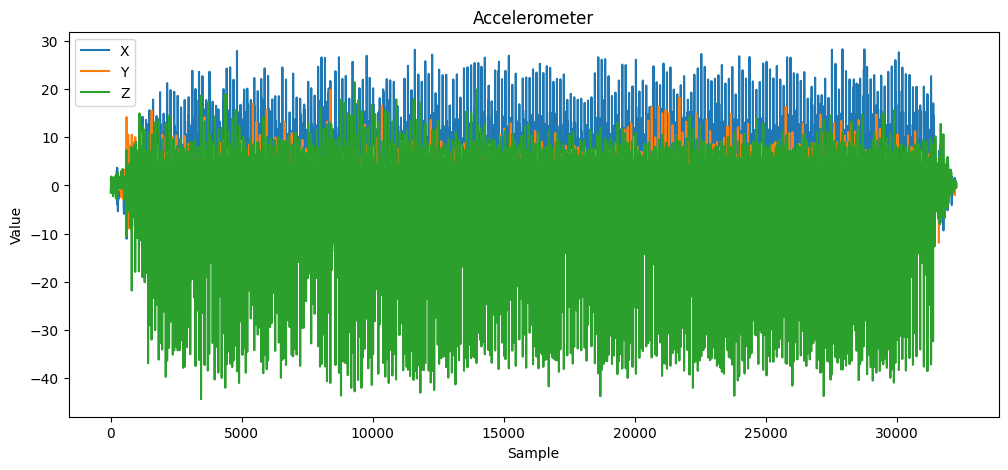

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(acc.iloc[:, 1], label="X")
plt.plot(acc.iloc[:, 2], label="Y")
plt.plot(acc.iloc[:, 3], label="Z")

plt.title("Accelerometer")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.legend()
plt.show()

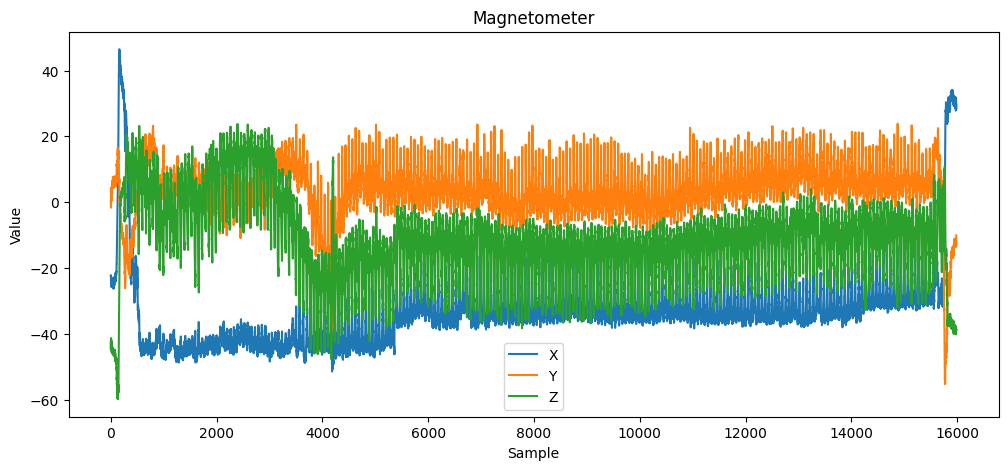

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(mag.iloc[:, 1], label="X")
plt.plot(mag.iloc[:, 2], label="Y")
plt.plot(mag.iloc[:, 3], label="Z")

plt.title("Magnetometer")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.legend()
plt.show()

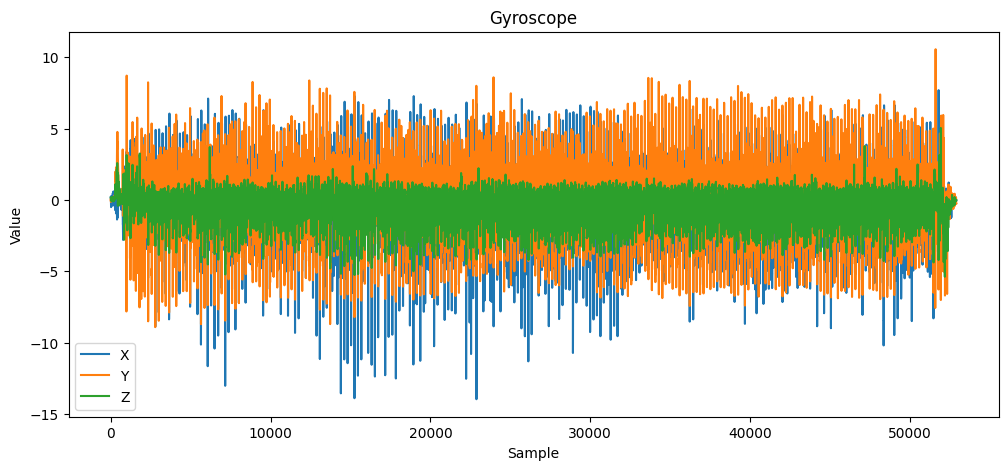

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(gyro.iloc[:, 1], label="X")
plt.plot(gyro.iloc[:, 2], label="Y")
plt.plot(gyro.iloc[:, 3], label="Z")

plt.title("Gyroscope")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.legend()
plt.show()

In [22]:
print(sample_folder)
print([file.name for file in sample_folder.iterdir()])

print(acc.shape)
print(mag.shape)

print(acc.columns.tolist())
print(mag.columns.tolist())

print(acc.isnull().sum())
print(mag.isnull().sum())

print("ACC interval:", acc.iloc[:, 0].diff().median())
print("MAG interval:", mag.iloc[:, 0].diff().median())

C:\Users\vatsa\Parkinson_Project\data\u001_w001
['u001_w001_accelerometer.log', 'u001_w001_gravity.log', 'u001_w001_gyroscope.log', 'u001_w001_linearaccelerometer.log', 'u001_w001_magnetometer.log', 'u001_w001_rotvec.log']
(32273, 4)
(15985, 4)
['linearaccelerometer_timestamp', 'linearaccelerometer_x_data', 'linearaccelerometer_y_data', 'linearaccelerometer_z_data']
['magnetometer_timestamp', 'magnetometer_x_data', 'magnetometer_y_data', 'magnetometer_z_data']
linearaccelerometer_timestamp    0
linearaccelerometer_x_data       0
linearaccelerometer_y_data       0
linearaccelerometer_z_data       0
dtype: int64
magnetometer_timestamp    0
magnetometer_x_data       0
magnetometer_y_data       0
magnetometer_z_data       0
dtype: int64
ACC interval: 8300781.0
MAG interval: 16815186.0


In [23]:
from pathlib import Path

sample_folder = Path(
    r"C:\Users\vatsa\Parkinson_Project\data\u001_w001"
)

print(sample_folder)

C:\Users\vatsa\Parkinson_Project\data\u001_w001


In [24]:
import pandas as pd

files = {
    "accelerometer": sample_folder / "u001_w001_accelerometer.log",
    "gravity": sample_folder / "u001_w001_gravity.log",
    "gyroscope": sample_folder / "u001_w001_gyroscope.log",
    "linear_accelerometer": sample_folder / "u001_w001_linearaccelerometer.log",
    "magnetometer": sample_folder / "u001_w001_magnetometer.log",
    "rotation_vector": sample_folder / "u001_w001_rotvec.log"
}

data = {}

for name, path in files.items():
    data[name] = pd.read_csv(path, sep="\t")
    print(f"{name}: {data[name].shape}")

accelerometer: (31977, 4)
gravity: (32273, 4)
gyroscope: (52900, 4)
linear_accelerometer: (32273, 4)
magnetometer: (15985, 4)
rotation_vector: (32273, 4)


In [25]:
for name, df in data.items():
    print("\n" + "=" * 50)
    print(name)
    print(df.columns.tolist())


accelerometer
['accelerometer_timestamp', 'accelerometer_x_data', 'accelerometer_y_data', 'accelerometer_z_data']

gravity
['gravity_timestamp', 'gravity_x_data', 'gravity_y_data', 'gravity_z_data']

gyroscope
['gyroscope_timestamp', 'gyroscope_x_data', 'gyroscope_y_data', 'gyroscope_z_data']

linear_accelerometer
['linearaccelerometer_timestamp', 'linearaccelerometer_x_data', 'linearaccelerometer_y_data', 'linearaccelerometer_z_data']

magnetometer
['magnetometer_timestamp', 'magnetometer_x_data', 'magnetometer_y_data', 'magnetometer_z_data']

rotation_vector
['rotvec_timestamp', 'rotvec_x_data', 'rotvec_y_data', 'rotvec_z_data']


In [26]:
for name, df in data.items():
    print("\n", name)
    print(df.isnull().sum())


 accelerometer
accelerometer_timestamp    0
accelerometer_x_data       0
accelerometer_y_data       0
accelerometer_z_data       0
dtype: int64

 gravity
gravity_timestamp    0
gravity_x_data       0
gravity_y_data       0
gravity_z_data       0
dtype: int64

 gyroscope
gyroscope_timestamp    0
gyroscope_x_data       0
gyroscope_y_data       0
gyroscope_z_data       0
dtype: int64

 linear_accelerometer
linearaccelerometer_timestamp    0
linearaccelerometer_x_data       0
linearaccelerometer_y_data       0
linearaccelerometer_z_data       0
dtype: int64

 magnetometer
magnetometer_timestamp    0
magnetometer_x_data       0
magnetometer_y_data       0
magnetometer_z_data       0
dtype: int64

 rotation_vector
rotvec_timestamp    0
rotvec_x_data       0
rotvec_y_data       0
rotvec_z_data       0
dtype: int64


In [27]:
for name, df in data.items():

    timestamp = df.iloc[:, 0]

    median_interval = timestamp.diff().median()

    sampling_rate = 1 / (median_interval / 1e9)

    print(
        f"{name:22s} "
        f"interval = {median_interval:.2f} ns   "
        f"sampling rate ≈ {sampling_rate:.2f} Hz"
    )

accelerometer          interval = 8392334.00 ns   sampling rate ≈ 119.16 Hz
gravity                interval = 8300781.00 ns   sampling rate ≈ 120.47 Hz
gyroscope              interval = 5035400.00 ns   sampling rate ≈ 198.59 Hz
linear_accelerometer   interval = 8300781.00 ns   sampling rate ≈ 120.47 Hz
magnetometer           interval = 16815186.00 ns   sampling rate ≈ 59.47 Hz
rotation_vector        interval = 8300781.00 ns   sampling rate ≈ 120.47 Hz


In [28]:
for name, df in data.items():

    timestamp = df.iloc[:, 0]

    duration_seconds = (
        timestamp.iloc[-1] - timestamp.iloc[0]
    ) / 1e9

    print(
        f"{name:22s} "
        f"{duration_seconds:.2f} seconds "
        f"({duration_seconds / 60:.2f} minutes)"
    )

accelerometer          268.35 seconds (4.47 minutes)
gravity                267.88 seconds (4.46 minutes)
gyroscope              267.89 seconds (4.46 minutes)
linear_accelerometer   267.88 seconds (4.46 minutes)
magnetometer           268.35 seconds (4.47 minutes)
rotation_vector        267.88 seconds (4.46 minutes)


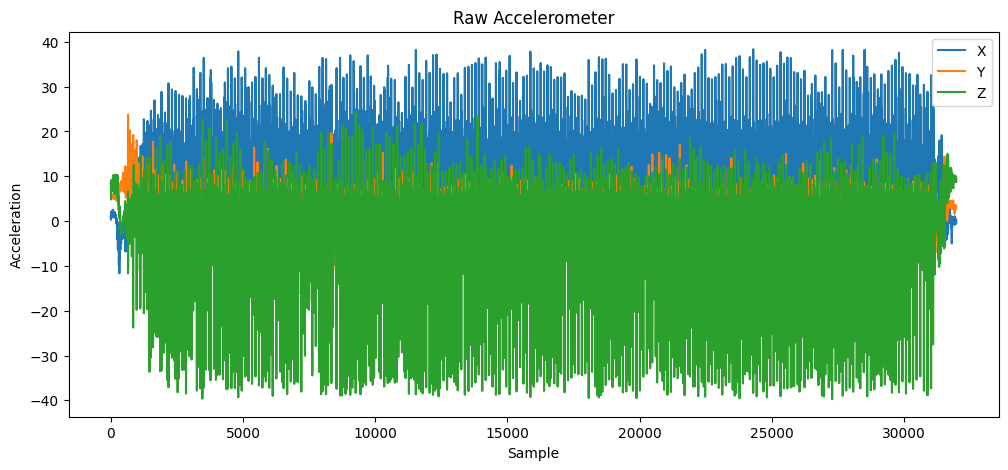

In [29]:
acc = data["accelerometer"]

plt.figure(figsize=(12, 5))

plt.plot(acc.iloc[:, 1], label="X")
plt.plot(acc.iloc[:, 2], label="Y")
plt.plot(acc.iloc[:, 3], label="Z")

plt.title("Raw Accelerometer")
plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.legend()

plt.show()

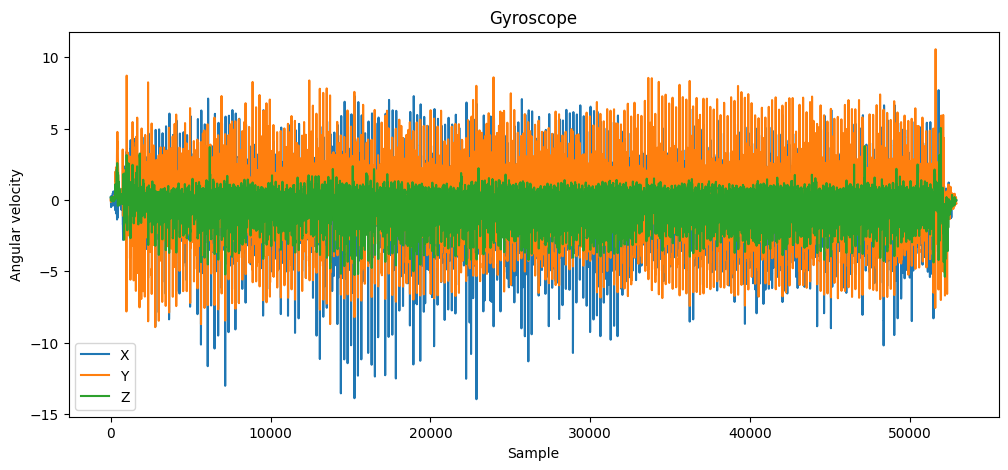

In [30]:
gyro = data["gyroscope"]

plt.figure(figsize=(12, 5))

plt.plot(gyro.iloc[:, 1], label="X")
plt.plot(gyro.iloc[:, 2], label="Y")
plt.plot(gyro.iloc[:, 3], label="Z")

plt.title("Gyroscope")
plt.xlabel("Sample")
plt.ylabel("Angular velocity")
plt.legend()

plt.show()

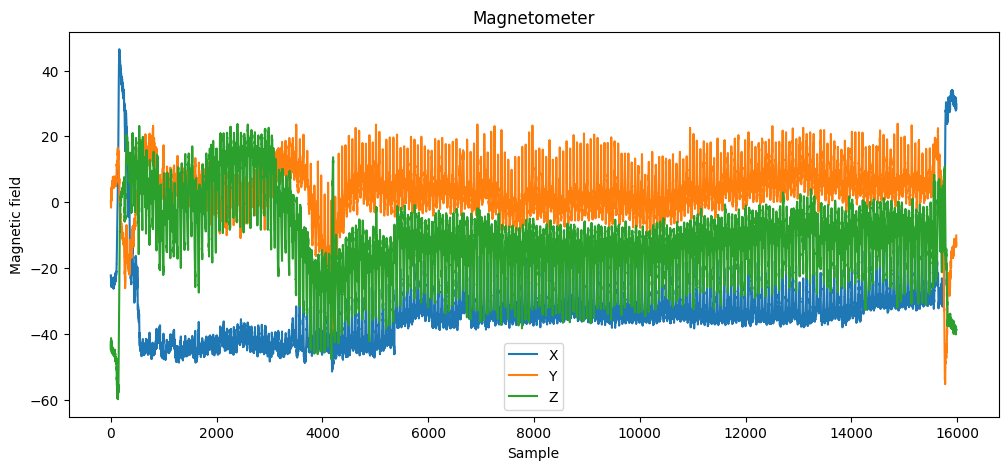

In [31]:
mag = data["magnetometer"]

plt.figure(figsize=(12, 5))

plt.plot(mag.iloc[:, 1], label="X")
plt.plot(mag.iloc[:, 2], label="Y")
plt.plot(mag.iloc[:, 3], label="Z")

plt.title("Magnetometer")
plt.xlabel("Sample")
plt.ylabel("Magnetic field")
plt.legend()

plt.show()

In [32]:
for name, df in data.items():
    print(f"{name:22s} -> {df.columns[0]}")

accelerometer          -> accelerometer_timestamp
gravity                -> gravity_timestamp
gyroscope              -> gyroscope_timestamp
linear_accelerometer   -> linearaccelerometer_timestamp
magnetometer           -> magnetometer_timestamp
rotation_vector        -> rotvec_timestamp


In [33]:
import pandas as pd
import numpy as np

sensor_data = {}

for name, df in data.items():
    df = df.copy()

    timestamp_col = df.columns[0]

    # Convert nanoseconds to seconds
    df["time_s"] = (
        df[timestamp_col] - df[timestamp_col].iloc[0]
    ) / 1e9

    sensor_data[name] = df

    print(
        f"{name:22s} "
        f"duration = {df['time_s'].iloc[-1]:.3f} s"
    )

accelerometer          duration = 268.353 s
gravity                duration = 267.883 s
gyroscope              duration = 267.895 s
linear_accelerometer   duration = 267.883 s
magnetometer           duration = 268.352 s
rotation_vector        duration = 267.883 s


In [34]:
for name, df in sensor_data.items():
    print(
        f"{name:22s} "
        f"start = {df['time_s'].iloc[0]:.6f} s, "
        f"end = {df['time_s'].iloc[-1]:.3f} s"
    )

accelerometer          start = 0.000000 s, end = 268.353 s
gravity                start = 0.000000 s, end = 267.883 s
gyroscope              start = 0.000000 s, end = 267.895 s
linear_accelerometer   start = 0.000000 s, end = 267.883 s
magnetometer           start = 0.000000 s, end = 268.352 s
rotation_vector        start = 0.000000 s, end = 267.883 s


In [35]:
for name, df in data.items():
    timestamp_col = df.columns[0]
    print(f"{name:22s} {df[timestamp_col].iloc[0]}")

accelerometer          924312945848402
gravity                924313418840345
gyroscope              924313414537367
linear_accelerometer   924313418840345
magnetometer           924312954759535
rotation_vector        924313418840345


In [36]:
starts = []
ends = []

for name, df in data.items():
    timestamp_col = df.columns[0]

    starts.append(df[timestamp_col].iloc[0])
    ends.append(df[timestamp_col].iloc[-1])

common_start = max(starts)
common_end = min(ends)

print("Common start:", common_start)
print("Common end:", common_end)

print(
    "Common duration:",
    (common_end - common_start) / 1e9,
    "seconds"
)

Common start: 924313418840345
Common end: 924581299108078
Common duration: 267.880267733 seconds


In [37]:
sampling_rate = 60

common_duration = (common_end - common_start) / 1e9

time_grid = np.arange(
    0,
    common_duration,
    1 / sampling_rate
)

print("Number of synchronized time points:", len(time_grid))
print("First 10:", time_grid[:10])

Number of synchronized time points: 16073
First 10: [0.         0.01666667 0.03333333 0.05       0.06666667 0.08333333
 0.1        0.11666667 0.13333333 0.15      ]


In [39]:
time_grid_ns = (
    common_start +
    (time_grid * 1e9).astype(np.int64)
)

In [40]:
acc = sensor_data["accelerometer"].copy()
mag = sensor_data["magnetometer"].copy()

acc = acc.rename(columns={
    acc.columns[0]: "timestamp"
})

mag = mag.rename(columns={
    mag.columns[0]: "timestamp"
})

In [41]:
sync = pd.DataFrame({
    "timestamp": time_grid_ns
})

print(sync.head())
print(sync.shape)

         timestamp
0  924313418840345
1  924313435507011
2  924313452173678
3  924313468840345
4  924313485507011
(16073, 1)


In [42]:
acc = acc.sort_values("timestamp")
sync = sync.sort_values("timestamp")

In [43]:
sync_acc = pd.merge_asof(
    sync,
    acc,
    on="timestamp",
    direction="nearest"
)

In [44]:
sync_acc.head()

,timestamp,accelerometer_x_data,accelerometer_y_data,accelerometer_z_data,time_s
0,924313418840345,2.211319,5.549683,7.155335,0.469971
1,924313435507011,1.968979,5.536926,6.754868,0.486755
2,924313452173678,1.933563,5.455307,6.973068,0.503540
3,924313468840345,1.917618,5.351868,7.377121,0.520325
4,924313485507011,1.870682,5.296036,7.880310,0.537109


In [45]:
mag = mag.sort_values("timestamp")

sync_acc_mag = pd.merge_asof(
    sync_acc,
    mag,
    on="timestamp",
    direction="nearest"
)

In [46]:
print(sync_acc_mag.head())
print(sync_acc_mag.shape)

         timestamp  accelerometer_x_data  accelerometer_y_data  \
0  924313418840345              2.211319              5.549683   
1  924313435507011              1.968979              5.536926   
2  924313452173678              1.933563              5.455307   
3  924313468840345              1.917618              5.351868   
4  924313485507011              1.870682              5.296036   

   accelerometer_z_data  time_s_x  magnetometer_x_data  magnetometer_y_data  \
0              7.155335  0.469971           -24.458313             4.956055   
1              6.754868  0.486755           -23.950195             4.446411   
2              6.973068  0.503540           -24.119568             5.635071   
3              7.377121  0.520325           -23.780823             5.635071   
4              7.880310  0.537109           -23.104858             5.975342   

   magnetometer_z_data  time_s_y  
0           -44.973755  0.472260  
1           -44.807434  0.485870  
2           -44.973755 

In [49]:
# Make a copy of the common time grid
target = sync[["timestamp"]].copy()

# Rename timestamps so we can keep BOTH timestamps
target = target.rename(columns={
    "timestamp": "target_timestamp"
})

mag_for_match = mag[["timestamp"]].copy()

mag_for_match = mag_for_match.rename(columns={
    "timestamp": "sensor_timestamp"
})

# Both must be sorted
target = target.sort_values("target_timestamp")
mag_for_match = mag_for_match.sort_values("sensor_timestamp")

# Match each target time to the nearest magnetometer sample
mag_match = pd.merge_asof(
    target,
    mag_for_match,
    left_on="target_timestamp",
    right_on="sensor_timestamp",
    direction="nearest"
)

mag_match.head()

,target_timestamp,sensor_timestamp
0,924313418840345,924313427019056
1,924313435507011,924313440629896
2,924313452173678,924313455675062
3,924313468840345,924313474229750
4,924313485507011,924313490983900


In [50]:
sync_error = (
    mag_match["sensor_timestamp"]
    - mag_match["target_timestamp"]
).abs()

print(
    "Maximum synchronization error:",
    sync_error.max() / 1e6,
    "ms"
)

print(
    "Median synchronization error:",
    sync_error.median() / 1e6,
    "ms"
)

Maximum synchronization error: 12.231859 ms
Median synchronization error: 4.198156 ms


In [51]:
print(sync_error.describe())

count    1.607300e+04
mean     4.228916e+06
std      2.477315e+06
min      3.920000e+02
25%      2.088936e+06
50%      4.198156e+06
75%      6.297296e+06
max      1.223186e+07
dtype: float64


In [52]:
max_error_ns = (1 / 60 / 2) * 1e9

print(
    "Allowed maximum error:",
    max_error_ns / 1e6,
    "ms"
)

print(
    "Samples within tolerance:",
    (sync_error <= max_error_ns).mean() * 100,
    "%"
)

Allowed maximum error: 8.333333333333332 ms
Samples within tolerance: 96.18615068748834 %


In [53]:
main_sensors = [
    "accelerometer",
    "gyroscope",
    "magnetometer"
]

for name in main_sensors:
    df = data[name]

    timestamp = df.iloc[:, 0]

    interval = timestamp.diff().median()
    rate = 1 / (interval / 1e9)

    duration = (
        timestamp.iloc[-1] - timestamp.iloc[0]
    ) / 1e9

    print(
        f"{name:15s} | "
        f"samples = {len(df):6d} | "
        f"rate = {rate:8.2f} Hz | "
        f"duration = {duration:8.2f} s"
    )

accelerometer   | samples =  31977 | rate =   119.16 Hz | duration =   268.35 s
gyroscope       | samples =  52900 | rate =   198.59 Hz | duration =   267.89 s
magnetometer    | samples =  15985 | rate =    59.47 Hz | duration =   268.35 s


In [54]:
print("Maximum:", sync_error.max() / 1e6, "ms")
print("Median:", sync_error.median() / 1e6, "ms")
print("Within tolerance:",
      (sync_error <= (1 / 60 / 2) * 1e9).mean() * 100, "%")

Maximum: 12.231859 ms
Median: 4.198156 ms
Within tolerance: 96.18615068748834 %


In [55]:
for name in ["accelerometer", "gyroscope", "magnetometer"]:
    df = data[name]
    interval = df.iloc[:, 0].diff().median()
    rate = 1 / (interval / 1e9)

    print(name, "→", rate, "Hz")

accelerometer → 119.15636341451616 Hz
gyroscope → 198.5939548000159 Hz
magnetometer → 59.47005284389956 Hz


In [143]:
import numpy as np
import pandas as pd


def prepare_sensor(df):
    """
    Prepare a sensor DataFrame:
    - first column = timestamp
    - next three columns = X, Y, Z
    - sort by timestamp
    - remove duplicate timestamps
    """
    df = df.iloc[:, :4].copy()

    df.columns = ["timestamp", "x", "y", "z"]

    df["timestamp"] = pd.to_numeric(
        df["timestamp"],
        errors="coerce"
    )

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["z"] = pd.to_numeric(df["z"], errors="coerce")

    df = df.dropna()

    df = df.sort_values("timestamp")

    df = df.drop_duplicates(
        subset="timestamp",
        keep="first"
    )

    return df.reset_index(drop=True)

In [144]:
acc = prepare_sensor(data["accelerometer"])
gyro = prepare_sensor(data["gyroscope"])
mag = prepare_sensor(data["magnetometer"])

print("Accelerometer:", acc.shape)
print("Gyroscope:", gyro.shape)
print("Magnetometer:", mag.shape)

NameError: name 'data' is not defined

In [58]:
common_start = max(
    acc["timestamp"].iloc[0],
    gyro["timestamp"].iloc[0],
    mag["timestamp"].iloc[0]
)

common_end = min(
    acc["timestamp"].iloc[-1],
    gyro["timestamp"].iloc[-1],
    mag["timestamp"].iloc[-1]
)

print("Common start:", common_start)
print("Common end:", common_end)

print(
    "Common duration:",
    (common_end - common_start) / 1e9,
    "seconds"
)

Common start: 924313414537367
Common end: 924581299108078
Common duration: 267.884570711 seconds


In [59]:
mag_common = mag[
    (mag["timestamp"] >= common_start) &
    (mag["timestamp"] <= common_end)
].copy()

print("Master timeline samples:", len(mag_common))

Master timeline samples: 15956


In [60]:
master_time = mag_common["timestamp"].to_numpy()

acc_time = acc["timestamp"].to_numpy()

acc_x = np.interp(
    master_time,
    acc_time,
    acc["x"].to_numpy()
)

acc_y = np.interp(
    master_time,
    acc_time,
    acc["y"].to_numpy()
)

acc_z = np.interp(
    master_time,
    acc_time,
    acc["z"].to_numpy()
)

In [61]:
gyro_time = gyro["timestamp"].to_numpy()

gyro_x = np.interp(
    master_time,
    gyro_time,
    gyro["x"].to_numpy()
)

gyro_y = np.interp(
    master_time,
    gyro_time,
    gyro["y"].to_numpy()
)

gyro_z = np.interp(
    master_time,
    gyro_time,
    gyro["z"].to_numpy()
)

In [62]:
sync_data = pd.DataFrame({
    "timestamp": master_time,

    "acc_x": acc_x,
    "acc_y": acc_y,
    "acc_z": acc_z,

    "gyro_x": gyro_x,
    "gyro_y": gyro_y,
    "gyro_z": gyro_z,

    "mag_x": mag_common["x"].to_numpy(),
    "mag_y": mag_common["y"].to_numpy(),
    "mag_z": mag_common["z"].to_numpy()
})

In [63]:
sync_data.head()

,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z
0,924313427019056,2.092381,5.532276,6.807283,0.241474,0.054328,0.122274,-24.458313,4.956055,-44.973755
1,924313440629896,1.952503,5.511549,6.834997,0.176910,-0.031082,0.092014,-23.950195,4.446411,-44.807434
2,924313455675062,1.920258,5.410363,7.105499,-0.043884,-0.118416,0.080129,-24.119568,5.635071,-44.973755
3,924313474229750,1.903482,5.333880,7.621179,-0.330161,-0.104419,0.135727,-23.780823,5.635071,-44.309998
4,924313490983900,1.870536,5.274803,8.069041,-0.486521,0.000348,0.158403,-23.104858,5.975342,-45.304870


In [64]:
print("Synchronized shape:", sync_data.shape)
print("\nMissing values:")
print(sync_data.isnull().sum())

Synchronized shape: (15956, 10)

Missing values:
timestamp    0
acc_x        0
acc_y        0
acc_z        0
gyro_x       0
gyro_y       0
gyro_z       0
mag_x        0
mag_y        0
mag_z        0
dtype: int64


In [65]:
sync_data["time_s"] = (
    sync_data["timestamp"] -
    sync_data["timestamp"].iloc[0]
) / 1e9

In [66]:
sync_data[
    ["timestamp", "time_s",
     "acc_x", "acc_y", "acc_z",
     "gyro_x", "gyro_y", "gyro_z",
     "mag_x", "mag_y", "mag_z"]
].head()

,timestamp,time_s,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z
0,924313427019056,0.000000,2.092381,5.532276,6.807283,0.241474,0.054328,0.122274,-24.458313,4.956055,-44.973755
1,924313440629896,0.013611,1.952503,5.511549,6.834997,0.176910,-0.031082,0.092014,-23.950195,4.446411,-44.807434
2,924313455675062,0.028656,1.920258,5.410363,7.105499,-0.043884,-0.118416,0.080129,-24.119568,5.635071,-44.973755
3,924313474229750,0.047211,1.903482,5.333880,7.621179,-0.330161,-0.104419,0.135727,-23.780823,5.635071,-44.309998
4,924313490983900,0.063965,1.870536,5.274803,8.069041,-0.486521,0.000348,0.158403,-23.104858,5.975342,-45.304870


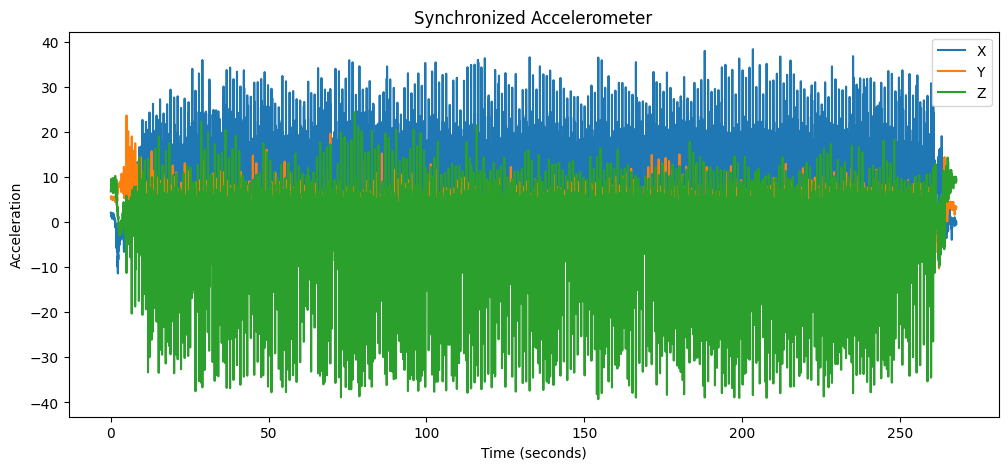

In [67]:
plt.figure(figsize=(12, 5))

plt.plot(
    sync_data["time_s"],
    sync_data["acc_x"],
    label="X"
)

plt.plot(
    sync_data["time_s"],
    sync_data["acc_y"],
    label="Y"
)

plt.plot(
    sync_data["time_s"],
    sync_data["acc_z"],
    label="Z"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")
plt.title("Synchronized Accelerometer")
plt.legend()
plt.show()

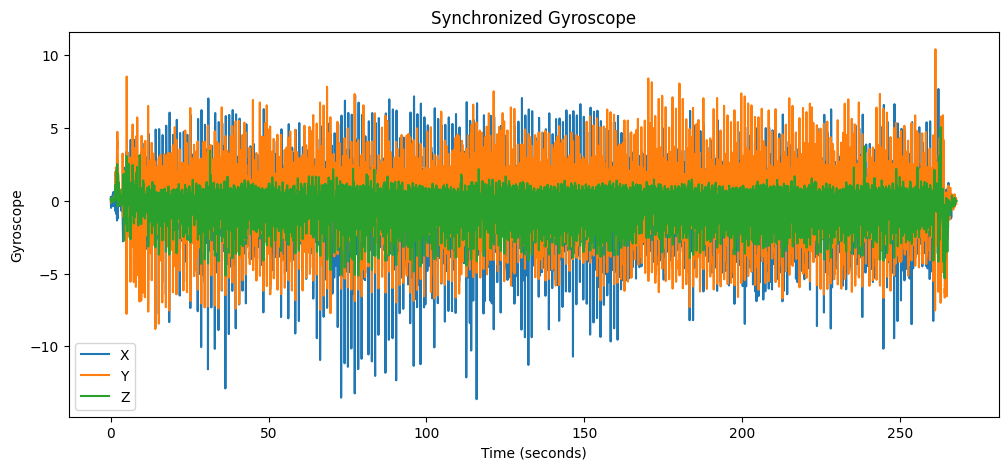

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    sync_data["time_s"],
    sync_data["gyro_x"],
    label="X"
)

plt.plot(
    sync_data["time_s"],
    sync_data["gyro_y"],
    label="Y"
)

plt.plot(
    sync_data["time_s"],
    sync_data["gyro_z"],
    label="Z"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Gyroscope")
plt.title("Synchronized Gyroscope")
plt.legend()
plt.show()

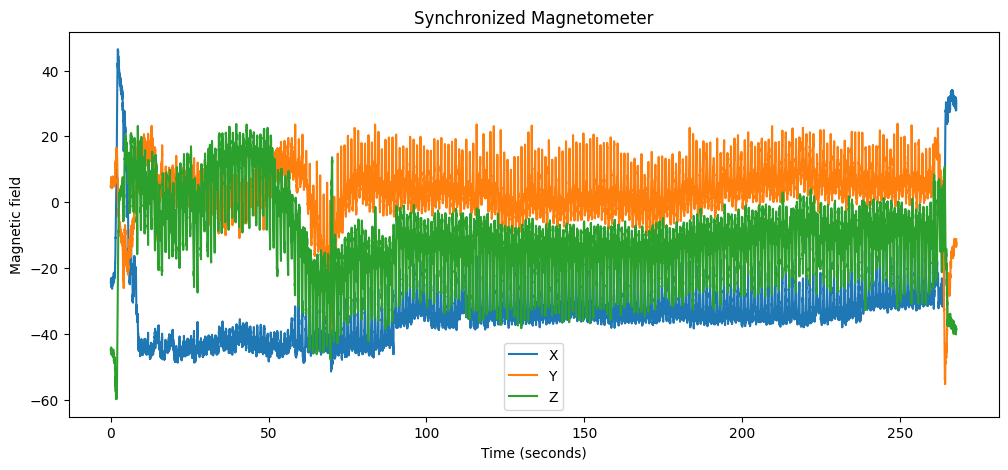

In [69]:
plt.figure(figsize=(12, 5))

plt.plot(
    sync_data["time_s"],
    sync_data["mag_x"],
    label="X"
)

plt.plot(
    sync_data["time_s"],
    sync_data["mag_y"],
    label="Y"
)

plt.plot(
    sync_data["time_s"],
    sync_data["mag_z"],
    label="Z"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Magnetic field")
plt.title("Synchronized Magnetometer")
plt.legend()
plt.show()

In [70]:
print(sync_data.shape)
print(sync_data.isnull().sum())

(15956, 11)
timestamp    0
acc_x        0
acc_y        0
acc_z        0
gyro_x       0
gyro_y       0
gyro_z       0
mag_x        0
mag_y        0
mag_z        0
time_s       0
dtype: int64


In [71]:
import numpy as np
import pandas as pd


def check_sensor_quality(df, sensor_name):
    """
    Perform basic technical quality checks on one sensor.
    """

    result = {
        "sensor": sensor_name,
        "samples": len(df),
        "missing_values": int(df.isnull().sum().sum()),
        "duplicate_timestamps": int(
            df["timestamp"].duplicated().sum()
        ),
        "timestamp_increasing": bool(
            df["timestamp"].is_monotonic_increasing
        ),
        "duration_seconds": np.nan,
        "sampling_rate_hz": np.nan,
        "constant_signal": False
    }

    # Duration and sampling rate
    if len(df) > 1:

        timestamp_diff = df["timestamp"].diff().dropna()

        result["duration_seconds"] = (
            df["timestamp"].iloc[-1] -
            df["timestamp"].iloc[0]
        ) / 1e9

        median_interval = timestamp_diff.median()

        if median_interval > 0:
            result["sampling_rate_hz"] = (
                1 / (median_interval / 1e9)
            )

    # Check whether all X/Y/Z values are essentially constant
    signal_columns = ["x", "y", "z"]

    result["constant_signal"] = all(
        df[column].nunique() <= 1
        for column in signal_columns
    )

    return result

In [72]:
acc_quality = check_sensor_quality(
    acc,
    "accelerometer"
)

gyro_quality = check_sensor_quality(
    gyro,
    "gyroscope"
)

mag_quality = check_sensor_quality(
    mag,
    "magnetometer"
)

quality_results = pd.DataFrame([
    acc_quality,
    gyro_quality,
    mag_quality
])

quality_results

,sensor,samples,missing_values,duplicate_timestamps,timestamp_increasing,duration_seconds,sampling_rate_hz,constant_signal
0,accelerometer,31977,0,0,True,268.353260,119.156363,False
1,gyroscope,52900,0,0,True,267.894642,198.593955,False
2,magnetometer,15985,0,0,True,268.352466,59.470053,False


In [73]:
print("Rows:", len(sync_data))
print("Columns:", len(sync_data.columns))

print("\nMissing values:")
print(sync_data.isnull().sum())

print("\nDuplicate timestamps:")
print(sync_data["timestamp"].duplicated().sum())

print("\nTimestamp increasing:")
print(sync_data["timestamp"].is_monotonic_increasing)

Rows: 15956
Columns: 11

Missing values:
timestamp    0
acc_x        0
acc_y        0
acc_z        0
gyro_x       0
gyro_y       0
gyro_z       0
mag_x        0
mag_y        0
mag_z        0
time_s       0
dtype: int64

Duplicate timestamps:
0

Timestamp increasing:
True


In [74]:
sensor_columns = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "mag_x", "mag_y", "mag_z"
]

sync_data[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
acc_x,15956.0,10.176222,6.423568,-11.368862,5.445207,9.301869,14.543478,38.355330
acc_y,15956.0,0.659750,3.309298,-12.422470,-1.662761,0.525759,2.260675,23.656919
acc_z,15956.0,1.113016,7.460318,-39.280423,0.143835,2.091723,4.572688,24.382187
gyro_x,15956.0,0.019964,2.290102,-13.631580,-1.056904,0.097054,1.372613,7.671699
gyro_y,15956.0,0.099445,2.021600,-8.813439,-1.019815,0.574468,1.426400,10.401682
gyro_z,15956.0,-0.228978,1.090251,-5.327105,-0.533002,-0.002663,0.478406,5.040958
mag_x,15956.0,-32.619552,12.543235,-51.483154,-39.863585,-34.315490,-29.727173,46.493530
mag_y,15956.0,3.725415,8.125688,-55.322266,0.006104,4.049683,8.161926,23.860168
mag_z,15956.0,-11.133701,12.515908,-59.896850,-18.348694,-11.218262,-4.879761,23.770142


In [75]:
sync_data[sensor_columns].std()

acc_x      6.423568
acc_y      3.309298
acc_z      7.460318
gyro_x     2.290102
gyro_y     2.021600
gyro_z     1.090251
mag_x     12.543235
mag_y      8.125688
mag_z     12.515908
dtype: float64

In [76]:
duration = (
    sync_data["timestamp"].iloc[-1]
    - sync_data["timestamp"].iloc[0]
) / 1e9

print(
    f"Synchronized recording duration: "
    f"{duration:.2f} seconds "
    f"({duration/60:.2f} minutes)"
)

Synchronized recording duration: 267.86 seconds (4.46 minutes)


In [77]:
time_differences = sync_data["timestamp"].diff().dropna()

print("Median synchronized interval:",
      time_differences.median() / 1e6,
      "ms")

print("Approximate synchronized rate:",
      1 / (time_differences.median() / 1e9),
      "Hz")

Median synchronized interval: 16.815186 ms
Approximate synchronized rate: 59.47005284389956 Hz


In [78]:
def initial_recording_status(
    acc,
    gyro,
    mag
):
    checks = []

    # Required sensors
    checks.append(len(acc) > 0)
    checks.append(len(gyro) > 0)
    checks.append(len(mag) > 0)

    # Missing values
    checks.append(acc.isnull().sum().sum() == 0)
    checks.append(gyro.isnull().sum().sum() == 0)
    checks.append(mag.isnull().sum().sum() == 0)

    # Timestamp ordering
    checks.append(acc["timestamp"].is_monotonic_increasing)
    checks.append(gyro["timestamp"].is_monotonic_increasing)
    checks.append(mag["timestamp"].is_monotonic_increasing)

    # Duplicate timestamps
    checks.append(acc["timestamp"].duplicated().sum() == 0)
    checks.append(gyro["timestamp"].duplicated().sum() == 0)
    checks.append(mag["timestamp"].duplicated().sum() == 0)

    if all(checks):
        return "TECHNICALLY VALID"

    return "REVIEW REQUIRED"


status = initial_recording_status(
    acc,
    gyro,
    mag
)

print(status)

TECHNICALLY VALID


In [79]:
quality_results

,sensor,samples,missing_values,duplicate_timestamps,timestamp_increasing,duration_seconds,sampling_rate_hz,constant_signal
0,accelerometer,31977,0,0,True,268.353260,119.156363,False
1,gyroscope,52900,0,0,True,267.894642,198.593955,False
2,magnetometer,15985,0,0,True,268.352466,59.470053,False


In [80]:
sync_data[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
acc_x,15956.0,10.176222,6.423568,-11.368862,5.445207,9.301869,14.543478,38.355330
acc_y,15956.0,0.659750,3.309298,-12.422470,-1.662761,0.525759,2.260675,23.656919
acc_z,15956.0,1.113016,7.460318,-39.280423,0.143835,2.091723,4.572688,24.382187
gyro_x,15956.0,0.019964,2.290102,-13.631580,-1.056904,0.097054,1.372613,7.671699
gyro_y,15956.0,0.099445,2.021600,-8.813439,-1.019815,0.574468,1.426400,10.401682
gyro_z,15956.0,-0.228978,1.090251,-5.327105,-0.533002,-0.002663,0.478406,5.040958
mag_x,15956.0,-32.619552,12.543235,-51.483154,-39.863585,-34.315490,-29.727173,46.493530
mag_y,15956.0,3.725415,8.125688,-55.322266,0.006104,4.049683,8.161926,23.860168
mag_z,15956.0,-11.133701,12.515908,-59.896850,-18.348694,-11.218262,-4.879761,23.770142


In [81]:
print("Status:", status)

Status: TECHNICALLY VALID


In [82]:
from pathlib import Path

data_path = Path(r"C:\Users\vatsa\Parkinson_Project\data")

print("Data folder exists:", data_path.exists())

Data folder exists: True


In [83]:
import re

recording_folders = sorted(
    [
        p for p in data_path.iterdir()
        if p.is_dir() and re.match(r"^u\d+_w\d+$", p.name)
    ]
)

print("Total recording folders:", len(recording_folders))

for folder in recording_folders[:20]:
    print(folder.name)

Total recording folders: 1
u001_w001


In [84]:
import numpy as np
import pandas as pd


def inspect_sensor_file(path):
    """
    Read one sensor log and collect technical quality information.
    """

    result = {
        "exists": path.exists(),
        "samples": 0,
        "columns": "",
        "missing_values": 0,
        "duplicate_timestamps": 0,
        "timestamp_increasing": False,
        "duration_seconds": np.nan,
        "sampling_rate_hz": np.nan,
        "constant_signal": False,
        "error": ""
    }

    if not path.exists():
        result["error"] = "FILE_NOT_FOUND"
        return result

    try:
        df = pd.read_csv(path, sep="\t")

        result["samples"] = len(df)
        result["columns"] = ", ".join(df.columns)

        # Expected timestamp + X/Y/Z
        if len(df.columns) < 4:
            result["error"] = "INSUFFICIENT_COLUMNS"
            return result

        timestamp = pd.to_numeric(
            df.iloc[:, 0],
            errors="coerce"
        )

        xyz = df.iloc[:, 1:4].apply(
            pd.to_numeric,
            errors="coerce"
        )

        # Missing / invalid values
        result["missing_values"] = int(
            timestamp.isna().sum()
            + xyz.isna().sum().sum()
        )

        # Timestamp checks
        result["duplicate_timestamps"] = int(
            timestamp.duplicated().sum()
        )

        result["timestamp_increasing"] = bool(
            timestamp.is_monotonic_increasing
        )

        # Duration and sampling rate
        if len(df) > 1:

            duration = (
                timestamp.iloc[-1]
                - timestamp.iloc[0]
            ) / 1e9

            result["duration_seconds"] = duration

            differences = timestamp.diff().dropna()

            if len(differences) > 0:
                median_interval = differences.median()

                if median_interval > 0:
                    result["sampling_rate_hz"] = (
                        1 / (median_interval / 1e9)
                    )

        # Constant signal check
        result["constant_signal"] = all(
            xyz.iloc[:, i].nunique(dropna=True) <= 1
            for i in range(3)
        )

    except Exception as e:
        result["error"] = type(e).__name__

    return result

In [85]:
quality_rows = []

for folder in recording_folders:

    recording_name = folder.name

    # Extract subject ID
    subject_id = recording_name.split("_")[0]

    files = {
        "accelerometer": folder / f"{recording_name}_accelerometer.log",
        "gyroscope": folder / f"{recording_name}_gyroscope.log",
        "magnetometer": folder / f"{recording_name}_magnetometer.log"
    }

    row = {
        "recording": recording_name,
        "subject": subject_id
    }

    sensor_results = {}

    for sensor_name, file_path in files.items():

        result = inspect_sensor_file(file_path)

        sensor_results[sensor_name] = result

        row[f"{sensor_name}_exists"] = result["exists"]
        row[f"{sensor_name}_samples"] = result["samples"]
        row[f"{sensor_name}_missing"] = result["missing_values"]
        row[f"{sensor_name}_duplicates"] = result["duplicate_timestamps"]
        row[f"{sensor_name}_timestamp_ok"] = result["timestamp_increasing"]
        row[f"{sensor_name}_duration_s"] = result["duration_seconds"]
        row[f"{sensor_name}_rate_hz"] = result["sampling_rate_hz"]
        row[f"{sensor_name}_constant"] = result["constant_signal"]
        row[f"{sensor_name}_error"] = result["error"]

    # Determine basic technical status
    hard_failure = False

    for sensor_name in files:

        result = sensor_results[sensor_name]

        if not result["exists"]:
            hard_failure = True

        if result["samples"] == 0:
            hard_failure = True

        if result["missing_values"] > 0:
            hard_failure = True

        if not result["timestamp_increasing"]:
            hard_failure = True

        if result["duplicate_timestamps"] > 0:
            hard_failure = True

    row["status"] = (
        "TECHNICALLY VALID"
        if not hard_failure
        else "REVIEW REQUIRED"
    )

    quality_rows.append(row)


quality_report = pd.DataFrame(quality_rows)

print("Recordings scanned:", len(quality_report))

Recordings scanned: 1


In [86]:
quality_report.head()

,recording,subject,accelerometer_exists,accelerometer_samples,accelerometer_missing,accelerometer_duplicates,accelerometer_timestamp_ok,accelerometer_duration_s,accelerometer_rate_hz,accelerometer_constant,...,magnetometer_exists,magnetometer_samples,magnetometer_missing,magnetometer_duplicates,magnetometer_timestamp_ok,magnetometer_duration_s,magnetometer_rate_hz,magnetometer_constant,magnetometer_error,status
0,u001_w001,u001,True,31977,0,0,True,268.35326,119.156363,False,...,True,15985,0,0,True,268.352466,59.470053,False,,TECHNICALLY VALID


In [87]:
print(
    quality_report["status"].value_counts()
)

status
TECHNICALLY VALID    1
Name: count, dtype: int64


In [88]:
review = quality_report[
    quality_report["status"] == "REVIEW REQUIRED"
]

print("Recordings requiring review:", len(review))

review[
    [
        "recording",
        "subject",
        "accelerometer_missing",
        "gyroscope_missing",
        "magnetometer_missing",
        "accelerometer_samples",
        "gyroscope_samples",
        "magnetometer_samples",
        "accelerometer_error",
        "gyroscope_error",
        "magnetometer_error"
    ]
]

Recordings requiring review: 0


,recording,subject,accelerometer_missing,gyroscope_missing,magnetometer_missing,accelerometer_samples,gyroscope_samples,magnetometer_samples,accelerometer_error,gyroscope_error,magnetometer_error


In [89]:
report_path = (
    Path(r"C:\Users\vatsa\Parkinson_Project\processed")
    / "quality_report.csv"
)

quality_report.to_csv(
    report_path,
    index=False
)

print("Saved:", report_path)

Saved: C:\Users\vatsa\Parkinson_Project\processed\quality_report.csv


In [90]:
print(
    quality_report.groupby(
        ["subject", "status"]
    ).size()
)

subject  status           
u001     TECHNICALLY VALID    1
dtype: int64


In [91]:
quality_report[
    [
        "recording",
        "subject",
        "accelerometer_duration_s",
        "gyroscope_duration_s",
        "magnetometer_duration_s",
        "status"
    ]
].head(20)

,recording,subject,accelerometer_duration_s,gyroscope_duration_s,magnetometer_duration_s,status
0,u001_w001,u001,268.35326,267.894642,268.352466,TECHNICALLY VALID


In [92]:
quality_report["duration_difference_s"] = (
    quality_report[
        [
            "accelerometer_duration_s",
            "gyroscope_duration_s",
            "magnetometer_duration_s"
        ]
    ].max(axis=1)
    -
    quality_report[
        [
            "accelerometer_duration_s",
            "gyroscope_duration_s",
            "magnetometer_duration_s"
        ]
    ].min(axis=1)
)

In [93]:
quality_report[
    [
        "recording",
        "duration_difference_s",
        "status"
    ]
].sort_values(
    "duration_difference_s",
    ascending=False
).head(20)

,recording,duration_difference_s,status
0,u001_w001,0.458618,TECHNICALLY VALID


In [94]:
print("Total recordings:", len(quality_report))
print(quality_report["status"].value_counts())

Total recordings: 1
status
TECHNICALLY VALID    1
Name: count, dtype: int64


In [95]:
print(
    quality_report.groupby(
        ["subject", "status"]
    ).size()
)

subject  status           
u001     TECHNICALLY VALID    1
dtype: int64


In [96]:
review[
    ["recording", "subject",
     "accelerometer_error",
     "gyroscope_error",
     "magnetometer_error",
     "accelerometer_missing",
     "gyroscope_missing",
     "magnetometer_missing"]
]

,recording,subject,accelerometer_error,gyroscope_error,magnetometer_error,accelerometer_missing,gyroscope_missing,magnetometer_missing


In [98]:
from pathlib import Path

data_path = Path(r"C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset")

print("Dataset exists:", data_path.exists())
print("Dataset path:", data_path)

Dataset exists: True
Dataset path: C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset


In [99]:
import re

recording_folders = sorted(
    [
        p for p in data_path.iterdir()
        if p.is_dir()
        and re.fullmatch(r"u\d+_w\d+", p.name)
    ]
)

print("Total recording folders:", len(recording_folders))

for folder in recording_folders[:20]:
    print(folder.name)

Total recording folders: 135
u001_w001
u001_w002
u001_w003
u002_w001
u002_w002
u002_w003
u002_w004
u003_w001
u003_w002
u004_w001
u004_w002
u005_w001
u006_w001
u007_w001
u007_w002
u008_w001
u009_w001
u010_w001
u010_w002
u010_w003


In [100]:
print("Dataset exists:", data_path.exists())
print("Dataset path:", data_path)

Dataset exists: True
Dataset path: C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset


In [101]:
print("Total recording folders:", len(recording_folders))

Total recording folders: 135


In [102]:
for folder in recording_folders[:20]:
    print(folder.name)

u001_w001
u001_w002
u001_w003
u002_w001
u002_w002
u002_w003
u002_w004
u003_w001
u003_w002
u004_w001
u004_w002
u005_w001
u006_w001
u007_w001
u007_w002
u008_w001
u009_w001
u010_w001
u010_w002
u010_w003


In [103]:
for folder in recording_folders[-10:]:
    print(folder.name)

u043_w005
u044_w001
u045_w001
u046_w001
u046_w002
u046_w003
u047_w001
u048_w001
u049_w001
u050_w001


In [104]:
quality_rows = []

for folder in recording_folders:

    recording_name = folder.name
    subject_id = recording_name.split("_")[0]

    files = {
        "accelerometer": folder / f"{recording_name}_accelerometer.log",
        "gyroscope": folder / f"{recording_name}_gyroscope.log",
        "magnetometer": folder / f"{recording_name}_magnetometer.log"
    }

    row = {
        "recording": recording_name,
        "subject": subject_id
    }

    sensor_results = {}

    for sensor_name, file_path in files.items():

        result = inspect_sensor_file(file_path)

        sensor_results[sensor_name] = result

        row[f"{sensor_name}_exists"] = result["exists"]
        row[f"{sensor_name}_samples"] = result["samples"]
        row[f"{sensor_name}_missing"] = result["missing_values"]
        row[f"{sensor_name}_duplicates"] = result["duplicate_timestamps"]
        row[f"{sensor_name}_timestamp_ok"] = result["timestamp_increasing"]
        row[f"{sensor_name}_duration_s"] = result["duration_seconds"]
        row[f"{sensor_name}_rate_hz"] = result["sampling_rate_hz"]
        row[f"{sensor_name}_constant"] = result["constant_signal"]
        row[f"{sensor_name}_error"] = result["error"]

    # Basic technical validity
    hard_failure = False

    for sensor_name in files:

        result = sensor_results[sensor_name]

        if not result["exists"]:
            hard_failure = True

        if result["samples"] == 0:
            hard_failure = True

        if result["missing_values"] > 0:
            hard_failure = True

        if not result["timestamp_increasing"]:
            hard_failure = True

        if result["duplicate_timestamps"] > 0:
            hard_failure = True

    row["status"] = (
        "TECHNICALLY VALID"
        if not hard_failure
        else "REVIEW REQUIRED"
    )

    quality_rows.append(row)


quality_report = pd.DataFrame(quality_rows)

print("Recordings scanned:", len(quality_report))

Recordings scanned: 135


In [105]:
print(
    quality_report["status"].value_counts()
)

status
TECHNICALLY VALID    119
REVIEW REQUIRED       16
Name: count, dtype: int64


In [106]:
quality_report.head()

,recording,subject,accelerometer_exists,accelerometer_samples,accelerometer_missing,accelerometer_duplicates,accelerometer_timestamp_ok,accelerometer_duration_s,accelerometer_rate_hz,accelerometer_constant,...,magnetometer_exists,magnetometer_samples,magnetometer_missing,magnetometer_duplicates,magnetometer_timestamp_ok,magnetometer_duration_s,magnetometer_rate_hz,magnetometer_constant,magnetometer_error,status
0,u001_w001,u001,True,31977,0,0,True,268.353260,119.156363,False,...,True,15985,0,0,True,268.352466,59.470053,False,,TECHNICALLY VALID
1,u001_w002,u001,True,28265,0,0,True,237.200921,119.156363,False,...,True,14123,0,0,True,237.196404,59.470053,False,,TECHNICALLY VALID
2,u001_w003,u001,True,30233,0,0,True,253.717058,119.156363,False,...,True,15108,0,0,True,253.710711,59.470053,False,,TECHNICALLY VALID
3,u002_w001,u002,True,57185,0,0,True,480.567317,119.156363,False,...,True,27501,0,0,True,480.442774,64.000000,False,,TECHNICALLY VALID
4,u002_w002,u002,True,71500,0,0,True,600.043465,119.156363,False,...,True,35750,0,0,True,600.035133,64.000000,False,,TECHNICALLY VALID


In [107]:
quality_report.shape

(135, 30)

In [108]:
review = quality_report[
    quality_report["status"] == "REVIEW REQUIRED"
]

print("Recordings requiring review:", len(review))

Recordings requiring review: 16


In [109]:
review[
    [
        "recording",
        "subject",
        "accelerometer_exists",
        "gyroscope_exists",
        "magnetometer_exists",
        "accelerometer_samples",
        "gyroscope_samples",
        "magnetometer_samples",
        "accelerometer_missing",
        "gyroscope_missing",
        "magnetometer_missing",
        "accelerometer_error",
        "gyroscope_error",
        "magnetometer_error"
    ]
]

,recording,subject,accelerometer_exists,gyroscope_exists,magnetometer_exists,accelerometer_samples,gyroscope_samples,magnetometer_samples,accelerometer_missing,gyroscope_missing,magnetometer_missing,accelerometer_error,gyroscope_error,magnetometer_error
6,u002_w004,u002,True,True,True,71485,118640,35740,0,0,0,,,
8,u003_w002,u003,True,True,True,71485,118640,35740,0,0,0,,,
10,u004_w002,u004,True,True,True,57184,94008,27219,0,0,0,,,
28,u016_w001,u016,True,True,True,42922,71181,21459,0,0,0,,,
29,u016_w002,u016,True,True,True,42964,71248,21479,0,0,0,,,
33,u018_w003,u018,True,True,True,57186,94884,27534,0,0,0,,,
39,u018_w009,u018,True,True,True,71487,117627,35703,0,0,0,,,
41,u018_w011,u018,True,True,True,42893,71156,21447,0,0,0,,,
42,u018_w012,u018,True,True,True,71514,118719,35757,0,0,0,,,
46,u019_w002,u019,True,True,True,71487,117627,35703,0,0,0,,,


In [110]:
print(
    "Unique participants:",
    quality_report["subject"].nunique()
)

Unique participants: 50


In [111]:
subject_counts = (
    quality_report
    .groupby("subject")
    .size()
    .sort_index()
)

print(subject_counts)

subject
u001     3
u002     4
u003     2
u004     2
u005     1
u006     1
u007     2
u008     1
u009     1
u010     4
u011     1
u012     2
u013     1
u014     2
u015     1
u016     2
u017     1
u018    14
u019     2
u020     2
u021     3
u022     1
u023    12
u024     8
u025     3
u026     2
u027     2
u028     7
u029     2
u030     2
u031     2
u032     1
u033     7
u034     2
u035     2
u036     5
u037     2
u038     2
u039     1
u040     4
u041     1
u042     1
u043     5
u044     1
u045     1
u046     3
u047     1
u048     1
u049     1
u050     1
dtype: int64


In [112]:
subject_status = (
    quality_report
    .groupby(["subject", "status"])
    .size()
)

print(subject_status)

subject  status           
u001     TECHNICALLY VALID     3
u002     REVIEW REQUIRED       1
         TECHNICALLY VALID     3
u003     REVIEW REQUIRED       1
         TECHNICALLY VALID     1
u004     REVIEW REQUIRED       1
         TECHNICALLY VALID     1
u005     TECHNICALLY VALID     1
u006     TECHNICALLY VALID     1
u007     TECHNICALLY VALID     2
u008     TECHNICALLY VALID     1
u009     TECHNICALLY VALID     1
u010     TECHNICALLY VALID     4
u011     TECHNICALLY VALID     1
u012     TECHNICALLY VALID     2
u013     TECHNICALLY VALID     1
u014     TECHNICALLY VALID     2
u015     TECHNICALLY VALID     1
u016     REVIEW REQUIRED       2
u017     TECHNICALLY VALID     1
u018     REVIEW REQUIRED       4
         TECHNICALLY VALID    10
u019     REVIEW REQUIRED       1
         TECHNICALLY VALID     1
u020     TECHNICALLY VALID     2
u021     TECHNICALLY VALID     3
u022     TECHNICALLY VALID     1
u023     TECHNICALLY VALID    12
u024     TECHNICALLY VALID     8
u025     TECHNIC

In [113]:
duration_columns = [
    "accelerometer_duration_s",
    "gyroscope_duration_s",
    "magnetometer_duration_s"
]

quality_report[
    ["recording", "subject"] + duration_columns
].head(20)

,recording,subject,accelerometer_duration_s,gyroscope_duration_s,magnetometer_duration_s
0,u001_w001,u001,268.353260,267.894642,268.352466
1,u001_w002,u001,237.200921,236.745171,237.196404
2,u001_w003,u001,253.717058,253.258196,253.710711
3,u002_w001,u002,480.567317,479.998316,480.442774
4,u002_w002,u002,600.043465,599.576149,600.035133
5,u002_w003,u002,479.932414,479.460826,479.890636
6,u002_w004,u002,599.880120,599.291039,599.736230
7,u003_w001,u003,600.043465,599.576149,600.035133
8,u003_w002,u003,599.880120,599.291039,599.736230
9,u004_w001,u004,359.905269,359.446987,359.882839


In [114]:
quality_report[
    [
        "recording",
        "subject",
        "accelerometer_duration_s",
        "gyroscope_duration_s",
        "magnetometer_duration_s"
    ]
].sort_values(
    "accelerometer_duration_s"
).head(15)

,recording,subject,accelerometer_duration_s,gyroscope_duration_s,magnetometer_duration_s
124,u043_w004,u043,138.146214,137.689518,138.149540
122,u043_w002,u043,148.300955,147.848528,148.298056
95,u033_w002,u033,155.107079,154.647668,155.101372
49,u021_w001,u021,158.195503,157.736732,158.188057
27,u015_w001,u015,179.988773,179.844405,179.752078
116,u040_w002,u040,192.780328,192.314691,192.772149
108,u036_w004,u036,199.662040,199.208946,199.653892
60,u023_w008,u023,221.703878,221.628591,221.609853
23,u012_w002,u012,230.373300,230.373000,230.339900
1,u001_w002,u001,237.200921,236.745171,237.196404


In [115]:
quality_report[
    [
        "recording",
        "subject",
        "accelerometer_duration_s",
        "gyroscope_duration_s",
        "magnetometer_duration_s"
    ]
].sort_values(
    "accelerometer_duration_s",
    ascending=False
).head(15)

,recording,subject,accelerometer_duration_s,gyroscope_duration_s,magnetometer_duration_s
37,u018_w007,u018,966.504871,966.043781,966.488330
31,u018_w001,u018,827.610004,827.155963,827.619128
123,u043_w003,u043,776.517447,776.050894,776.503256
131,u047_w001,u047,659.827637,659.827637,659.827637
42,u018_w012,u018,601.067905,600.542179,601.010868
83,u028_w004,u028,601.050900,600.515500,600.977383
87,u029_w001,u029,601.050900,600.515500,600.977383
46,u019_w002,u019,600.476604,600.014996,600.442608
39,u018_w009,u018,600.476604,600.014996,600.442608
15,u008_w001,u008,600.368011,600.345185,600.345184


In [116]:
quality_report["duration_difference_s"] = (
    quality_report[
        [
            "accelerometer_duration_s",
            "gyroscope_duration_s",
            "magnetometer_duration_s"
        ]
    ].max(axis=1)
    -
    quality_report[
        [
            "accelerometer_duration_s",
            "gyroscope_duration_s",
            "magnetometer_duration_s"
        ]
    ].min(axis=1)
)

In [117]:
quality_report[
    [
        "recording",
        "subject",
        "duration_difference_s",
        "status"
    ]
].sort_values(
    "duration_difference_s",
    ascending=False
).head(20)

,recording,subject,duration_difference_s,status
6,u002_w004,u002,0.589081,REVIEW REQUIRED
8,u003_w002,u003,0.589081,REVIEW REQUIRED
94,u033_w001,u033,0.587463,TECHNICALLY VALID
103,u035_w001,u035,0.587463,TECHNICALLY VALID
3,u002_w001,u002,0.569000,TECHNICALLY VALID
115,u040_w001,u040,0.554596,TECHNICALLY VALID
120,u042_w001,u042,0.554596,TECHNICALLY VALID
34,u018_w004,u018,0.550715,TECHNICALLY VALID
65,u024_w001,u024,0.550415,TECHNICALLY VALID
84,u028_w005,u028,0.545532,REVIEW REQUIRED


In [118]:
from pathlib import Path

output_dir = Path(
    r"C:\Users\vatsa\Parkinson_Project\processed"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

report_path = output_dir / "quality_report.csv"

quality_report.to_csv(
    report_path,
    index=False
)

print("Quality report saved to:")
print(report_path)

Quality report saved to:
C:\Users\vatsa\Parkinson_Project\processed\quality_report.csv


In [119]:
print("Total:", len(quality_report))
print(quality_report["status"].value_counts())

Total: 135
status
TECHNICALLY VALID    119
REVIEW REQUIRED       16
Name: count, dtype: int64


In [120]:
print("Participants:", quality_report["subject"].nunique())

Participants: 50


In [121]:
print(
    quality_report
    .groupby("subject")
    .size()
)

subject
u001     3
u002     4
u003     2
u004     2
u005     1
u006     1
u007     2
u008     1
u009     1
u010     4
u011     1
u012     2
u013     1
u014     2
u015     1
u016     2
u017     1
u018    14
u019     2
u020     2
u021     3
u022     1
u023    12
u024     8
u025     3
u026     2
u027     2
u028     7
u029     2
u030     2
u031     2
u032     1
u033     7
u034     2
u035     2
u036     5
u037     2
u038     2
u039     1
u040     4
u041     1
u042     1
u043     5
u044     1
u045     1
u046     3
u047     1
u048     1
u049     1
u050     1
dtype: int64


In [122]:
print("Review:", len(review))

Review: 16


In [123]:
# Show all recordings grouped by participant

for subject in sorted(quality_report["subject"].unique()):

    recordings = sorted(
        quality_report.loc[
            quality_report["subject"] == subject,
            "recording"
        ].tolist()
    )

    print(f"\n{subject} ({len(recordings)} recordings)")
    print(recordings)


u001 (3 recordings)
['u001_w001', 'u001_w002', 'u001_w003']

u002 (4 recordings)
['u002_w001', 'u002_w002', 'u002_w003', 'u002_w004']

u003 (2 recordings)
['u003_w001', 'u003_w002']

u004 (2 recordings)
['u004_w001', 'u004_w002']

u005 (1 recordings)
['u005_w001']

u006 (1 recordings)
['u006_w001']

u007 (2 recordings)
['u007_w001', 'u007_w002']

u008 (1 recordings)
['u008_w001']

u009 (1 recordings)
['u009_w001']

u010 (4 recordings)
['u010_w001', 'u010_w002', 'u010_w003', 'u010_w004']

u011 (1 recordings)
['u011_w001']

u012 (2 recordings)
['u012_w001', 'u012_w002']

u013 (1 recordings)
['u013_w001']

u014 (2 recordings)
['u014_w001', 'u014_w002']

u015 (1 recordings)
['u015_w001']

u016 (2 recordings)
['u016_w001', 'u016_w002']

u017 (1 recordings)
['u017_w001']

u018 (14 recordings)
['u018_w001', 'u018_w002', 'u018_w003', 'u018_w004', 'u018_w005', 'u018_w006', 'u018_w007', 'u018_w008', 'u018_w009', 'u018_w010', 'u018_w011', 'u018_w012', 'u018_w013', 'u018_w014']

u019 (2 recording

In [124]:
import re

quality_report["trial"] = (
    quality_report["recording"]
    .str.extract(r"_w(\d+)$")[0]
    .astype(int)
)

quality_report[
    ["recording", "subject", "trial"]
].head(20)

,recording,subject,trial
0,u001_w001,u001,1
1,u001_w002,u001,2
2,u001_w003,u001,3
3,u002_w001,u002,1
4,u002_w002,u002,2
5,u002_w003,u002,3
6,u002_w004,u002,4
7,u003_w001,u003,1
8,u003_w002,u003,2
9,u004_w001,u004,1


In [125]:
sorted(
    quality_report["trial"].unique()
)

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14)]

In [126]:
print(
    "Maximum w number:",
    quality_report["trial"].max()
)

Maximum w number: 14


In [127]:
trial_summary = (
    quality_report
    .groupby("trial")
    .agg(
        recordings=("recording", "count"),
        subjects=("subject", "nunique")
    )
    .reset_index()
)

trial_summary

,trial,recordings,subjects
0,1,50,50
1,2,31,31
2,3,14,14
3,4,10,10
4,5,7,7
5,6,5,5
6,7,5,5
7,8,3,3
8,9,2,2
9,10,2,2


In [128]:
for subject in sorted(quality_report["subject"].unique()):

    recordings = sorted(
        quality_report.loc[
            quality_report["subject"] == subject,
            "recording"
        ].tolist()
    )

    print(f"\n{subject} ({len(recordings)} recordings)")
    print(recordings)


u001 (3 recordings)
['u001_w001', 'u001_w002', 'u001_w003']

u002 (4 recordings)
['u002_w001', 'u002_w002', 'u002_w003', 'u002_w004']

u003 (2 recordings)
['u003_w001', 'u003_w002']

u004 (2 recordings)
['u004_w001', 'u004_w002']

u005 (1 recordings)
['u005_w001']

u006 (1 recordings)
['u006_w001']

u007 (2 recordings)
['u007_w001', 'u007_w002']

u008 (1 recordings)
['u008_w001']

u009 (1 recordings)
['u009_w001']

u010 (4 recordings)
['u010_w001', 'u010_w002', 'u010_w003', 'u010_w004']

u011 (1 recordings)
['u011_w001']

u012 (2 recordings)
['u012_w001', 'u012_w002']

u013 (1 recordings)
['u013_w001']

u014 (2 recordings)
['u014_w001', 'u014_w002']

u015 (1 recordings)
['u015_w001']

u016 (2 recordings)
['u016_w001', 'u016_w002']

u017 (1 recordings)
['u017_w001']

u018 (14 recordings)
['u018_w001', 'u018_w002', 'u018_w003', 'u018_w004', 'u018_w005', 'u018_w006', 'u018_w007', 'u018_w008', 'u018_w009', 'u018_w010', 'u018_w011', 'u018_w012', 'u018_w013', 'u018_w014']

u019 (2 recording

In [129]:
trial_summary

,trial,recordings,subjects
0,1,50,50
1,2,31,31
2,3,14,14
3,4,10,10
4,5,7,7
5,6,5,5
6,7,5,5
7,8,3,3
8,9,2,2
9,10,2,2


In [130]:
from pathlib import Path

data_path = Path(
    r"C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset"
)

print("Files and folders at dataset root:\n")

for item in sorted(data_path.iterdir()):
    print(item.name)

Files and folders at dataset root:

u001_w001
u001_w002
u001_w003
u002_w001
u002_w002
u002_w003
u002_w004
u003_w001
u003_w002
u004_w001
u004_w002
u005_w001
u006_w001
u007_w001
u007_w002
u008_w001
u009_w001
u010_w001
u010_w002
u010_w003
u010_w004
u011_w001
u012_w001
u012_w002
u013_w001
u014_w001
u014_w002
u015_w001
u016_w001
u016_w002
u017_w001
u018_w001
u018_w002
u018_w003
u018_w004
u018_w005
u018_w006
u018_w007
u018_w008
u018_w009
u018_w010
u018_w011
u018_w012
u018_w013
u018_w014
u019_w001
u019_w002
u020_w001
u020_w002
u021_w001
u021_w002
u021_w003
u022_w001
u023_w001
u023_w002
u023_w003
u023_w004
u023_w005
u023_w006
u023_w007
u023_w008
u023_w009
u023_w010
u023_w011
u023_w012
u024_w001
u024_w002
u024_w003
u024_w004
u024_w005
u024_w006
u024_w007
u024_w008
u025_w001
u025_w002
u025_w003
u026_w001
u026_w002
u027_w001
u027_w002
u028_w001
u028_w002
u028_w003
u028_w004
u028_w005
u028_w006
u028_w007
u029_w001
u029_w002
u030_w001
u030_w002
u031_w001
u031_w002
u032_w001
u033_w001
u033_w002
u033

In [131]:
for recording_name in [
    "u001_w001",
    "u001_w002",
    "u001_w003"
]:
    
    folder = data_path / recording_name
    
    print("\n" + "=" * 60)
    print(recording_name)
    
    if folder.exists():
        for item in sorted(folder.iterdir()):
            print("  ", item.name)
    else:
        print("  Folder not found")


u001_w001
   u001_w001_accelerometer.log
   u001_w001_gravity.log
   u001_w001_gyroscope.log
   u001_w001_linearaccelerometer.log
   u001_w001_magnetometer.log
   u001_w001_rotvec.log

u001_w002
   u001_w002_accelerometer.log
   u001_w002_gravity.log
   u001_w002_gyroscope.log
   u001_w002_linearaccelerometer.log
   u001_w002_magnetometer.log
   u001_w002_rotvec.log

u001_w003
   u001_w003_accelerometer.log
   u001_w003_gravity.log
   u001_w003_gyroscope.log
   u001_w003_linearaccelerometer.log
   u001_w003_magnetometer.log
   u001_w003_rotvec.log


In [132]:
sample_recordings = [
    "u001_w001",
    "u001_w002",
    "u002_w001",
    "u002_w002",
    "u018_w001",
    "u018_w002",
    "u018_w014"
]

for recording_name in sample_recordings:
    
    folder = data_path / recording_name
    
    print("\n" + "=" * 60)
    print(recording_name)
    
    if folder.exists():
        files = sorted(
            item.name
            for item in folder.iterdir()
            if item.is_file()
        )
        
        for file in files:
            print(file)


u001_w001
u001_w001_accelerometer.log
u001_w001_gravity.log
u001_w001_gyroscope.log
u001_w001_linearaccelerometer.log
u001_w001_magnetometer.log
u001_w001_rotvec.log

u001_w002
u001_w002_accelerometer.log
u001_w002_gravity.log
u001_w002_gyroscope.log
u001_w002_linearaccelerometer.log
u001_w002_magnetometer.log
u001_w002_rotvec.log

u002_w001
u002_w001_accelerometer.log
u002_w001_gravity.log
u002_w001_gyroscope.log
u002_w001_linearaccelerometer.log
u002_w001_magnetometer.log
u002_w001_rotvec.log

u002_w002
u002_w002_accelerometer.log
u002_w002_gravity.log
u002_w002_gyroscope.log
u002_w002_linearaccelerometer.log
u002_w002_magnetometer.log
u002_w002_rotvec.log

u018_w001
u018_w001_accelerometer.log
u018_w001_gravity.log
u018_w001_gyroscope.log
u018_w001_linearaccelerometer.log
u018_w001_magnetometer.log
u018_w001_rotvec.log

u018_w002
u018_w002_accelerometer.log
u018_w002_gravity.log
u018_w002_gyroscope.log
u018_w002_linearaccelerometer.log
u018_w002_magnetometer.log
u018_w002_rotvec.lo

In [133]:
trial_summary

,trial,recordings,subjects
0,1,50,50
1,2,31,31
2,3,14,14
3,4,10,10
4,5,7,7
5,6,5,5
6,7,5,5
7,8,3,3
8,9,2,2
9,10,2,2


In [134]:
print(
    trial_summary.to_string(index=False)
)

 trial  recordings  subjects
     1          50        50
     2          31        31
     3          14        14
     4          10        10
     5           7         7
     6           5         5
     7           5         5
     8           3         3
     9           2         2
    10           2         2
    11           2         2
    12           2         2
    13           1         1
    14           1         1


In [135]:
trial_subjects = (
    quality_report
    .groupby("trial")["subject"]
    .apply(list)
)

for trial, subjects in trial_subjects.items():
    print(
        f"\nw{trial:03d} -> "
        f"{len(subjects)} subjects"
    )
    print(subjects)


w001 -> 50 subjects
['u001', 'u002', 'u003', 'u004', 'u005', 'u006', 'u007', 'u008', 'u009', 'u010', 'u011', 'u012', 'u013', 'u014', 'u015', 'u016', 'u017', 'u018', 'u019', 'u020', 'u021', 'u022', 'u023', 'u024', 'u025', 'u026', 'u027', 'u028', 'u029', 'u030', 'u031', 'u032', 'u033', 'u034', 'u035', 'u036', 'u037', 'u038', 'u039', 'u040', 'u041', 'u042', 'u043', 'u044', 'u045', 'u046', 'u047', 'u048', 'u049', 'u050']

w002 -> 31 subjects
['u001', 'u002', 'u003', 'u004', 'u007', 'u010', 'u012', 'u014', 'u016', 'u018', 'u019', 'u020', 'u021', 'u023', 'u024', 'u025', 'u026', 'u027', 'u028', 'u029', 'u030', 'u031', 'u033', 'u034', 'u035', 'u036', 'u037', 'u038', 'u040', 'u043', 'u046']

w003 -> 14 subjects
['u001', 'u002', 'u010', 'u018', 'u021', 'u023', 'u024', 'u025', 'u028', 'u033', 'u036', 'u040', 'u043', 'u046']

w004 -> 10 subjects
['u002', 'u010', 'u018', 'u023', 'u024', 'u028', 'u033', 'u036', 'u040', 'u043']

w005 -> 7 subjects
['u018', 'u023', 'u024', 'u028', 'u033', 'u036', 'u0

In [136]:
trial_duration = (
    quality_report
    .groupby("trial")
    .agg(
        recordings=("recording", "count"),
        mean_duration_s=("accelerometer_duration_s", "mean"),
        min_duration_s=("accelerometer_duration_s", "min"),
        max_duration_s=("accelerometer_duration_s", "max")
    )
    .reset_index()
)

trial_duration

,trial,recordings,mean_duration_s,min_duration_s,max_duration_s
0,1,50,411.340784,158.195503,827.610004
1,2,31,379.453725,148.300955,600.476604
2,3,14,373.691833,246.205896,776.517447
3,4,10,440.100925,138.146214,601.050900
4,5,7,315.464535,244.972213,479.672948
5,6,5,426.076875,276.090992,486.604675
6,7,5,486.336783,265.411008,966.504871
7,8,3,433.249840,221.703878,599.993118
8,9,2,583.168031,565.859458,600.476604
9,10,2,395.818942,371.727446,419.910439


In [137]:
for recording_name in [
    "u001_w001",
    "u001_w002",
    "u001_w003"
]:
    
    folder = data_path / recording_name
    
    sensor_names = []
    
    for file in folder.iterdir():
        name = file.name.lower()
        
        if "accelerometer" in name:
            sensor_names.append("accelerometer")
        elif "gyroscope" in name:
            sensor_names.append("gyroscope")
        elif "magnetometer" in name:
            sensor_names.append("magnetometer")
        elif "gravity" in name:
            sensor_names.append("gravity")
        elif "linearaccelerometer" in name:
            sensor_names.append("linearaccelerometer")
        elif "rotvec" in name:
            sensor_names.append("rotation_vector")
    
    print(recording_name, ":", sensor_names)

u001_w001 : ['accelerometer', 'gravity', 'gyroscope', 'accelerometer', 'magnetometer', 'rotation_vector']
u001_w002 : ['accelerometer', 'gravity', 'gyroscope', 'accelerometer', 'magnetometer', 'rotation_vector']
u001_w003 : ['accelerometer', 'gravity', 'gyroscope', 'accelerometer', 'magnetometer', 'rotation_vector']


In [138]:
possible_metadata = []

for path in data_path.rglob("*"):
    
    if path.is_file():
        name = path.name.lower()
        
        if any(
            keyword in name
            for keyword in [
                "metadata",
                "subject",
                "participant",
                "diagnosis",
                "clinical",
                "label",
                "readme"
            ]
        ):
            possible_metadata.append(path)

print("Possible metadata files:")

for path in possible_metadata:
    print(path)

Possible metadata files:


In [139]:
for item in sorted(data_path.iterdir()):
    print(item.name)

u001_w001
u001_w002
u001_w003
u002_w001
u002_w002
u002_w003
u002_w004
u003_w001
u003_w002
u004_w001
u004_w002
u005_w001
u006_w001
u007_w001
u007_w002
u008_w001
u009_w001
u010_w001
u010_w002
u010_w003
u010_w004
u011_w001
u012_w001
u012_w002
u013_w001
u014_w001
u014_w002
u015_w001
u016_w001
u016_w002
u017_w001
u018_w001
u018_w002
u018_w003
u018_w004
u018_w005
u018_w006
u018_w007
u018_w008
u018_w009
u018_w010
u018_w011
u018_w012
u018_w013
u018_w014
u019_w001
u019_w002
u020_w001
u020_w002
u021_w001
u021_w002
u021_w003
u022_w001
u023_w001
u023_w002
u023_w003
u023_w004
u023_w005
u023_w006
u023_w007
u023_w008
u023_w009
u023_w010
u023_w011
u023_w012
u024_w001
u024_w002
u024_w003
u024_w004
u024_w005
u024_w006
u024_w007
u024_w008
u025_w001
u025_w002
u025_w003
u026_w001
u026_w002
u027_w001
u027_w002
u028_w001
u028_w002
u028_w003
u028_w004
u028_w005
u028_w006
u028_w007
u029_w001
u029_w002
u030_w001
u030_w002
u031_w001
u031_w002
u032_w001
u033_w001
u033_w002
u033_w003
u033_w004
u033_w005
u033_w006


In [140]:
for recording_name in [
    "u001_w001",
    "u001_w002",
    "u001_w003"
]:
    folder = data_path / recording_name
    print("\n", recording_name)
    for item in sorted(folder.iterdir()):
        print(item.name)


 u001_w001
u001_w001_accelerometer.log
u001_w001_gravity.log
u001_w001_gyroscope.log
u001_w001_linearaccelerometer.log
u001_w001_magnetometer.log
u001_w001_rotvec.log

 u001_w002
u001_w002_accelerometer.log
u001_w002_gravity.log
u001_w002_gyroscope.log
u001_w002_linearaccelerometer.log
u001_w002_magnetometer.log
u001_w002_rotvec.log

 u001_w003
u001_w003_accelerometer.log
u001_w003_gravity.log
u001_w003_gyroscope.log
u001_w003_linearaccelerometer.log
u001_w003_magnetometer.log
u001_w003_rotvec.log


In [141]:
print("ROOT CONTENTS")
print("=" * 60)

for item in sorted(data_path.iterdir()):
    kind = "DIR " if item.is_dir() else "FILE"
    print(f"{kind}  {item.name}")

ROOT CONTENTS
DIR   u001_w001
DIR   u001_w002
DIR   u001_w003
DIR   u002_w001
DIR   u002_w002
DIR   u002_w003
DIR   u002_w004
DIR   u003_w001
DIR   u003_w002
DIR   u004_w001
DIR   u004_w002
DIR   u005_w001
DIR   u006_w001
DIR   u007_w001
DIR   u007_w002
DIR   u008_w001
DIR   u009_w001
DIR   u010_w001
DIR   u010_w002
DIR   u010_w003
DIR   u010_w004
DIR   u011_w001
DIR   u012_w001
DIR   u012_w002
DIR   u013_w001
DIR   u014_w001
DIR   u014_w002
DIR   u015_w001
DIR   u016_w001
DIR   u016_w002
DIR   u017_w001
DIR   u018_w001
DIR   u018_w002
DIR   u018_w003
DIR   u018_w004
DIR   u018_w005
DIR   u018_w006
DIR   u018_w007
DIR   u018_w008
DIR   u018_w009
DIR   u018_w010
DIR   u018_w011
DIR   u018_w012
DIR   u018_w013
DIR   u018_w014
DIR   u019_w001
DIR   u019_w002
DIR   u020_w001
DIR   u020_w002
DIR   u021_w001
DIR   u021_w002
DIR   u021_w003
DIR   u022_w001
DIR   u023_w001
DIR   u023_w002
DIR   u023_w003
DIR   u023_w004
DIR   u023_w005
DIR   u023_w006
DIR   u023_w007
DIR   u023_w008
DIR   u023

In [142]:
documentation_files = []

for path in data_path.rglob("*"):
    if path.is_file():
        if path.suffix.lower() in [
            ".txt", ".csv", ".xlsx", ".xls",
            ".json", ".xml", ".md", ".pdf"
        ]:
            documentation_files.append(path)

print("Documentation / metadata-like files found:")
print("=" * 60)

for path in documentation_files:
    print(path)

Documentation / metadata-like files found:


In [143]:
keywords = [
    "readme",
    "metadata",
    "label",
    "diagnosis",
    "subject",
    "participant",
    "clinical",
    "description",
    "protocol",
    "task",
    "activity"
]

matches = []

for path in documentation_files:
    name = path.name.lower()

    if any(keyword in name for keyword in keywords):
        matches.append(path)

print("Possible documentation:")
print("=" * 60)

for path in matches:
    print(path)

Possible documentation:


In [144]:
u001_recordings = sorted(
    p for p in data_path.iterdir()
    if p.is_dir() and p.name.startswith("u001_")
)

for folder in u001_recordings:
    print("\n" + "=" * 60)
    print(folder.name)

    # Pick accelerometer file
    acc_files = list(folder.glob("*accelerometer.log"))

    if acc_files:
        print("Accelerometer file:", acc_files[0].name)

        with open(
            acc_files[0],
            "r",
            encoding="utf-8",
            errors="replace"
        ) as f:
            for i in range(5):
                line = f.readline().strip()
                print(line)


u001_w001
Accelerometer file: u001_w001_accelerometer.log
accelerometer_timestamp	accelerometer_x_data	accelerometer_y_data	accelerometer_z_data
924312945848402	0.9904022	5.696289	8.426147
924312954240736	1.0210724	5.6823883	8.617645
924312962633070	0.86672974	5.670349	8.578476
924312971025404	0.6813202	5.633255	8.295212

u001_w002
Accelerometer file: u001_w002_accelerometer.log
accelerometer_timestamp	accelerometer_x_data	accelerometer_y_data	accelerometer_z_data
924003394606468	-0.14552307	4.473831	11.019791
924003402998802	-0.7572479	4.51947	11.038864
924003411391136	-1.1032104	4.452667	10.769669
924003419783470	-1.149765	4.3801727	10.230316

u001_w003
Accelerometer file: u001_w003_accelerometer.log
accelerometer_timestamp	accelerometer_x_data	accelerometer_y_data	accelerometer_z_data
923709444708968	-1.1631165	4.4949493	11.59491
923709453101302	-1.0985107	4.18779	10.976624
923709461493636	-0.8309021	3.8288422	10.122238
923709469885970	-0.48594666	3.5226288	9.301788


In [145]:
u001_summary = quality_report[
    quality_report["subject"] == "u001"
][
    [
        "recording",
        "accelerometer_duration_s",
        "gyroscope_duration_s",
        "magnetometer_duration_s",
        "status"
    ]
]

u001_summary

,recording,accelerometer_duration_s,gyroscope_duration_s,magnetometer_duration_s,status
0,u001_w001,268.353260,267.894642,268.352466,TECHNICALLY VALID
1,u001_w002,237.200921,236.745171,237.196404,TECHNICALLY VALID
2,u001_w003,253.717058,253.258196,253.710711,TECHNICALLY VALID


In [146]:
for recording_name in [
    "u001_w001",
    "u001_w002",
    "u001_w003"
]:

    folder = data_path / recording_name

    acc_file = folder / (
        recording_name + "_accelerometer.log"
    )

    df = pd.read_csv(
        acc_file,
        sep="\t"
    )

    print("\n", recording_name)
    print("Samples:", len(df))
    print("Duration:",
          (df.iloc[-1, 0] - df.iloc[0, 0]) / 1e9,
          "seconds")


 u001_w001
Samples: 31977
Duration: 268.353259676 seconds

 u001_w002
Samples: 28265
Duration: 237.200920895 seconds

 u001_w003
Samples: 30233
Duration: 253.7170582 seconds


In [147]:
for item in sorted(data_path.iterdir()):
    print(item)

C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w003
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w003
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w004
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u003_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u003_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u004_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u004_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u005_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u006_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u007_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u007_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u0

In [148]:
for path in documentation_files:
    print(path)

In [149]:
u001_summary

,recording,accelerometer_duration_s,gyroscope_duration_s,magnetometer_duration_s,status
0,u001_w001,268.353260,267.894642,268.352466,TECHNICALLY VALID
1,u001_w002,237.200921,236.745171,237.196404,TECHNICALLY VALID
2,u001_w003,253.717058,253.258196,253.710711,TECHNICALLY VALID


In [150]:
def create_windows(df, window_seconds=5, overlap=0.5):
    """
    Split synchronized sensor data into overlapping windows.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain the 9 sensor columns and time_s.
    window_seconds : float
        Length of each window in seconds.
    overlap : float
        Fractional overlap between consecutive windows.

    Returns
    -------
    windows : numpy.ndarray
        Shape: (number_of_windows, samples_per_window, 9)
    """

    sensor_columns = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x", "mag_y", "mag_z"
    ]

    # Estimate sampling rate
    time_diff = df["time_s"].diff().median()

    sampling_rate = 1 / time_diff

    samples_per_window = int(
        round(window_seconds * sampling_rate)
    )

    step = int(
        round(samples_per_window * (1 - overlap))
    )

    values = df[sensor_columns].to_numpy()

    windows = []

    for start in range(
        0,
        len(values) - samples_per_window + 1,
        step
    ):

        end = start + samples_per_window

        window = values[start:end]

        windows.append(window)

    return np.array(windows)

In [151]:
windows = create_windows(
    sync_data,
    window_seconds=5,
    overlap=0.5
)

print("Window array shape:", windows.shape)

Window array shape: (106, 297, 9)


In [152]:
print("One window shape:", windows[0].shape)

One window shape: (297, 9)


In [153]:
windows = create_windows(
    sync_data,
    window_seconds=5,
    overlap=0.5
)

print("Window array shape:", windows.shape)
print("One window shape:", windows[0].shape)

Window array shape: (106, 297, 9)
One window shape: (297, 9)


In [154]:
import numpy as np
import pandas as pd


def extract_time_features(window):
    """
    Extract time-domain features from one sensor window.

    Input:
        window -> shape (samples, 9)

    Output:
        Dictionary containing features.
    """

    sensor_names = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x", "mag_y", "mag_z"
    ]

    features = {}

    for i, sensor in enumerate(sensor_names):

        signal = window[:, i]

        features[f"{sensor}_mean"] = np.mean(signal)

        features[f"{sensor}_std"] = np.std(signal)

        features[f"{sensor}_min"] = np.min(signal)

        features[f"{sensor}_max"] = np.max(signal)

        features[f"{sensor}_median"] = np.median(signal)

        features[f"{sensor}_range"] = (
            np.max(signal) - np.min(signal)
        )

        features[f"{sensor}_rms"] = np.sqrt(
            np.mean(signal ** 2)
        )

    return features

In [155]:
feature_rows = []

for window in windows:

    features = extract_time_features(window)

    feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (106, 63)


In [156]:
features_df.head()

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_median,acc_x_range,acc_x_rms,acc_y_mean,acc_y_std,acc_y_min,...,mag_y_median,mag_y_range,mag_y_rms,mag_z_mean,mag_z_std,mag_z_min,mag_z_max,mag_z_median,mag_z_range,mag_z_rms
0,-2.371574,3.033798,-11.368862,2.092381,-2.475454,13.461243,3.850752,7.057139,1.914645,3.648008,...,-3.030396,42.649842,11.330767,-19.490909,27.122454,-59.896850,20.526123,-5.839539,80.422973,33.399447
1,-0.025765,4.173006,-10.802292,10.757730,-1.009613,21.560022,4.173086,8.888898,3.222318,-0.514282,...,-11.526489,24.638367,13.484506,7.222951,7.289840,-5.839539,21.023560,5.767822,26.863099,10.262202
2,5.470013,4.020203,-10.802292,16.857559,5.202362,27.659851,6.788451,7.579324,4.401377,-3.512989,...,-2.861023,41.015625,12.142196,7.993679,8.165212,-15.788269,23.173523,9.582520,38.961792,11.426705
3,8.843160,4.512145,1.064855,24.327163,7.693801,23.262308,9.927786,4.628981,3.545169,-3.512989,...,13.351440,24.198913,12.963388,5.188548,7.932442,-15.788269,23.173523,5.763245,38.961792,9.478643
4,9.942626,5.186745,0.518979,26.262188,8.780366,25.743209,11.214194,3.158452,2.916402,-3.385661,...,13.861084,34.280395,14.412272,2.557995,7.250838,-14.680481,15.830994,3.726196,30.511475,7.688823


In [157]:
print(
    "Missing feature values:",
    features_df.isnull().sum().sum()
)

Missing feature values: 0


In [158]:
features_df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
acc_x_mean,106.0,10.346083,1.768278,-2.371574,10.540806,10.688039,10.838324,11.054499
acc_x_std,106.0,6.052714,0.589456,3.033798,5.878522,6.134407,6.389433,7.017628
acc_x_min,106.0,-1.247673,2.126947,-11.368862,-1.693420,-0.748089,-0.132505,1.889011
acc_x_max,106.0,32.553624,4.998337,2.092381,31.388284,33.581453,35.123966,38.355330
acc_x_median,106.0,9.414383,1.684278,-2.475454,9.407134,9.722139,9.955879,10.974414
acc_x_range,106.0,33.801298,4.025103,13.461243,32.224813,34.433078,36.168169,40.336562
acc_x_rms,106.0,12.052978,1.364381,3.850752,12.179727,12.349171,12.502630,13.093856
acc_y_mean,106.0,0.600374,1.483326,-1.116465,-0.018351,0.145762,0.519574,8.888898
acc_y_std,106.0,2.931402,0.287786,1.914645,2.785466,2.883681,3.033634,4.401377
acc_y_min,106.0,-6.268274,2.045991,-12.422470,-6.917230,-6.332054,-5.338617,3.648008


In [159]:
label = "u001"

In [160]:
features_df["label"] = "u001"

In [161]:
features_df.head()

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_median,acc_x_range,acc_x_rms,acc_y_mean,acc_y_std,acc_y_min,...,mag_y_range,mag_y_rms,mag_z_mean,mag_z_std,mag_z_min,mag_z_max,mag_z_median,mag_z_range,mag_z_rms,label
0,-2.371574,3.033798,-11.368862,2.092381,-2.475454,13.461243,3.850752,7.057139,1.914645,3.648008,...,42.649842,11.330767,-19.490909,27.122454,-59.896850,20.526123,-5.839539,80.422973,33.399447,u001
1,-0.025765,4.173006,-10.802292,10.757730,-1.009613,21.560022,4.173086,8.888898,3.222318,-0.514282,...,24.638367,13.484506,7.222951,7.289840,-5.839539,21.023560,5.767822,26.863099,10.262202,u001
2,5.470013,4.020203,-10.802292,16.857559,5.202362,27.659851,6.788451,7.579324,4.401377,-3.512989,...,41.015625,12.142196,7.993679,8.165212,-15.788269,23.173523,9.582520,38.961792,11.426705,u001
3,8.843160,4.512145,1.064855,24.327163,7.693801,23.262308,9.927786,4.628981,3.545169,-3.512989,...,24.198913,12.963388,5.188548,7.932442,-15.788269,23.173523,5.763245,38.961792,9.478643,u001
4,9.942626,5.186745,0.518979,26.262188,8.780366,25.743209,11.214194,3.158452,2.916402,-3.385661,...,34.280395,14.412272,2.557995,7.250838,-14.680481,15.830994,3.726196,30.511475,7.688823,u001


In [162]:
print(features_df.shape)

(106, 64)


In [163]:
print(features_df.columns.tolist())

['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_median', 'acc_x_range', 'acc_x_rms', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_median', 'acc_y_range', 'acc_y_rms', 'acc_z_mean', 'acc_z_std', 'acc_z_min', 'acc_z_max', 'acc_z_median', 'acc_z_range', 'acc_z_rms', 'gyro_x_mean', 'gyro_x_std', 'gyro_x_min', 'gyro_x_max', 'gyro_x_median', 'gyro_x_range', 'gyro_x_rms', 'gyro_y_mean', 'gyro_y_std', 'gyro_y_min', 'gyro_y_max', 'gyro_y_median', 'gyro_y_range', 'gyro_y_rms', 'gyro_z_mean', 'gyro_z_std', 'gyro_z_min', 'gyro_z_max', 'gyro_z_median', 'gyro_z_range', 'gyro_z_rms', 'mag_x_mean', 'mag_x_std', 'mag_x_min', 'mag_x_max', 'mag_x_median', 'mag_x_range', 'mag_x_rms', 'mag_y_mean', 'mag_y_std', 'mag_y_min', 'mag_y_max', 'mag_y_median', 'mag_y_range', 'mag_y_rms', 'mag_z_mean', 'mag_z_std', 'mag_z_min', 'mag_z_max', 'mag_z_median', 'mag_z_range', 'mag_z_rms', 'label']


In [164]:
print(
    "Missing values:",
    features_df.isnull().sum().sum()
)

Missing values: 0


In [165]:
features_df["label"] = "u001"

print(features_df["label"].value_counts())

label
u001    106
Name: count, dtype: int64


In [166]:
valid_report = quality_report[
    quality_report["status"] == "TECHNICALLY VALID"
].copy()

valid_counts = (
    valid_report
    .groupby("subject")
    .size()
    .sort_values(ascending=False)
)

print(valid_counts)

subject
u023    12
u018    10
u024     8
u033     6
u036     5
u043     5
u028     5
u010     4
u040     4
u001     3
u002     3
u046     3
u021     3
u025     3
u012     2
u007     2
u038     2
u035     2
u037     2
u026     2
u030     2
u031     2
u027     2
u020     2
u014     2
u004     1
u003     1
u011     1
u009     1
u005     1
u006     1
u008     1
u017     1
u015     1
u013     1
u022     1
u034     1
u032     1
u019     1
u039     1
u042     1
u041     1
u044     1
u045     1
u047     1
u048     1
u049     1
u050     1
dtype: int64


In [167]:
eligible_users = valid_counts[
    valid_counts >= 2
].index.tolist()

print("Eligible users:")
print(eligible_users)

Eligible users:
['u023', 'u018', 'u024', 'u033', 'u036', 'u043', 'u028', 'u010', 'u040', 'u001', 'u002', 'u046', 'u021', 'u025', 'u012', 'u007', 'u038', 'u035', 'u037', 'u026', 'u030', 'u031', 'u027', 'u020', 'u014']


In [168]:
selected_users = eligible_users[:5]

print("Selected users:")
print(selected_users)

Selected users:
['u023', 'u018', 'u024', 'u033', 'u036']


In [169]:
train_recordings = []
test_recordings = []

for user in selected_users:

    user_data = valid_report[
        valid_report["subject"] == user
    ].sort_values("recording")

    recordings = user_data["recording"].tolist()

    # Last valid recording for testing
    test_recordings.append(recordings[-1])

    # Earlier valid recordings for training
    train_recordings.extend(recordings[:-1])


print("TRAIN RECORDINGS:")
print(train_recordings)

print("\nTEST RECORDINGS:")
print(test_recordings)

TRAIN RECORDINGS:
['u023_w001', 'u023_w002', 'u023_w003', 'u023_w004', 'u023_w005', 'u023_w006', 'u023_w007', 'u023_w008', 'u023_w009', 'u023_w010', 'u023_w011', 'u018_w001', 'u018_w002', 'u018_w004', 'u018_w005', 'u018_w006', 'u018_w007', 'u018_w008', 'u018_w010', 'u018_w013', 'u024_w001', 'u024_w002', 'u024_w003', 'u024_w004', 'u024_w005', 'u024_w006', 'u024_w007', 'u033_w001', 'u033_w002', 'u033_w003', 'u033_w004', 'u033_w005', 'u036_w001', 'u036_w002', 'u036_w003', 'u036_w004']

TEST RECORDINGS:
['u023_w012', 'u018_w014', 'u024_w008', 'u033_w007', 'u036_w005']


In [170]:
def process_recording(folder):
    """
    Load accelerometer, gyroscope and magnetometer
    from one recording, synchronize them, and create
    5-second windows.
    """

    recording_name = folder.name

    # File paths
    acc_path = folder / f"{recording_name}_accelerometer.log"
    gyro_path = folder / f"{recording_name}_gyroscope.log"
    mag_path = folder / f"{recording_name}_magnetometer.log"

    # Load data
    acc_raw = pd.read_csv(acc_path, sep="\t")
    gyro_raw = pd.read_csv(gyro_path, sep="\t")
    mag_raw = pd.read_csv(mag_path, sep="\t")

    # Prepare sensors
    acc = prepare_sensor(acc_raw)
    gyro = prepare_sensor(gyro_raw)
    mag = prepare_sensor(mag_raw)

    # Common time range
    common_start = max(
        acc["timestamp"].iloc[0],
        gyro["timestamp"].iloc[0],
        mag["timestamp"].iloc[0]
    )

    common_end = min(
        acc["timestamp"].iloc[-1],
        gyro["timestamp"].iloc[-1],
        mag["timestamp"].iloc[-1]
    )

    # Magnetometer as master timeline
    mag_common = mag[
        (mag["timestamp"] >= common_start) &
        (mag["timestamp"] <= common_end)
    ].copy()

    master_time = mag_common["timestamp"].to_numpy()

    # Interpolate accelerometer
    acc_time = acc["timestamp"].to_numpy()

    acc_x = np.interp(
        master_time,
        acc_time,
        acc["x"].to_numpy()
    )

    acc_y = np.interp(
        master_time,
        acc_time,
        acc["y"].to_numpy()
    )

    acc_z = np.interp(
        master_time,
        acc_time,
        acc["z"].to_numpy()
    )

    # Interpolate gyroscope
    gyro_time = gyro["timestamp"].to_numpy()

    gyro_x = np.interp(
        master_time,
        gyro_time,
        gyro["x"].to_numpy()
    )

    gyro_y = np.interp(
        master_time,
        gyro_time,
        gyro["y"].to_numpy()
    )

    gyro_z = np.interp(
        master_time,
        gyro_time,
        gyro["z"].to_numpy()
    )

    # Build synchronized dataset
    sync_df = pd.DataFrame({
        "timestamp": master_time,

        "acc_x": acc_x,
        "acc_y": acc_y,
        "acc_z": acc_z,

        "gyro_x": gyro_x,
        "gyro_y": gyro_y,
        "gyro_z": gyro_z,

        "mag_x": mag_common["x"].to_numpy(),
        "mag_y": mag_common["y"].to_numpy(),
        "mag_z": mag_common["z"].to_numpy()
    })

    # Time in seconds
    sync_df["time_s"] = (
        sync_df["timestamp"] -
        sync_df["timestamp"].iloc[0]
    ) / 1e9

    # Create 5-second windows
    windows = create_windows(
        sync_df,
        window_seconds=5,
        overlap=0.5
    )

    return windows

In [171]:
test_windows = process_recording(
    data_path / "u001_w001"
)

print("Windows:", test_windows.shape)

Windows: (106, 297, 9)


In [172]:
train_feature_rows = []

for recording_name in train_recordings:

    folder = data_path / recording_name

    print("Processing:", recording_name)

    windows = process_recording(folder)

    label = recording_name.split("_")[0]

    for window in windows:

        features = extract_time_features(window)

        features["label"] = label

        features["recording"] = recording_name

        train_feature_rows.append(features)

Processing: u023_w001
Processing: u023_w002
Processing: u023_w003
Processing: u023_w004
Processing: u023_w005
Processing: u023_w006
Processing: u023_w007
Processing: u023_w008
Processing: u023_w009
Processing: u023_w010
Processing: u023_w011
Processing: u018_w001
Processing: u018_w002
Processing: u018_w004
Processing: u018_w005
Processing: u018_w006
Processing: u018_w007
Processing: u018_w008
Processing: u018_w010
Processing: u018_w013
Processing: u024_w001
Processing: u024_w002
Processing: u024_w003
Processing: u024_w004
Processing: u024_w005
Processing: u024_w006
Processing: u024_w007
Processing: u033_w001
Processing: u033_w002
Processing: u033_w003
Processing: u033_w004
Processing: u033_w005
Processing: u036_w001
Processing: u036_w002
Processing: u036_w003
Processing: u036_w004


In [173]:
train_df = pd.DataFrame(train_feature_rows)

print("\nTraining dataset shape:")
print(train_df.shape)


Training dataset shape:
(5723, 65)


In [174]:
test_feature_rows = []

for recording_name in test_recordings:

    folder = data_path / recording_name

    print("Processing:", recording_name)

    windows = process_recording(folder)

    label = recording_name.split("_")[0]

    for window in windows:

        features = extract_time_features(window)

        features["label"] = label

        features["recording"] = recording_name

        test_feature_rows.append(features)

Processing: u023_w012
Processing: u018_w014
Processing: u024_w008
Processing: u033_w007
Processing: u036_w005


In [175]:
test_df = pd.DataFrame(test_feature_rows)

print("\nTest dataset shape:")
print(test_df.shape)


Test dataset shape:
(821, 65)


In [176]:
print("\nTest class distribution:")
print(test_df["label"].value_counts())


Test class distribution:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [177]:
feature_columns = [
    column
    for column in train_df.columns
    if column not in ["label", "recording"]
]

X_train = train_df[feature_columns]
y_train = train_df["label"]

X_test = test_df[feature_columns]
y_test = test_df["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5723, 63)
y_train: (5723,)
X_test: (821, 63)
y_test: (821,)


In [178]:
processed_path = Path(
    r"C:\Users\vatsa\Parkinson_Project\processed"
)

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

train_df.to_csv(
    processed_path / "train_features.csv",
    index=False
)

test_df.to_csv(
    processed_path / "test_features.csv",
    index=False
)

print("Training and testing feature datasets saved.")

Training and testing feature datasets saved.


In [179]:
print("Selected users:")
print(selected_users)

print("\nTraining recordings:")
print(train_recordings)

print("\nTesting recordings:")
print(test_recordings)

Selected users:
['u023', 'u018', 'u024', 'u033', 'u036']

Training recordings:
['u023_w001', 'u023_w002', 'u023_w003', 'u023_w004', 'u023_w005', 'u023_w006', 'u023_w007', 'u023_w008', 'u023_w009', 'u023_w010', 'u023_w011', 'u018_w001', 'u018_w002', 'u018_w004', 'u018_w005', 'u018_w006', 'u018_w007', 'u018_w008', 'u018_w010', 'u018_w013', 'u024_w001', 'u024_w002', 'u024_w003', 'u024_w004', 'u024_w005', 'u024_w006', 'u024_w007', 'u033_w001', 'u033_w002', 'u033_w003', 'u033_w004', 'u033_w005', 'u036_w001', 'u036_w002', 'u036_w003', 'u036_w004']

Testing recordings:
['u023_w012', 'u018_w014', 'u024_w008', 'u033_w007', 'u036_w005']


In [180]:
print("\nTraining shape:", train_df.shape)
print("Testing shape:", test_df.shape)


Training shape: (5723, 65)
Testing shape: (821, 65)


In [181]:
print("\nTraining labels:")
print(train_df["label"].value_counts())

print("\nTesting labels:")
print(test_df["label"].value_counts())


Training labels:
label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64

Testing labels:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [182]:
print(
    "Recording overlap:",
    set(train_recordings) & set(test_recordings)
)

Recording overlap: set()


In [183]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5723, 63)
y_train shape: (5723,)
X_test shape: (821, 63)
y_test shape: (821,)


In [184]:
print("Training classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training classes:
label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64

Testing classes:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [185]:
from sklearn.ensemble import RandomForestClassifier

In [186]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [187]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [188]:
y_pred = rf_model.predict(X_test)

In [189]:
print(y_pred[:20])

['u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023'
 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023' 'u023']


In [190]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,u023,u023
1,u023,u023
2,u023,u023
3,u023,u023
4,u023,u023
5,u023,u023
6,u023,u023
7,u023,u023
8,u023,u023
9,u023,u023


In [191]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.6797
Accuracy: 67.97%


In [192]:
from sklearn.metrics import confusion_matrix

In [193]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=selected_users
)

print(cm)

[[178   0   0   0   0]
 [  0 149   0   0   0]
 [  1   1 129  42  18]
 [  0 200   0   0   0]
 [  0   0   1   0 102]]


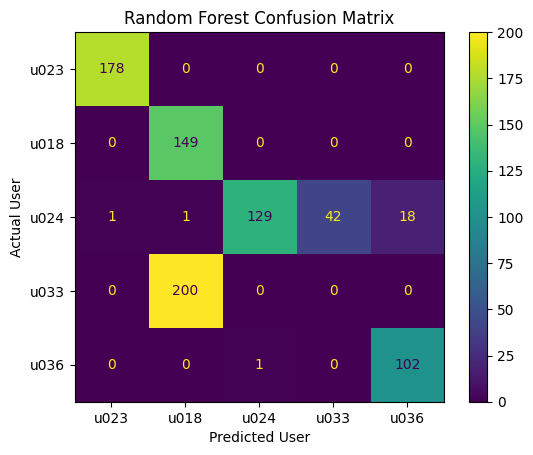

In [194]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_users
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted User")
plt.ylabel("Actual User")
plt.show()

In [195]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        labels=selected_users,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u023       0.99      1.00      1.00       178
        u018       0.43      1.00      0.60       149
        u024       0.99      0.68      0.80       191
        u033       0.00      0.00      0.00       200
        u036       0.85      0.99      0.91       103

    accuracy                           0.68       821
   macro avg       0.65      0.73      0.66       821
weighted avg       0.63      0.68      0.63       821



In [196]:
from pathlib import Path

results_path = Path(
    r"C:\Users\vatsa\Parkinson_Project\results"
)

results_path.mkdir(
    parents=True,
    exist_ok=True
)

In [197]:
cm_df = pd.DataFrame(
    cm,
    index=selected_users,
    columns=selected_users
)

cm_df.to_csv(
    results_path / "random_forest_confusion_matrix.csv"
)

print("Confusion matrix saved.")

Confusion matrix saved.


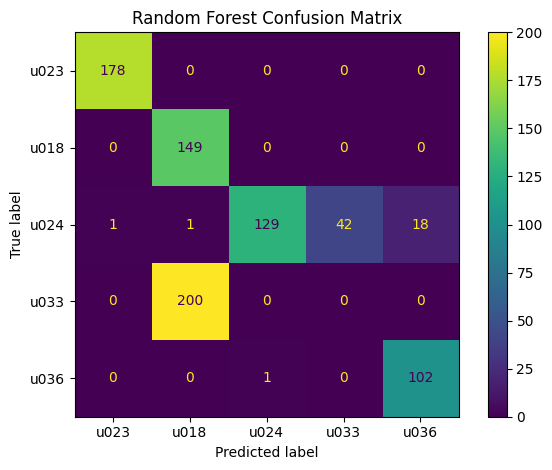

In [198]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_users
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    results_path / "random_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

In [199]:
import joblib

model_path = (
    results_path /
    "random_forest_model.pkl"
)

joblib.dump(
    rf_model,
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
C:\Users\vatsa\Parkinson_Project\results\random_forest_model.pkl


In [200]:
rf_model = joblib.load(
    model_path
)

In [201]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [202]:
y_pred = rf_model.predict(X_test)

In [203]:
print(
    f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%"
)

Accuracy: 67.97%


In [204]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=selected_users
)

print(cm)

[[178   0   0   0   0]
 [  0 149   0   0   0]
 [  1   1 129  42  18]
 [  0 200   0   0   0]
 [  0   0   1   0 102]]


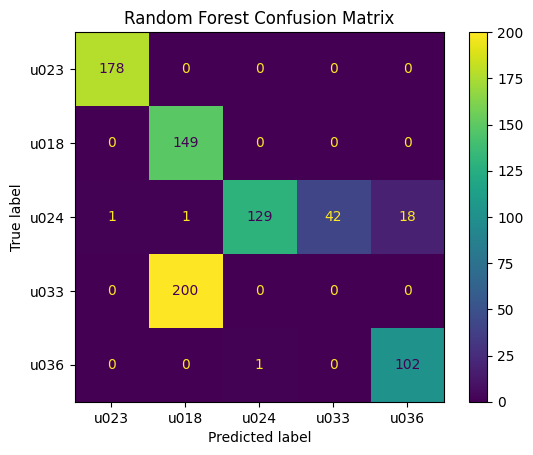

In [205]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_users
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [206]:
print("Training samples per user:")
print(y_train.value_counts())

print("\nTesting samples per user:")
print(y_test.value_counts())

Training samples per user:
label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64

Testing samples per user:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [207]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        labels=selected_users,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u023       0.99      1.00      1.00       178
        u018       0.43      1.00      0.60       149
        u024       0.99      0.68      0.80       191
        u033       0.00      0.00      0.00       200
        u036       0.85      0.99      0.91       103

    accuracy                           0.68       821
   macro avg       0.65      0.73      0.66       821
weighted avg       0.63      0.68      0.63       821



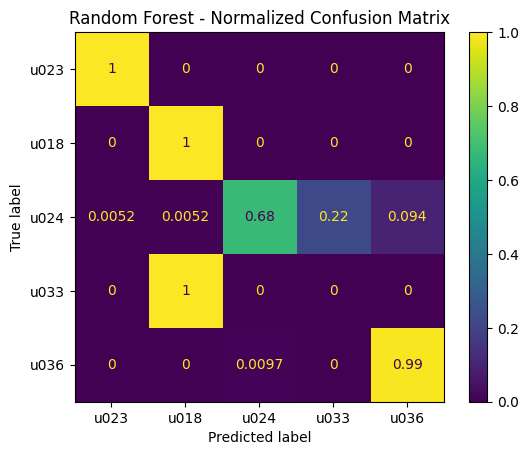

In [208]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=selected_users,
    normalize="true"
)

plt.title("Random Forest - Normalized Confusion Matrix")
plt.show()

In [209]:
print("Training samples:")
print(y_train.value_counts())

print("\nTesting samples:")
print(y_test.value_counts())

Training samples:
label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64

Testing samples:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [210]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        labels=selected_users,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u023       0.99      1.00      1.00       178
        u018       0.43      1.00      0.60       149
        u024       0.99      0.68      0.80       191
        u033       0.00      0.00      0.00       200
        u036       0.85      0.99      0.91       103

    accuracy                           0.68       821
   macro avg       0.65      0.73      0.66       821
weighted avg       0.63      0.68      0.63       821



In [188]:
def zero_crossing_rate(signal):
    """
    Calculate how frequently a signal crosses its mean.
    """

    centered = signal - np.mean(signal)

    crossings = np.sum(
        centered[:-1] * centered[1:] < 0
    )

    return crossings / len(signal)

In [193]:
def extract_frequency_features(signal, sampling_rate=59.47):
    """
    Extract basic frequency-domain features.
    """

    n = len(signal)

    # Remove DC component
    centered = signal - np.mean(signal)

    # FFT
    fft_values = np.fft.rfft(centered)

    # Frequencies
    frequencies = np.fft.rfftfreq(
        n,
        d=1 / sampling_rate
    )

    # Power
    power = np.abs(fft_values) ** 2

    # Ignore the zero-frequency component
    if len(power) > 1:
        power[0] = 0

    # Dominant frequency
    dominant_frequency = frequencies[
        np.argmax(power)
    ]

    # Spectral energy
    spectral_energy = np.sum(power)

    return {
        "dominant_frequency": dominant_frequency,
        "spectral_energy": spectral_energy
    }

In [194]:
def extract_improved_features(window):
    """
    Extract time-domain + frequency-domain features.
    """

    sensor_names = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x", "mag_y", "mag_z"
    ]

    features = {}

    sampling_rate = 59.47

    for i, sensor in enumerate(sensor_names):

        signal = window[:, i]

        # Time-domain features
        features[f"{sensor}_mean"] = np.mean(signal)
        features[f"{sensor}_std"] = np.std(signal)
        features[f"{sensor}_min"] = np.min(signal)
        features[f"{sensor}_max"] = np.max(signal)
        features[f"{sensor}_median"] = np.median(signal)
        features[f"{sensor}_range"] = (
            np.max(signal) - np.min(signal)
        )

        features[f"{sensor}_rms"] = np.sqrt(
            np.mean(signal ** 2)
        )

        # Zero-crossing rate
        features[f"{sensor}_zcr"] = (
            zero_crossing_rate(signal)
        )

        # Frequency-domain features
        freq_features = extract_frequency_features(
            signal,
            sampling_rate=sampling_rate
        )

        features[f"{sensor}_dominant_freq"] = (
            freq_features["dominant_frequency"]
        )

        features[f"{sensor}_spectral_energy"] = (
            freq_features["spectral_energy"]
        )

    return features

In [195]:
def extract_improved_features(window):
    """
    Extract time-domain + frequency-domain features.
    """

    sensor_names = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x", "mag_y", "mag_z"
    ]

    features = {}

    sampling_rate = 59.47

    for i, sensor in enumerate(sensor_names):

        signal = window[:, i]

        # Time-domain features
        features[f"{sensor}_mean"] = np.mean(signal)
        features[f"{sensor}_std"] = np.std(signal)
        features[f"{sensor}_min"] = np.min(signal)
        features[f"{sensor}_max"] = np.max(signal)
        features[f"{sensor}_median"] = np.median(signal)
        features[f"{sensor}_range"] = (
            np.max(signal) - np.min(signal)
        )

        features[f"{sensor}_rms"] = np.sqrt(
            np.mean(signal ** 2)
        )

        # Zero-crossing rate
        features[f"{sensor}_zcr"] = (
            zero_crossing_rate(signal)
        )

        # Frequency-domain features
        freq_features = extract_frequency_features(
            signal,
            sampling_rate=sampling_rate
        )

        features[f"{sensor}_dominant_freq"] = (
            freq_features["dominant_frequency"]
        )

        features[f"{sensor}_spectral_energy"] = (
            freq_features["spectral_energy"]
        )

    return features

In [196]:
print(
    "Missing values:",
    improved_features_df.isnull().sum().sum()
)

NameError: name 'improved_features_df' is not defined

In [216]:
improved_features = []

for window in windows:
    improved_features.append(
        extract_improved_features(window)
    )

improved_features_df = pd.DataFrame(
    improved_features
)

print(improved_features_df.shape)

(103, 90)


In [217]:
    print(
        "Missing values:",
        improved_features_df.isnull().sum().sum()
    )

Missing values: 0


In [218]:
improved_features_df.head()

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_median,acc_x_range,acc_x_rms,acc_x_zcr,acc_x_dominant_freq,acc_x_spectral_energy,...,mag_z_mean,mag_z_std,mag_z_min,mag_z_max,mag_z_median,mag_z_range,mag_z_rms,mag_z_zcr,mag_z_dominant_freq,mag_z_spectral_energy
0,0.946716,3.370284,-11.249920,13.970403,0.183387,25.220323,3.500726,0.111111,0.200236,500974.865051,...,-11.511472,10.266292,-24.324036,17.794800,-16.365051,42.118836,15.424355,0.003367,0.200236,4.648471e+06
1,1.770877,3.870722,-11.249920,17.472320,1.211171,28.722240,4.256583,0.134680,0.400471,660795.346809,...,9.676127,17.100019,-19.847107,38.356018,16.964722,58.203125,19.647852,0.010101,0.200236,1.289663e+07
2,2.424976,3.714876,-11.249920,19.036049,2.523625,30.285969,4.436306,0.178451,0.200236,608655.417728,...,23.038321,5.518542,9.336853,38.356018,24.261475,29.019165,23.690051,0.080808,0.800943,1.343172e+06
3,3.548471,3.166501,-5.030256,20.977986,3.054124,26.008241,4.755878,0.208754,4.405185,442223.826508,...,24.415121,6.836120,9.336853,35.702515,25.918580,26.365662,25.354105,0.037037,0.800943,2.061115e+06
4,3.003333,2.764495,-3.255751,20.977986,2.698784,24.233736,4.081965,0.202020,4.405185,337065.629331,...,27.697451,6.806402,12.818909,38.356018,30.064392,25.537109,28.521499,0.050505,0.800943,2.043234e+06


In [219]:
train_feature_rows_v2 = []

for recording_name in train_recordings:

    folder = data_path / recording_name

    print("Processing:", recording_name)

    windows = process_recording(folder)

    label = recording_name.split("_")[0]

    for window in windows:

        features = extract_improved_features(window)

        features["label"] = label
        features["recording"] = recording_name

        train_feature_rows_v2.append(features)


train_df_v2 = pd.DataFrame(train_feature_rows_v2)

print("\nTraining dataset:")
print(train_df_v2.shape)

Processing: u023_w001
Processing: u023_w002
Processing: u023_w003
Processing: u023_w004
Processing: u023_w005
Processing: u023_w006
Processing: u023_w007
Processing: u023_w008
Processing: u023_w009
Processing: u023_w010
Processing: u023_w011
Processing: u018_w001
Processing: u018_w002
Processing: u018_w004
Processing: u018_w005
Processing: u018_w006
Processing: u018_w007
Processing: u018_w008
Processing: u018_w010
Processing: u018_w013
Processing: u024_w001
Processing: u024_w002
Processing: u024_w003
Processing: u024_w004
Processing: u024_w005
Processing: u024_w006
Processing: u024_w007
Processing: u033_w001
Processing: u033_w002
Processing: u033_w003
Processing: u033_w004
Processing: u033_w005
Processing: u036_w001
Processing: u036_w002
Processing: u036_w003
Processing: u036_w004

Training dataset:
(5723, 92)


In [220]:
test_feature_rows_v2 = []

for recording_name in test_recordings:

    folder = data_path / recording_name

    print("Processing:", recording_name)

    windows = process_recording(folder)

    label = recording_name.split("_")[0]

    for window in windows:

        features = extract_improved_features(window)

        features["label"] = label
        features["recording"] = recording_name

        test_feature_rows_v2.append(features)


test_df_v2 = pd.DataFrame(test_feature_rows_v2)

print("\nTesting dataset:")
print(test_df_v2.shape)

Processing: u023_w012
Processing: u018_w014
Processing: u024_w008
Processing: u033_w007
Processing: u036_w005

Testing dataset:
(821, 92)


In [221]:
feature_columns_v2 = [
    column
    for column in train_df_v2.columns
    if column not in ["label", "recording"]
]

print("Number of features:", len(feature_columns_v2))

Number of features: 90


In [222]:
print(
    "Training missing values:",
    train_df_v2[feature_columns_v2].isnull().sum().sum()
)

print(
    "Testing missing values:",
    test_df_v2[feature_columns_v2].isnull().sum().sum()
)

Training missing values: 0
Testing missing values: 0


In [223]:
X_train_v2 = train_df_v2[feature_columns_v2]
y_train_v2 = train_df_v2["label"]

X_test_v2 = test_df_v2[feature_columns_v2]
y_test_v2 = test_df_v2["label"]

print("X_train:", X_train_v2.shape)
print("y_train:", y_train_v2.shape)

print("X_test:", X_test_v2.shape)
print("y_test:", y_test_v2.shape)

X_train: (5723, 90)
y_train: (5723,)
X_test: (821, 90)
y_test: (821,)


In [224]:
print("Training samples:")
print(y_train_v2.value_counts())

print("\nTesting samples:")
print(y_test_v2.value_counts())

Training samples:
label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64

Testing samples:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [225]:
train_recording_set = set(
    train_df_v2["recording"].unique()
)

test_recording_set = set(
    test_df_v2["recording"].unique()
)

print(
    "Recording overlap:",
    train_recording_set & test_recording_set
)

Recording overlap: set()


In [226]:
processed_path = Path(
    r"C:\Users\vatsa\Parkinson_Project\processed"
)

train_df_v2.to_csv(
    processed_path / "train_features_90.csv",
    index=False
)

test_df_v2.to_csv(
    processed_path / "test_features_90.csv",
    index=False
)

print("90-feature datasets saved.")

90-feature datasets saved.


In [227]:
from sklearn.ensemble import RandomForestClassifier

rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [228]:
rf_model_v2.fit(
    X_train_v2,
    y_train_v2
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [229]:
y_pred_v2 = rf_model_v2.predict(
    X_test_v2
)

In [230]:
from sklearn.metrics import accuracy_score

accuracy_v2 = accuracy_score(
    y_test_v2,
    y_pred_v2
)

print(
    f"Improved Random Forest Accuracy: "
    f"{accuracy_v2 * 100:.2f}%"
)

Improved Random Forest Accuracy: 74.18%


In [231]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_v2 = confusion_matrix(
    y_test_v2,
    y_pred_v2,
    labels=selected_users
)

print(cm_v2)

[[178   0   0   0   0]
 [  0 149   0   0   0]
 [  0   0 179   5   7]
 [  0 200   0   0   0]
 [  0   0   0   0 103]]


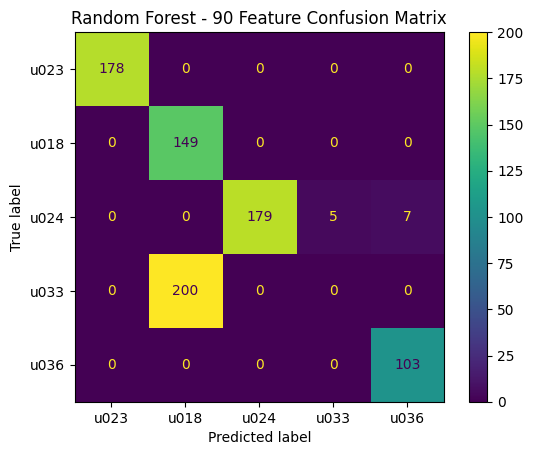

In [233]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v2,
    display_labels=selected_users
)

disp.plot()

plt.title(
    "Random Forest - 90 Feature Confusion Matrix"
)

plt.show()

In [234]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_v2,
        y_pred_v2,
        labels=selected_users,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u023       1.00      1.00      1.00       178
        u018       0.43      1.00      0.60       149
        u024       1.00      0.94      0.97       191
        u033       0.00      0.00      0.00       200
        u036       0.94      1.00      0.97       103

    accuracy                           0.74       821
   macro avg       0.67      0.79      0.71       821
weighted avg       0.64      0.74      0.67       821



In [235]:
feature_importance = pd.DataFrame({
    "feature": feature_columns_v2,
    "importance": rf_model_v2.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
48,gyro_y_dominant_freq,0.059964
58,gyro_z_dominant_freq,0.053781
38,gyro_x_dominant_freq,0.051933
57,gyro_z_zcr,0.048709
19,acc_y_spectral_energy,0.045471
17,acc_y_zcr,0.039803
59,gyro_z_spectral_energy,0.033318
76,mag_y_rms,0.031196
88,mag_z_dominant_freq,0.031134
44,gyro_y_median,0.030282


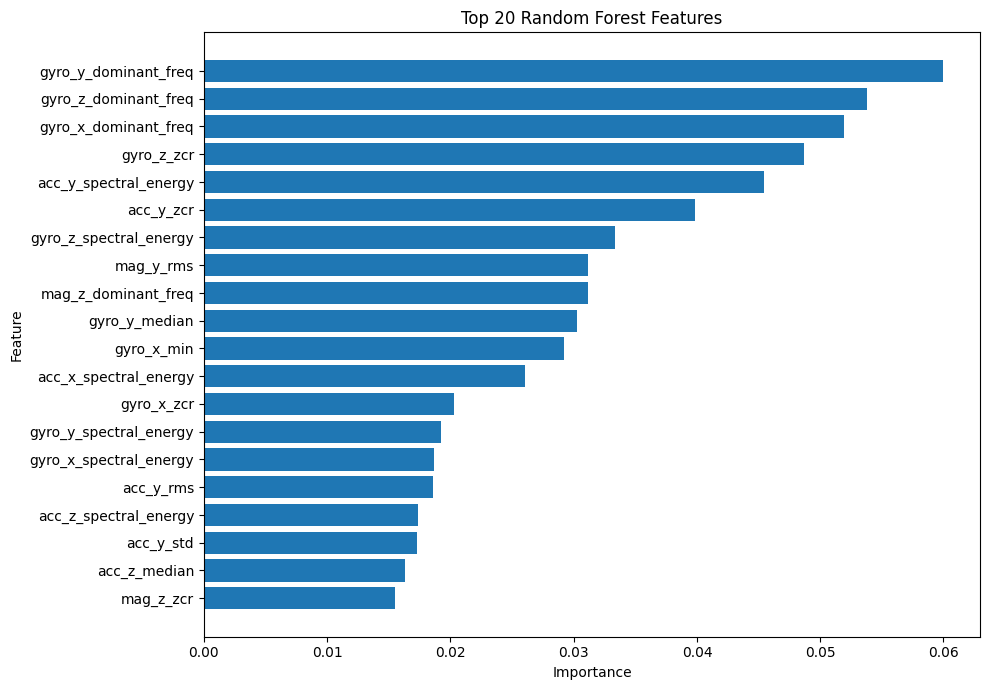

In [236]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Features")

plt.tight_layout()
plt.show()

In [237]:
u018_data = train_df_v2[
    train_df_v2["label"] == "u018"
]

u033_data = train_df_v2[
    train_df_v2["label"] == "u033"
]

print("u018 training samples:", len(u018_data))
print("u033 training samples:", len(u033_data))

u018 training samples: 2063
u033 training samples: 684


In [238]:
print(
    "u018 feature means:"
)

print(
    u018_data[feature_columns_v2].mean().head(20)
)

print(
    "\nu033 feature means:"
)

print(
    u033_data[feature_columns_v2].mean().head(20)
)

u018 feature means:
acc_x_mean                    0.457103
acc_x_std                     2.825592
acc_x_min                    -6.983609
acc_x_max                     9.012745
acc_x_median                  0.501361
acc_x_range                  15.996355
acc_x_rms                     2.984382
acc_x_zcr                     0.168146
acc_x_dominant_freq           4.318800
acc_x_spectral_energy    381572.096393
acc_y_mean                    9.429896
acc_y_std                     4.034121
acc_y_min                     1.173954
acc_y_max                    22.512713
acc_y_median                  9.121083
acc_y_range                  21.338759
acc_y_rms                    10.284768
acc_y_zcr                     0.133301
acc_y_dominant_freq           1.939948
acc_y_spectral_energy    766102.289409
dtype: float64

u033 feature means:
acc_x_mean              -2.614603e-01
acc_x_std                2.716322e+00
acc_x_min               -7.688356e+00
acc_x_max                1.033995e+01
acc_x_median

In [239]:
u018_mean = u018_data[
    feature_columns_v2
].mean()

u033_mean = u033_data[
    feature_columns_v2
].mean()

difference = (
    (u018_mean - u033_mean)
    .abs()
    .sort_values(
        ascending=False
    )
)

print(
    difference.head(20)
)

mag_x_spectral_energy     662275.052274
acc_y_spectral_energy     532911.594615
acc_z_spectral_energy     226222.615929
mag_z_spectral_energy     132847.440884
acc_x_spectral_energy      64566.337427
gyro_x_spectral_energy     33169.876234
gyro_z_spectral_energy     20710.844416
mag_y_spectral_energy      11389.410404
gyro_y_spectral_energy      2700.137949
mag_y_median                  17.063420
mag_y_mean                    16.778490
mag_y_min                     16.725564
mag_z_min                     16.080399
mag_y_max                     15.422749
mag_z_mean                    13.897149
mag_z_max                     13.878698
mag_z_rms                     13.662842
mag_z_median                  13.417416
acc_y_range                   12.817247
mag_y_rms                     11.220304
dtype: float64


In [240]:
feature_importance.head(20)

,feature,importance
48,gyro_y_dominant_freq,0.059964
58,gyro_z_dominant_freq,0.053781
38,gyro_x_dominant_freq,0.051933
57,gyro_z_zcr,0.048709
19,acc_y_spectral_energy,0.045471
17,acc_y_zcr,0.039803
59,gyro_z_spectral_energy,0.033318
76,mag_y_rms,0.031196
88,mag_z_dominant_freq,0.031134
44,gyro_y_median,0.030282


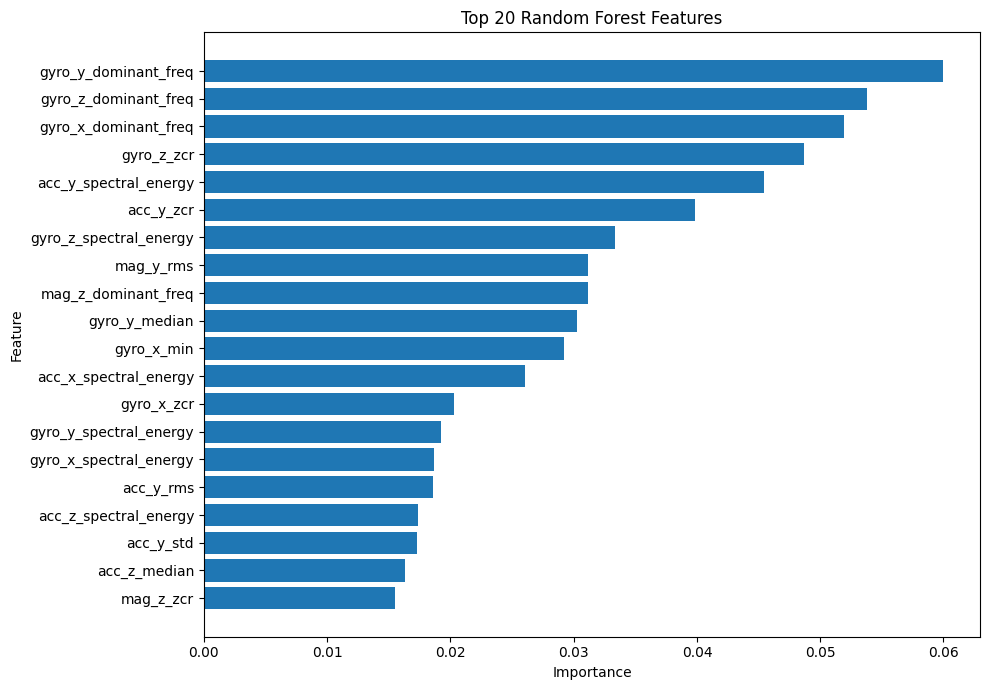

In [241]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Features")
plt.tight_layout()
plt.show()

In [242]:
print(difference.head(20))

mag_x_spectral_energy     662275.052274
acc_y_spectral_energy     532911.594615
acc_z_spectral_energy     226222.615929
mag_z_spectral_energy     132847.440884
acc_x_spectral_energy      64566.337427
gyro_x_spectral_energy     33169.876234
gyro_z_spectral_energy     20710.844416
mag_y_spectral_energy      11389.410404
gyro_y_spectral_energy      2700.137949
mag_y_median                  17.063420
mag_y_mean                    16.778490
mag_y_min                     16.725564
mag_z_min                     16.080399
mag_y_max                     15.422749
mag_z_mean                    13.897149
mag_z_max                     13.878698
mag_z_rms                     13.662842
mag_z_median                  13.417416
acc_y_range                   12.817247
mag_y_rms                     11.220304
dtype: float64


In [243]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [244]:
svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale"
        )
    )
])

In [245]:
svm_model.fit(
    X_train_v2,
    y_train_v2
)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

In [246]:
y_pred_svm = svm_model.predict(
    X_test_v2
)

In [247]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(
    y_test_v2,
    y_pred_svm
)

print(
    f"SVM Accuracy: {svm_accuracy * 100:.2f}%"
)

SVM Accuracy: 74.79%


In [248]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test_v2,
    y_pred_svm,
    labels=selected_users
)

print(cm_svm)

[[178   0   0   0   0]
 [  0 149   0   0   0]
 [  0   0 184   4   3]
 [  0  10 190   0   0]
 [  0   0   0   0 103]]


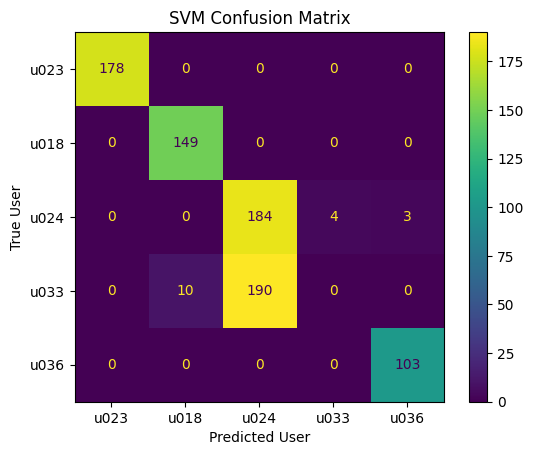

In [249]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=selected_users
)

disp.plot()

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted User")
plt.ylabel("True User")
plt.show()

In [250]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_v2,
        y_pred_svm,
        labels=selected_users,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u023       1.00      1.00      1.00       178
        u018       0.94      1.00      0.97       149
        u024       0.49      0.96      0.65       191
        u033       0.00      0.00      0.00       200
        u036       0.97      1.00      0.99       103

    accuracy                           0.75       821
   macro avg       0.68      0.79      0.72       821
weighted avg       0.62      0.75      0.67       821



In [251]:
print("Model Comparison")
print("----------------------------")
print(f"Random Forest: {accuracy_v2 * 100:.2f}%")
print(f"SVM:           {svm_accuracy * 100:.2f}%")

Model Comparison
----------------------------
Random Forest: 74.18%
SVM:           74.79%


In [252]:
svm_model.fit(X_train_v2, y_train_v2)
y_pred_svm = svm_model.predict(X_test_v2)

print(
    f"SVM Accuracy: {accuracy_score(y_test_v2, y_pred_svm) * 100:.2f}%"
)

SVM Accuracy: 74.79%


In [253]:
cm_svm = confusion_matrix(
    y_test_v2,
    y_pred_svm,
    labels=selected_users
)

print(cm_svm)

[[178   0   0   0   0]
 [  0 149   0   0   0]
 [  0   0 184   4   3]
 [  0  10 190   0   0]
 [  0   0   0   0 103]]


In [254]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM"
    ],
    "Features": [
        90,
        90
    ],
    "Accuracy": [
        accuracy_v2,
        svm_accuracy
    ]
})

comparison["Accuracy (%)"] = (
    comparison["Accuracy"] * 100
)

comparison[[
    "Model",
    "Features",
    "Accuracy (%)"
]]

,Model,Features,Accuracy (%)
0,Random Forest,90,74.177832
1,SVM,90,74.786845


In [257]:
import joblib

joblib.dump(
    svm_model,
    results_path / "svm_model.pkl"
)

print("SVM model saved successfully.")

SVM model saved successfully.


In [258]:
print(
    (results_path / "svm_model.pkl").exists()
)

True


In [259]:
for file in results_path.iterdir():
    print(file.name)

random_forest_confusion_matrix.csv
random_forest_confusion_matrix.png
random_forest_model.pkl
svm_model.pkl


In [260]:
loaded_svm_model = joblib.load(
    results_path / "svm_model.pkl"
)

print("SVM model loaded successfully.")

SVM model loaded successfully.


In [261]:
cm_svm_df = pd.DataFrame(
    cm_svm,
    index=selected_users,
    columns=selected_users
)

cm_svm_df.to_csv(
    results_path / "svm_confusion_matrix.csv"
)

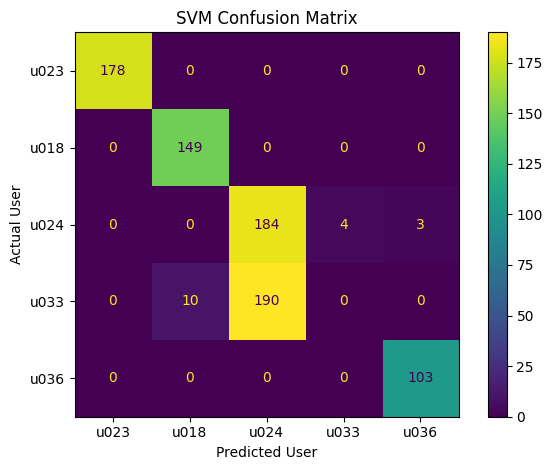

In [262]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=selected_users
)

disp.plot()

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted User")
plt.ylabel("Actual User")
plt.tight_layout()

plt.savefig(
    results_path / "svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [263]:
import joblib

joblib.dump(
    svm_model,
    results_path / "svm_model.pkl"
)

print("SVM model saved successfully!")

SVM model saved successfully!


In [264]:
print((results_path / "svm_model.pkl").exists())

True


In [265]:
for file in results_path.iterdir():
    print(file.name)

random_forest_confusion_matrix.csv
random_forest_confusion_matrix.png
random_forest_model.pkl
svm_confusion_matrix.csv
svm_confusion_matrix.png
svm_model.pkl


In [150]:
def process_recording(folder, target_rate=60, window_seconds=5, overlap=0.5):
    """
    Load accelerometer, gyroscope and magnetometer,
    synchronize them to a fixed 60 Hz timeline,
    and create fixed-size windows.

    Output:
        numpy array with shape:
        (number_of_windows, 300, 9)
    """

    recording_name = folder.name

    # --------------------------------------------------
    # 1. File paths
    # --------------------------------------------------

    acc_path = folder / f"{recording_name}_accelerometer.log"
    gyro_path = folder / f"{recording_name}_gyroscope.log"
    mag_path = folder / f"{recording_name}_magnetometer.log"

    # --------------------------------------------------
    # 2. Load sensor data
    # --------------------------------------------------

    acc_raw = pd.read_csv(acc_path, sep="\t")
    gyro_raw = pd.read_csv(gyro_path, sep="\t")
    mag_raw = pd.read_csv(mag_path, sep="\t")

    # --------------------------------------------------
    # 3. Standardize sensor format
    # --------------------------------------------------

    acc = prepare_sensor(acc_raw)
    gyro = prepare_sensor(gyro_raw)
    mag = prepare_sensor(mag_raw)

    # --------------------------------------------------
    # 4. Find common time interval
    # --------------------------------------------------

    common_start = max(
        acc["timestamp"].iloc[0],
        gyro["timestamp"].iloc[0],
        mag["timestamp"].iloc[0]
    )

    common_end = min(
        acc["timestamp"].iloc[-1],
        gyro["timestamp"].iloc[-1],
        mag["timestamp"].iloc[-1]
    )

    # --------------------------------------------------
    # 5. Create FIXED 60 Hz timeline
    # --------------------------------------------------

    interval_ns = 1e9 / target_rate

    master_time = np.arange(
        common_start,
        common_end,
        interval_ns
    )

    # Make sure timestamps are integers
    master_time = master_time.astype(np.int64)

    # --------------------------------------------------
    # 6. Interpolate accelerometer
    # --------------------------------------------------

    acc_time = acc["timestamp"].to_numpy()

    acc_x = np.interp(
        master_time,
        acc_time,
        acc["x"].to_numpy()
    )

    acc_y = np.interp(
        master_time,
        acc_time,
        acc["y"].to_numpy()
    )

    acc_z = np.interp(
        master_time,
        acc_time,
        acc["z"].to_numpy()
    )

    # --------------------------------------------------
    # 7. Interpolate gyroscope
    # --------------------------------------------------

    gyro_time = gyro["timestamp"].to_numpy()

    gyro_x = np.interp(
        master_time,
        gyro_time,
        gyro["x"].to_numpy()
    )

    gyro_y = np.interp(
        master_time,
        gyro_time,
        gyro["y"].to_numpy()
    )

    gyro_z = np.interp(
        master_time,
        gyro_time,
        gyro["z"].to_numpy()
    )

    # --------------------------------------------------
    # 8. Interpolate magnetometer
    # --------------------------------------------------

    mag_time = mag["timestamp"].to_numpy()

    mag_x = np.interp(
        master_time,
        mag_time,
        mag["x"].to_numpy()
    )

    mag_y = np.interp(
        master_time,
        mag_time,
        mag["y"].to_numpy()
    )

    mag_z = np.interp(
        master_time,
        mag_time,
        mag["z"].to_numpy()
    )

    # --------------------------------------------------
    # 9. Create synchronized DataFrame
    # --------------------------------------------------

    sync_df = pd.DataFrame({
        "timestamp": master_time,

        "acc_x": acc_x,
        "acc_y": acc_y,
        "acc_z": acc_z,

        "gyro_x": gyro_x,
        "gyro_y": gyro_y,
        "gyro_z": gyro_z,

        "mag_x": mag_x,
        "mag_y": mag_y,
        "mag_z": mag_z
    })

    # Elapsed time
    sync_df["time_s"] = (
        sync_df["timestamp"] -
        sync_df["timestamp"].iloc[0]
    ) / 1e9

    # --------------------------------------------------
    # 10. Create FIXED-SIZE windows
    # --------------------------------------------------

    sensor_columns = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x", "mag_y", "mag_z"
    ]

    values = sync_df[sensor_columns].to_numpy()

    samples_per_window = int(
        target_rate * window_seconds
    )

    step = int(
        samples_per_window * (1 - overlap)
    )

    windows = []

    for start in range(
        0,
        len(values) - samples_per_window + 1,
        step
    ):

        end = start + samples_per_window

        window = values[start:end]

        # Safety check
        if window.shape == (
            samples_per_window,
            len(sensor_columns)
        ):
            windows.append(window)

    return np.array(windows)

In [151]:
test_windows = process_recording(
    data_path / "u001_w001"
)

print("Shape:", test_windows.shape)
print("One window:", test_windows[0].shape)

Shape: (106, 300, 9)
One window: (300, 9)


In [152]:
test_recordings_check = [
    "u001_w001",
    "u002_w001",
    "u018_w001",
    "u023_w001",
    "u036_w001"
]

for recording_name in test_recordings_check:

    windows_test = process_recording(
        data_path / recording_name
    )

    print(
        recording_name,
        "→",
        windows_test.shape
    )

u001_w001 → (106, 300, 9)
u002_w001 → (191, 300, 9)
u018_w001 → (329, 300, 9)
u023_w001 → (137, 300, 9)
u036_w001 → (99, 300, 9)


In [153]:
test_windows = process_recording(
    data_path / "u001_w001"
)

print("Shape:", test_windows.shape)
print("One window:", test_windows[0].shape)

Shape: (106, 300, 9)
One window: (300, 9)


In [154]:
test_recordings_check = [
    "u001_w001",
    "u002_w001",
    "u018_w001",
    "u023_w001",
    "u036_w001"
]

for recording_name in test_recordings_check:

    windows_test = process_recording(
        data_path / recording_name
    )

    print(
        recording_name,
        "→",
        windows_test.shape
    )

u001_w001 → (106, 300, 9)
u002_w001 → (191, 300, 9)
u018_w001 → (329, 300, 9)
u023_w001 → (137, 300, 9)
u036_w001 → (99, 300, 9)


In [276]:
X_train_raw = []
y_train_raw = []

for recording_name in train_recordings:

    folder = data_path / recording_name

    print("Processing:", recording_name)

    recording_windows = process_recording(folder)

    label = recording_name.split("_")[0]

    for window in recording_windows:

        X_train_raw.append(window)
        y_train_raw.append(label)

X_train_raw = np.array(
    X_train_raw,
    dtype=np.float32
)

y_train_raw = np.array(
    y_train_raw
)

print("Training data shape:", X_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)

Processing: u023_w001
Processing: u023_w002
Processing: u023_w003
Processing: u023_w004
Processing: u023_w005
Processing: u023_w006
Processing: u023_w007
Processing: u023_w008
Processing: u023_w009
Processing: u023_w010
Processing: u023_w011
Processing: u018_w001
Processing: u018_w002
Processing: u018_w004
Processing: u018_w005
Processing: u018_w006
Processing: u018_w007
Processing: u018_w008
Processing: u018_w010
Processing: u018_w013
Processing: u024_w001
Processing: u024_w002
Processing: u024_w003
Processing: u024_w004
Processing: u024_w005
Processing: u024_w006
Processing: u024_w007
Processing: u033_w001
Processing: u033_w002
Processing: u033_w003
Processing: u033_w004
Processing: u033_w005
Processing: u036_w001
Processing: u036_w002
Processing: u036_w003
Processing: u036_w004
Training data shape: (5834, 300, 9)
Training labels shape: (5834,)


In [277]:
X_test_raw = []
y_test_raw = []

for recording_name in test_recordings:

    folder = data_path / recording_name

    print("Processing:", recording_name)

    recording_windows = process_recording(folder)

    label = recording_name.split("_")[0]

    for window in recording_windows:

        X_test_raw.append(window)
        y_test_raw.append(label)

X_test_raw = np.array(
    X_test_raw,
    dtype=np.float32
)

y_test_raw = np.array(
    y_test_raw
)

print("Testing data shape:", X_test_raw.shape)
print("Testing labels shape:", y_test_raw.shape)

Processing: u023_w012
Processing: u018_w014
Processing: u024_w008
Processing: u033_w007
Processing: u036_w005
Testing data shape: (806, 300, 9)
Testing labels shape: (806,)


In [278]:
channel_mean = X_train_raw.mean(
    axis=(0, 1),
    keepdims=True
)

channel_std = X_train_raw.std(
    axis=(0, 1),
    keepdims=True
)

# Protect against division by zero
channel_std[channel_std == 0] = 1

print("Channel means:")
print(channel_mean.reshape(-1))

print("\nChannel standard deviations:")
print(channel_std.reshape(-1))

Channel means:
[ 3.9889213e-01  8.9608231e+00  1.5982136e-01 -1.0877115e-03
 -3.1323940e-02 -1.7187448e-02 -4.7336235e+00 -2.0638506e+01
  1.0136710e+01]

Channel standard deviations:
[ 3.6819618  4.7239046  3.590162   1.4584676  1.257928   1.02731
 19.760258  27.001053  27.445484 ]


In [279]:
X_train_scaled = (
    X_train_raw - channel_mean
) / channel_std

In [280]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print(
    "\nTraining global mean:",
    X_train_scaled.mean()
)

print(
    "Training global std:",
    X_train_scaled.std()
)

Training shape: (5834, 300, 9)


NameError: name 'X_test_scaled' is not defined

In [281]:
X_test_scaled = (
    X_test_raw - channel_mean
) / channel_std

In [282]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (5834, 300, 9)
Testing shape: (806, 300, 9)


In [283]:
print("Training global mean:", X_train_scaled.mean())
print("Training global std:", X_train_scaled.std())

Training global mean: -1.6539721e-05
Training global std: 1.0005605


In [284]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train_raw
)

y_test_encoded = label_encoder.transform(
    y_test_raw
)

print("Classes:", label_encoder.classes_)

Classes: ['u018' 'u023' 'u024' 'u033' 'u036']


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print(
    "Device:",
    "cuda" if torch.cuda.is_available() else "cpu"
)

PyTorch version: 2.8.0+cpu
Device: cpu


In [2]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_encoded,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_encoded,
    dtype=torch.long
)

NameError: name 'X_train_scaled' is not defined

In [3]:
print(X_train_raw.shape)
print(X_test_raw.shape)

NameError: name 'X_train_raw' is not defined

In [4]:
print(data_path)
print(len(train_recordings))
print(len(test_recordings))

NameError: name 'data_path' is not defined

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

# Dataset location
data_path = Path(
    r"C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset"
)

# Project locations
project_path = Path(
    r"C:\Users\vatsa\Parkinson_Project"
)

processed_path = project_path / "processed"
results_path = project_path / "results"

processed_path.mkdir(parents=True, exist_ok=True)
results_path.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", data_path.exists())
print("Project path:", project_path)
print("Dataset path:", data_path)

Dataset exists: True
Project path: C:\Users\vatsa\Parkinson_Project
Dataset path: C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset


In [7]:
import re

recording_folders = sorted(
    [
        p for p in data_path.iterdir()
        if p.is_dir()
        and re.fullmatch(r"u\d+_w\d+", p.name)
    ]
)

print("Total recordings:", len(recording_folders))

Total recordings: 135


In [8]:
import re

recording_folders = sorted(
    [
        p for p in data_path.iterdir()
        if p.is_dir()
        and re.fullmatch(r"u\d+_w\d+", p.name)
    ]
)

print("Total recordings:", len(recording_folders))

Total recordings: 135


In [9]:
valid_report = quality_report[
    quality_report["status"] == "TECHNICALLY VALID"
].copy()

valid_counts = (
    valid_report
    .groupby("subject")
    .size()
    .sort_values(ascending=False)
)

eligible_users = valid_counts[
    valid_counts >= 2
].index.tolist()

selected_users = eligible_users[:5]

print("Selected users:")
print(selected_users)

NameError: name 'quality_report' is not defined

In [10]:
import pandas as pd
from pathlib import Path

project_path = Path(
    r"C:\Users\vatsa\Parkinson_Project"
)

processed_path = project_path / "processed"

quality_report = pd.read_csv(
    processed_path / "quality_report.csv"
)

print("Quality report loaded:", quality_report.shape)

Quality report loaded: (135, 31)


In [11]:
valid_report = quality_report[
    quality_report["status"] == "TECHNICALLY VALID"
].copy()

print("Valid recordings:", len(valid_report))

Valid recordings: 119


In [12]:
valid_counts = (
    valid_report
    .groupby("subject")
    .size()
    .sort_values(ascending=False)
)

eligible_users = valid_counts[
    valid_counts >= 2
].index.tolist()

print("Eligible users:")
print(eligible_users)

Eligible users:
['u023', 'u018', 'u024', 'u033', 'u036', 'u043', 'u028', 'u010', 'u040', 'u001', 'u002', 'u046', 'u021', 'u025', 'u012', 'u007', 'u038', 'u035', 'u037', 'u026', 'u030', 'u031', 'u027', 'u020', 'u014']


In [13]:
selected_users = eligible_users[:5]

print("Selected users:")
print(selected_users)

Selected users:
['u023', 'u018', 'u024', 'u033', 'u036']


In [14]:
train_recordings = []
test_recordings = []

for user in selected_users:

    user_data = valid_report[
        valid_report["subject"] == user
    ].sort_values("recording")

    recordings = user_data["recording"].tolist()

    # Last recording = test
    test_recordings.append(recordings[-1])

    # Earlier recordings = training
    train_recordings.extend(recordings[:-1])

print("Training recordings:")
print(train_recordings)

print("\nTesting recordings:")
print(test_recordings)

Training recordings:
['u023_w001', 'u023_w002', 'u023_w003', 'u023_w004', 'u023_w005', 'u023_w006', 'u023_w007', 'u023_w008', 'u023_w009', 'u023_w010', 'u023_w011', 'u018_w001', 'u018_w002', 'u018_w004', 'u018_w005', 'u018_w006', 'u018_w007', 'u018_w008', 'u018_w010', 'u018_w013', 'u024_w001', 'u024_w002', 'u024_w003', 'u024_w004', 'u024_w005', 'u024_w006', 'u024_w007', 'u033_w001', 'u033_w002', 'u033_w003', 'u033_w004', 'u033_w005', 'u036_w001', 'u036_w002', 'u036_w003', 'u036_w004']

Testing recordings:
['u023_w012', 'u018_w014', 'u024_w008', 'u033_w007', 'u036_w005']


In [15]:
print("Users:", selected_users)
print("Training recordings:", len(train_recordings))
print("Testing recordings:", len(test_recordings))

Users: ['u023', 'u018', 'u024', 'u033', 'u036']
Training recordings: 36
Testing recordings: 5


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd

data_path = Path(
    r"C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset"
)

project_path = Path(
    r"C:\Users\vatsa\Parkinson_Project"
)

processed_path = project_path / "processed"
results_path = project_path / "results"

quality_report = pd.read_csv(
    processed_path / "quality_report.csv"
)

print("Dataset exists:", data_path.exists())
print("Quality report:", quality_report.shape)

Dataset exists: True
Quality report: (135, 31)


In [17]:
valid_report = quality_report[
    quality_report["status"] == "TECHNICALLY VALID"
].copy()

valid_counts = (
    valid_report
    .groupby("subject")
    .size()
    .sort_values(ascending=False)
)

eligible_users = valid_counts[
    valid_counts >= 2
].index.tolist()

selected_users = eligible_users[:5]

print("Selected users:")
print(selected_users)

Selected users:
['u023', 'u018', 'u024', 'u033', 'u036']


In [18]:
valid_report = quality_report[
    quality_report["status"] == "TECHNICALLY VALID"
].copy()

valid_counts = (
    valid_report
    .groupby("subject")
    .size()
    .sort_values(ascending=False)
)

eligible_users = valid_counts[
    valid_counts >= 2
].index.tolist()

selected_users = eligible_users[:5]

print("Selected users:")
print(selected_users)

Selected users:
['u023', 'u018', 'u024', 'u033', 'u036']


In [19]:
def prepare_sensor(df):
    df = df.iloc[:, :4].copy()

    df.columns = ["timestamp", "x", "y", "z"]

    df["timestamp"] = pd.to_numeric(
        df["timestamp"],
        errors="coerce"
    )

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["z"] = pd.to_numeric(df["z"], errors="coerce")

    df = df.dropna()
    df = df.sort_values("timestamp")

    df = df.drop_duplicates(
        subset="timestamp",
        keep="first"
    )

    return df.reset_index(drop=True)

In [20]:
def process_recording(
    folder,
    target_rate=60,
    window_seconds=5,
    overlap=0.5
):

    recording_name = folder.name

    acc_path = folder / f"{recording_name}_accelerometer.log"
    gyro_path = folder / f"{recording_name}_gyroscope.log"
    mag_path = folder / f"{recording_name}_magnetometer.log"

    acc_raw = pd.read_csv(acc_path, sep="\t")
    gyro_raw = pd.read_csv(gyro_path, sep="\t")
    mag_raw = pd.read_csv(mag_path, sep="\t")

    acc = prepare_sensor(acc_raw)
    gyro = prepare_sensor(gyro_raw)
    mag = prepare_sensor(mag_raw)

    common_start = max(
        acc["timestamp"].iloc[0],
        gyro["timestamp"].iloc[0],
        mag["timestamp"].iloc[0]
    )

    common_end = min(
        acc["timestamp"].iloc[-1],
        gyro["timestamp"].iloc[-1],
        mag["timestamp"].iloc[-1]
    )

    # Fixed 60 Hz timeline
    interval_ns = 1e9 / target_rate

    master_time = np.arange(
        common_start,
        common_end,
        interval_ns
    ).astype(np.int64)

    # Accelerometer interpolation
    acc_time = acc["timestamp"].to_numpy()

    acc_x = np.interp(
        master_time,
        acc_time,
        acc["x"].to_numpy()
    )

    acc_y = np.interp(
        master_time,
        acc_time,
        acc["y"].to_numpy()
    )

    acc_z = np.interp(
        master_time,
        acc_time,
        acc["z"].to_numpy()
    )

    # Gyroscope interpolation
    gyro_time = gyro["timestamp"].to_numpy()

    gyro_x = np.interp(
        master_time,
        gyro_time,
        gyro["x"].to_numpy()
    )

    gyro_y = np.interp(
        master_time,
        gyro_time,
        gyro["y"].to_numpy()
    )

    gyro_z = np.interp(
        master_time,
        gyro_time,
        gyro["z"].to_numpy()
    )

    # Magnetometer interpolation
    mag_time = mag["timestamp"].to_numpy()

    mag_x = np.interp(
        master_time,
        mag_time,
        mag["x"].to_numpy()
    )

    mag_y = np.interp(
        master_time,
        mag_time,
        mag["y"].to_numpy()
    )

    mag_z = np.interp(
        master_time,
        mag_time,
        mag["z"].to_numpy()
    )

    # Synchronized data
    sync_df = pd.DataFrame({
        "timestamp": master_time,

        "acc_x": acc_x,
        "acc_y": acc_y,
        "acc_z": acc_z,

        "gyro_x": gyro_x,
        "gyro_y": gyro_y,
        "gyro_z": gyro_z,

        "mag_x": mag_x,
        "mag_y": mag_y,
        "mag_z": mag_z
    })

    sync_df["time_s"] = (
        sync_df["timestamp"]
        - sync_df["timestamp"].iloc[0]
    ) / 1e9

    sensor_columns = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "mag_x", "mag_y", "mag_z"
    ]

    values = sync_df[
        sensor_columns
    ].to_numpy()

    samples_per_window = int(
        target_rate * window_seconds
    )

    step = int(
        samples_per_window * (1 - overlap)
    )

    windows = []

    for start in range(
        0,
        len(values) - samples_per_window + 1,
        step
    ):

        end = start + samples_per_window

        window = values[start:end]

        if window.shape == (
            samples_per_window,
            len(sensor_columns)
        ):
            windows.append(window)

    return np.array(
        windows,
        dtype=np.float32
    )

In [21]:
test_windows = process_recording(
    data_path / train_recordings[0]
)

print(
    train_recordings[0],
    "→",
    test_windows.shape
)

print(
    "One window:",
    test_windows[0].shape
)

u023_w001 → (137, 300, 9)
One window: (300, 9)


In [22]:
for recording_name in [
    train_recordings[0],
    train_recordings[1],
    train_recordings[2],
    test_recordings[0]
]:

    w = process_recording(
        data_path / recording_name
    )

    print(
        recording_name,
        "→",
        w.shape
    )

u023_w001 → (137, 300, 9)
u023_w002 → (144, 300, 9)
u023_w003 → (175, 300, 9)
u023_w012 → (182, 300, 9)


In [23]:
X_train_raw = []
y_train_raw = []

for recording_name in train_recordings:

    print("Processing:", recording_name)

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window in windows:
        X_train_raw.append(window)
        y_train_raw.append(label)

X_train_raw = np.array(
    X_train_raw,
    dtype=np.float32
)

y_train_raw = np.array(
    y_train_raw
)

print("Training data shape:", X_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)

Processing: u023_w001
Processing: u023_w002
Processing: u023_w003
Processing: u023_w004
Processing: u023_w005
Processing: u023_w006
Processing: u023_w007
Processing: u023_w008
Processing: u023_w009
Processing: u023_w010
Processing: u023_w011
Processing: u018_w001
Processing: u018_w002
Processing: u018_w004
Processing: u018_w005
Processing: u018_w006
Processing: u018_w007
Processing: u018_w008
Processing: u018_w010
Processing: u018_w013
Processing: u024_w001
Processing: u024_w002
Processing: u024_w003
Processing: u024_w004
Processing: u024_w005
Processing: u024_w006
Processing: u024_w007
Processing: u033_w001
Processing: u033_w002
Processing: u033_w003
Processing: u033_w004
Processing: u033_w005
Processing: u036_w001
Processing: u036_w002
Processing: u036_w003
Processing: u036_w004
Training data shape: (5834, 300, 9)
Training labels shape: (5834,)


In [24]:
X_test_raw = []
y_test_raw = []

for recording_name in test_recordings:

    print("Processing:", recording_name)

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window in windows:
        X_test_raw.append(window)
        y_test_raw.append(label)

X_test_raw = np.array(
    X_test_raw,
    dtype=np.float32
)

y_test_raw = np.array(
    y_test_raw
)

print("Testing data shape:", X_test_raw.shape)
print("Testing labels shape:", y_test_raw.shape)

Processing: u023_w012
Processing: u018_w014
Processing: u024_w008
Processing: u033_w007
Processing: u036_w005
Testing data shape: (806, 300, 9)
Testing labels shape: (806,)


In [25]:
channel_mean = X_train_raw.mean(
    axis=(0, 1),
    keepdims=True
)

channel_std = X_train_raw.std(
    axis=(0, 1),
    keepdims=True
)

channel_std[channel_std == 0] = 1

X_train_scaled = (
    X_train_raw - channel_mean
) / channel_std

X_test_scaled = (
    X_test_raw - channel_mean
) / channel_std

In [27]:
print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())

Train: (5834, 300, 9)
Test: (806, 300, 9)
Mean: -1.6539721e-05
Std: 1.0005605


In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train_raw
)

y_test_encoded = label_encoder.transform(
    y_test_raw
)

print("Classes:")
print(label_encoder.classes_)

Classes:
['u018' 'u023' 'u024' 'u033' 'u036']


In [29]:
import torch

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_encoded,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_encoded,
    dtype=torch.long
)

In [30]:
X_train_tensor = X_train_tensor.permute(0, 2, 1)
X_test_tensor = X_test_tensor.permute(0, 2, 1)

In [31]:
print("Training tensor:", X_train_tensor.shape)
print("Testing tensor:", X_test_tensor.shape)

Training tensor: torch.Size([5834, 9, 300])
Testing tensor: torch.Size([806, 9, 300])


In [32]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [33]:
X_batch, y_batch = next(
    iter(train_loader)
)

print("Batch X:", X_batch.shape)
print("Batch y:", y_batch.shape)

Batch X: torch.Size([64, 9, 300])
Batch y: torch.Size([64])


In [34]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [35]:
import torch.nn as nn


class CNN1D(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=9,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            ),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool1d(1),

            nn.Flatten(),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [36]:
num_classes = len(
    label_encoder.classes_
)

model = CNN1D(
    num_classes=num_classes
).to(device)

print(model)

CNN1D(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [37]:
criterion = nn.CrossEntropyLoss()

In [38]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [39]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

In [40]:
X_train_tensor = X_train_tensor.cpu()
y_train_tensor = y_train_tensor.cpu()

X_test_tensor = X_test_tensor.cpu()
y_test_tensor = y_test_tensor.cpu()

In [41]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [42]:
X_batch, y_batch = next(
    iter(train_loader)
)

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([64, 9, 300])
y batch: torch.Size([64])


In [43]:
model.train()

running_loss = 0.0

for X_batch, y_batch in train_loader:

    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    # Clear old gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_batch)

    # Calculate loss
    loss = criterion(
        outputs,
        y_batch
    )

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    running_loss += loss.item()


average_loss = (
    running_loss / len(train_loader)
)

print(
    f"Training loss: {average_loss:.4f}"
)

Training loss: 0.8277


In [44]:
outputs = model(X_batch)
loss = criterion(outputs, y_batch)
loss.backward()
optimizer.step()

In [45]:
model.eval()

with torch.no_grad():

    sample_output = model(
        X_batch.to(device)
    )

print(
    "Output shape:",
    sample_output.shape
)

Output shape: torch.Size([10, 5])


In [46]:
print("Device:", device)
print(model)

Device: cpu
CNN1D(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [47]:
X_batch, y_batch = next(iter(train_loader))
print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([64, 9, 300])
y batch: torch.Size([64])


In [48]:
model.eval()

with torch.no_grad():
    sample_output = model(
        X_batch.to(device)
    )

print("Output shape:", sample_output.shape)

Output shape: torch.Size([64, 5])


In [49]:
num_classes = len(label_encoder.classes_)

model = CNN1D(
    num_classes=num_classes
).to(device)

In [50]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [51]:
def evaluate_model(model, data_loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += y_batch.size(0)

            correct += (
                predictions == y_batch
            ).sum().item()

    accuracy = correct / total

    return accuracy

In [52]:
num_epochs = 20

train_losses = []
test_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    average_loss = (
        running_loss /
        len(train_loader)
    )

    test_accuracy = evaluate_model(
        model,
        test_loader,
        device
    )

    train_losses.append(
        average_loss
    )

    test_accuracies.append(
        test_accuracy
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Test Accuracy: {test_accuracy * 100:.2f}%"
    )

Epoch 01/20 | Loss: 0.8461 | Test Accuracy: 74.19%
Epoch 02/20 | Loss: 0.2402 | Test Accuracy: 70.97%
Epoch 03/20 | Loss: 0.1252 | Test Accuracy: 70.60%
Epoch 04/20 | Loss: 0.0782 | Test Accuracy: 58.44%
Epoch 05/20 | Loss: 0.0549 | Test Accuracy: 57.07%
Epoch 06/20 | Loss: 0.0427 | Test Accuracy: 65.26%
Epoch 07/20 | Loss: 0.0329 | Test Accuracy: 70.35%
Epoch 08/20 | Loss: 0.0280 | Test Accuracy: 70.47%
Epoch 09/20 | Loss: 0.0235 | Test Accuracy: 71.34%
Epoch 10/20 | Loss: 0.0193 | Test Accuracy: 68.36%
Epoch 11/20 | Loss: 0.0171 | Test Accuracy: 66.50%
Epoch 12/20 | Loss: 0.0159 | Test Accuracy: 65.88%
Epoch 13/20 | Loss: 0.0133 | Test Accuracy: 74.19%
Epoch 14/20 | Loss: 0.0132 | Test Accuracy: 63.03%
Epoch 15/20 | Loss: 0.0107 | Test Accuracy: 70.22%
Epoch 16/20 | Loss: 0.0085 | Test Accuracy: 73.20%
Epoch 17/20 | Loss: 0.0079 | Test Accuracy: 71.96%
Epoch 18/20 | Loss: 0.0063 | Test Accuracy: 74.94%
Epoch 19/20 | Loss: 0.0064 | Test Accuracy: 74.07%
Epoch 20/20 | Loss: 0.0058 | Te

In [53]:
best_epoch = np.argmax(
    test_accuracies
) + 1

best_accuracy = max(
    test_accuracies
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best test accuracy: "
    f"{best_accuracy * 100:.2f}%"
)

Best epoch: 20
Best test accuracy: 75.93%


In [55]:
import matplotlib.pyplot as plt

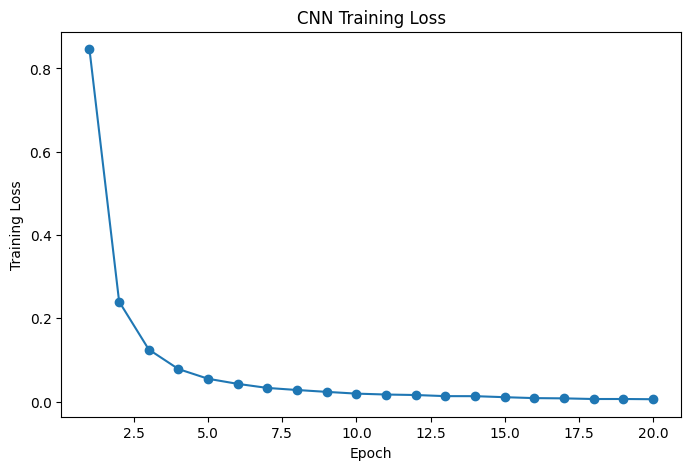

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.show()

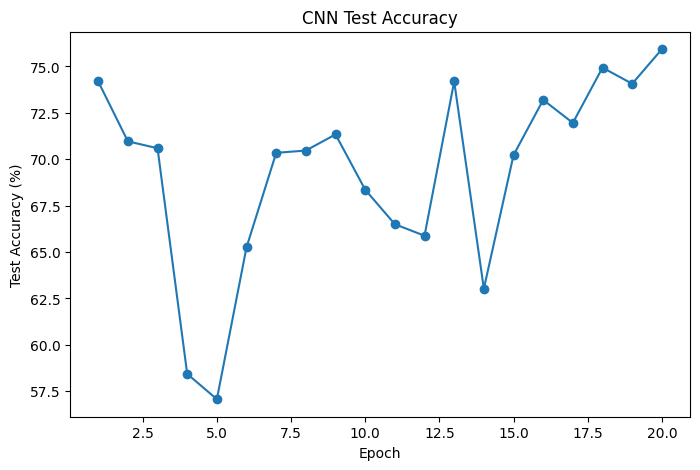

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    np.array(test_accuracies) * 100,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN Test Accuracy")

plt.show()

In [58]:
model.eval()

cnn_predictions = []
cnn_actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        cnn_predictions.extend(
            predictions.cpu().numpy()
        )

        cnn_actual.extend(
            y_batch.numpy()
        )

cnn_predictions = np.array(
    cnn_predictions
)

cnn_actual = np.array(
    cnn_actual
)

In [59]:
cnn_accuracy = accuracy_score(
    cnn_actual,
    cnn_predictions
)

print(
    f"CNN Accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

NameError: name 'accuracy_score' is not defined

In [60]:
from sklearn.metrics import accuracy_score

In [61]:
cnn_accuracy = accuracy_score(
    cnn_actual,
    cnn_predictions
)

print(
    f"CNN Accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

CNN Accuracy: 75.93%


In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [63]:
cnn_cm = confusion_matrix(
    cnn_actual,
    cnn_predictions
)

print(cnn_cm)

[[142   0   0   0   0]
 [  0 182   0   0   0]
 [  0   0 186   3   1]
 [  5   0 185   0   0]
 [  0   0   0   0 102]]


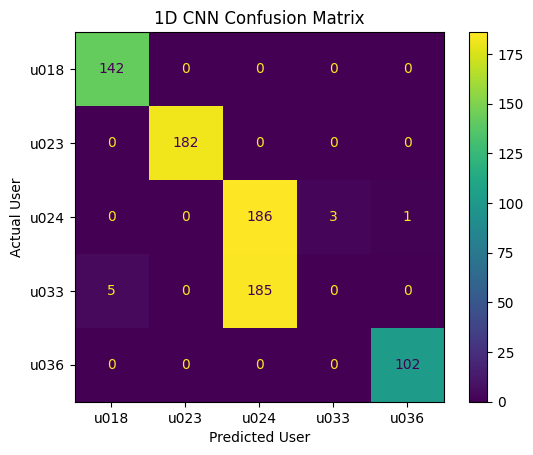

In [64]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("1D CNN Confusion Matrix")
plt.xlabel("Predicted User")
plt.ylabel("Actual User")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        cnn_actual,
        cnn_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u018       0.97      1.00      0.98       142
        u023       1.00      1.00      1.00       182
        u024       0.50      0.98      0.66       190
        u033       0.00      0.00      0.00       190
        u036       0.99      1.00      1.00       102

    accuracy                           0.76       806
   macro avg       0.69      0.80      0.73       806
weighted avg       0.64      0.76      0.68       806



In [66]:
cnn_model_path = (
    results_path / "cnn_1d_model.pth"
)

torch.save(
    model.state_dict(),
    cnn_model_path
)

print(
    "CNN model saved to:"
)

print(cnn_model_path)

CNN model saved to:
C:\Users\vatsa\Parkinson_Project\results\cnn_1d_model.pth


In [67]:
model = CNN1D(
    num_classes=num_classes
)

model.load_state_dict(
    torch.load(
        cnn_model_path,
        map_location=device
    )
)

model.to(device)

CNN1D(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)

In [68]:
cnn_cm_df = pd.DataFrame(
    cnn_cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cnn_cm_df.to_csv(
    results_path / "cnn_confusion_matrix.csv"
)

print("CNN confusion matrix saved.")

CNN confusion matrix saved.


In [69]:
cnn_metrics = pd.DataFrame([{
    "Model": "1D CNN",
    "Epochs": 20,
    "Accuracy": cnn_accuracy,
    "Accuracy_percent": cnn_accuracy * 100
}])

cnn_metrics.to_csv(
    results_path / "cnn_metrics.csv",
    index=False
)

print(cnn_metrics)

    Model  Epochs  Accuracy  Accuracy_percent
0  1D CNN      20  0.759305         75.930521


In [70]:
validation_recordings = []
new_train_recordings = []

for user in selected_users:

    user_train = [
        r for r in train_recordings
        if r.startswith(user + "_")
    ]

    user_train = sorted(user_train)

    # Last training recording becomes validation
    validation_recordings.append(user_train[-1])

    # Earlier recordings remain training
    new_train_recordings.extend(user_train[:-1])


print("NEW TRAIN RECORDINGS:")
print(new_train_recordings)

print("\nVALIDATION RECORDINGS:")
print(validation_recordings)

print("\nTEST RECORDINGS:")
print(test_recordings)

NEW TRAIN RECORDINGS:
['u023_w001', 'u023_w002', 'u023_w003', 'u023_w004', 'u023_w005', 'u023_w006', 'u023_w007', 'u023_w008', 'u023_w009', 'u023_w010', 'u018_w001', 'u018_w002', 'u018_w004', 'u018_w005', 'u018_w006', 'u018_w007', 'u018_w008', 'u018_w010', 'u024_w001', 'u024_w002', 'u024_w003', 'u024_w004', 'u024_w005', 'u024_w006', 'u033_w001', 'u033_w002', 'u033_w003', 'u033_w004', 'u036_w001', 'u036_w002', 'u036_w003']

VALIDATION RECORDINGS:
['u023_w011', 'u018_w013', 'u024_w007', 'u033_w005', 'u036_w004']

TEST RECORDINGS:
['u023_w012', 'u018_w014', 'u024_w008', 'u033_w007', 'u036_w005']


In [71]:
print(
    "Train ∩ Validation:",
    set(new_train_recordings) &
    set(validation_recordings)
)

print(
    "Train ∩ Test:",
    set(new_train_recordings) &
    set(test_recordings)
)

print(
    "Validation ∩ Test:",
    set(validation_recordings) &
    set(test_recordings)
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [72]:
print("TRAIN users:")
print(sorted({
    r.split("_")[0]
    for r in new_train_recordings
}))

print("\nVALIDATION users:")
print(sorted({
    r.split("_")[0]
    for r in validation_recordings
}))

print("\nTEST users:")
print(sorted({
    r.split("_")[0]
    for r in test_recordings
}))

TRAIN users:
['u018', 'u023', 'u024', 'u033', 'u036']

VALIDATION users:
['u018', 'u023', 'u024', 'u033', 'u036']

TEST users:
['u018', 'u023', 'u024', 'u033', 'u036']


In [73]:
X_train_raw_final = []
y_train_raw_final = []

for recording_name in new_train_recordings:

    print("TRAIN:", recording_name)

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window in windows:

        X_train_raw_final.append(window)
        y_train_raw_final.append(label)


X_train_raw_final = np.array(
    X_train_raw_final,
    dtype=np.float32
)

y_train_raw_final = np.array(
    y_train_raw_final
)

print(
    "Final training shape:",
    X_train_raw_final.shape
)

TRAIN: u023_w001
TRAIN: u023_w002
TRAIN: u023_w003
TRAIN: u023_w004
TRAIN: u023_w005
TRAIN: u023_w006
TRAIN: u023_w007
TRAIN: u023_w008
TRAIN: u023_w009
TRAIN: u023_w010
TRAIN: u018_w001
TRAIN: u018_w002
TRAIN: u018_w004
TRAIN: u018_w005
TRAIN: u018_w006
TRAIN: u018_w007
TRAIN: u018_w008
TRAIN: u018_w010
TRAIN: u024_w001
TRAIN: u024_w002
TRAIN: u024_w003
TRAIN: u024_w004
TRAIN: u024_w005
TRAIN: u024_w006
TRAIN: u033_w001
TRAIN: u033_w002
TRAIN: u033_w003
TRAIN: u033_w004
TRAIN: u036_w001
TRAIN: u036_w002
TRAIN: u036_w003
Final training shape: (5056, 300, 9)


In [74]:
X_val_raw = []
y_val_raw = []

for recording_name in validation_recordings:

    print("VALIDATION:", recording_name)

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window in windows:

        X_val_raw.append(window)
        y_val_raw.append(label)


X_val_raw = np.array(
    X_val_raw,
    dtype=np.float32
)

y_val_raw = np.array(
    y_val_raw
)

print(
    "Validation shape:",
    X_val_raw.shape
)

VALIDATION: u023_w011
VALIDATION: u018_w013
VALIDATION: u024_w007
VALIDATION: u033_w005
VALIDATION: u036_w004
Validation shape: (778, 300, 9)


In [75]:
X_test_raw_final = []
y_test_raw_final = []

for recording_name in test_recordings:

    print("TEST:", recording_name)

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window in windows:

        X_test_raw_final.append(window)
        y_test_raw_final.append(label)


X_test_raw_final = np.array(
    X_test_raw_final,
    dtype=np.float32
)

y_test_raw_final = np.array(
    y_test_raw_final
)

print(
    "Final test shape:",
    X_test_raw_final.shape
)

TEST: u023_w012
TEST: u018_w014
TEST: u024_w008
TEST: u033_w007
TEST: u036_w005
Final test shape: (806, 300, 9)


In [76]:
channel_mean_final = X_train_raw_final.mean(
    axis=(0, 1),
    keepdims=True
)

channel_std_final = X_train_raw_final.std(
    axis=(0, 1),
    keepdims=True
)

channel_std_final[
    channel_std_final == 0
] = 1

In [77]:
X_train_scaled_final = (
    X_train_raw_final -
    channel_mean_final
) / channel_std_final

In [78]:
X_val_scaled = (
    X_val_raw -
    channel_mean_final
) / channel_std_final

In [79]:
X_test_scaled_final = (
    X_test_raw_final -
    channel_mean_final
) / channel_std_final

In [80]:
from sklearn.preprocessing import LabelEncoder

label_encoder_final = LabelEncoder()

y_train_encoded_final = (
    label_encoder_final.fit_transform(
        y_train_raw_final
    )
)

y_val_encoded = (
    label_encoder_final.transform(
        y_val_raw
    )
)

y_test_encoded_final = (
    label_encoder_final.transform(
        y_test_raw_final
    )
)

print(
    "Classes:",
    label_encoder_final.classes_
)

Classes: ['u018' 'u023' 'u024' 'u033' 'u036']


In [81]:
X_train_tensor_final = torch.tensor(
    X_train_scaled_final,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor_final = torch.tensor(
    X_test_scaled_final,
    dtype=torch.float32
)

y_train_tensor_final = torch.tensor(
    y_train_encoded_final,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val_encoded,
    dtype=torch.long
)

y_test_tensor_final = torch.tensor(
    y_test_encoded_final,
    dtype=torch.long
)

In [82]:
X_train_tensor_final = (
    X_train_tensor_final.permute(0, 2, 1)
)

X_val_tensor = (
    X_val_tensor.permute(0, 2, 1)
)

X_test_tensor_final = (
    X_test_tensor_final.permute(0, 2, 1)
)

In [83]:
print("Train:", X_train_tensor_final.shape)
print("Validation:", X_val_tensor.shape)
print("Test:", X_test_tensor_final.shape)

Train: torch.Size([5056, 9, 300])
Validation: torch.Size([778, 9, 300])
Test: torch.Size([806, 9, 300])


In [84]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_final = TensorDataset(
    X_train_tensor_final,
    y_train_tensor_final
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset_final = TensorDataset(
    X_test_tensor_final,
    y_test_tensor_final
)

train_loader_final = DataLoader(
    train_dataset_final,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader_final = DataLoader(
    test_dataset_final,
    batch_size=64,
    shuffle=False
)

In [85]:
X_batch, y_batch = next(
    iter(train_loader_final)
)

print("Training batch X:", X_batch.shape)
print("Training batch y:", y_batch.shape)

Training batch X: torch.Size([64, 9, 300])
Training batch y: torch.Size([64])


In [86]:
X_val_batch, y_val_batch = next(
    iter(val_loader)
)

print("Validation batch X:", X_val_batch.shape)
print("Validation batch y:", y_val_batch.shape)

Validation batch X: torch.Size([64, 9, 300])
Validation batch y: torch.Size([64])


In [87]:
import torch
import torch.nn as nn

num_classes = len(label_encoder_final.classes_)

model_final = CNN1D(
    num_classes=num_classes
).to(device)

print(model_final)

CNN1D(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [88]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_final.parameters(),
    lr=0.001
)

In [89]:
def evaluate_accuracy(model, data_loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += y_batch.size(0)

            correct += (
                predictions == y_batch
            ).sum().item()

    return correct / total

In [90]:
num_epochs = 30
patience = 5

best_val_accuracy = 0.0
best_epoch = 0
epochs_without_improvement = 0

train_losses = []
val_accuracies = []

best_model_path = (
    results_path /
    "cnn_1d_best_validation.pth"
)

for epoch in range(num_epochs):

    model_final.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader_final:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_final(X_batch)

        # Loss
        loss = criterion(
            outputs,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = (
        running_loss /
        len(train_loader_final)
    )

    val_accuracy = evaluate_accuracy(
        model_final,
        val_loader,
        device
    )

    train_losses.append(
        average_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )

    # -------------------------------
    # Save best model
    # -------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(
            model_final.state_dict(),
            best_model_path
        )

        print(
            f"  ✓ Best model saved "
            f"(epoch {best_epoch})"
        )

    else:

        epochs_without_improvement += 1

    # -------------------------------
    # Early stopping
    # -------------------------------

    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}"
        )

        break


print("\nTraining complete.")
print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

Epoch 01/30 | Loss: 0.8651 | Validation Accuracy: 69.79%
  ✓ Best model saved (epoch 1)
Epoch 02/30 | Loss: 0.2632 | Validation Accuracy: 90.49%
  ✓ Best model saved (epoch 2)
Epoch 03/30 | Loss: 0.1378 | Validation Accuracy: 91.77%
  ✓ Best model saved (epoch 3)
Epoch 04/30 | Loss: 0.0890 | Validation Accuracy: 94.09%
  ✓ Best model saved (epoch 4)
Epoch 05/30 | Loss: 0.0628 | Validation Accuracy: 96.27%
  ✓ Best model saved (epoch 5)
Epoch 06/30 | Loss: 0.0478 | Validation Accuracy: 94.47%
Epoch 07/30 | Loss: 0.0391 | Validation Accuracy: 98.71%
  ✓ Best model saved (epoch 7)
Epoch 08/30 | Loss: 0.0300 | Validation Accuracy: 98.71%
Epoch 09/30 | Loss: 0.0261 | Validation Accuracy: 98.71%
Epoch 10/30 | Loss: 0.0219 | Validation Accuracy: 98.71%
Epoch 11/30 | Loss: 0.0177 | Validation Accuracy: 98.84%
  ✓ Best model saved (epoch 11)
Epoch 12/30 | Loss: 0.0161 | Validation Accuracy: 98.97%
  ✓ Best model saved (epoch 12)
Epoch 13/30 | Loss: 0.0136 | Validation Accuracy: 98.97%
Epoch 14/

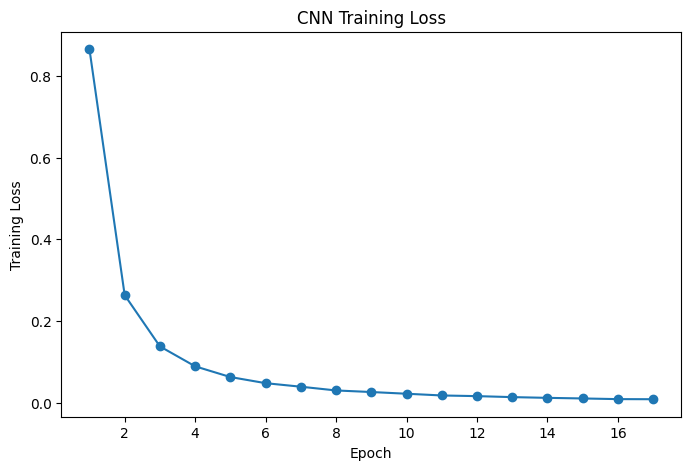

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.show()

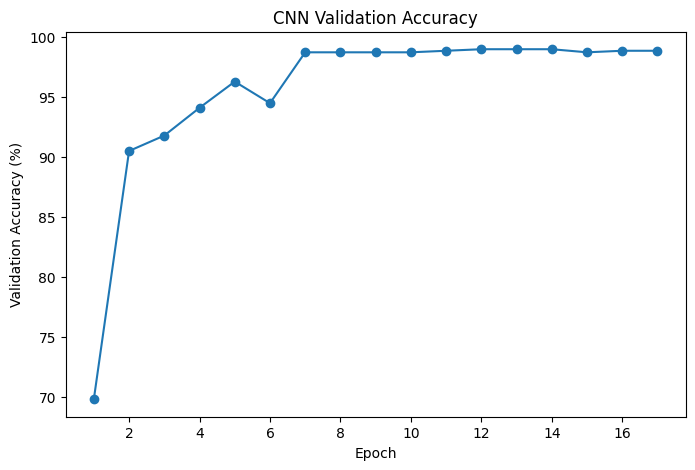

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(val_accuracies) + 1),
    np.array(val_accuracies) * 100,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("CNN Validation Accuracy")

plt.show()

In [93]:
model_final.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model_final.to(device)

print(
    "Best CNN model loaded from:",
    best_model_path
)

Best CNN model loaded from: C:\Users\vatsa\Parkinson_Project\results\cnn_1d_best_validation.pth


In [94]:
model_final.eval()

cnn_actual_final = []
cnn_predictions_final = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_final:

        X_batch = X_batch.to(device)

        outputs = model_final(
            X_batch
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        cnn_predictions_final.extend(
            predictions.cpu().numpy()
        )

        cnn_actual_final.extend(
            y_batch.numpy()
        )

cnn_actual_final = np.array(
    cnn_actual_final
)

cnn_predictions_final = np.array(
    cnn_predictions_final
)

In [95]:
from sklearn.metrics import accuracy_score

final_cnn_accuracy = accuracy_score(
    cnn_actual_final,
    cnn_predictions_final
)

print(
    f"FINAL CNN TEST ACCURACY: "
    f"{final_cnn_accuracy * 100:.2f}%"
)

FINAL CNN TEST ACCURACY: 74.69%


In [96]:
from sklearn.metrics import confusion_matrix

final_cnn_cm = confusion_matrix(
    cnn_actual_final,
    cnn_predictions_final
)

print(final_cnn_cm)

[[142   0   0   0   0]
 [  0 182   0   0   0]
 [  0   0 176   0  14]
 [ 93   0  97   0   0]
 [  0   0   0   0 102]]


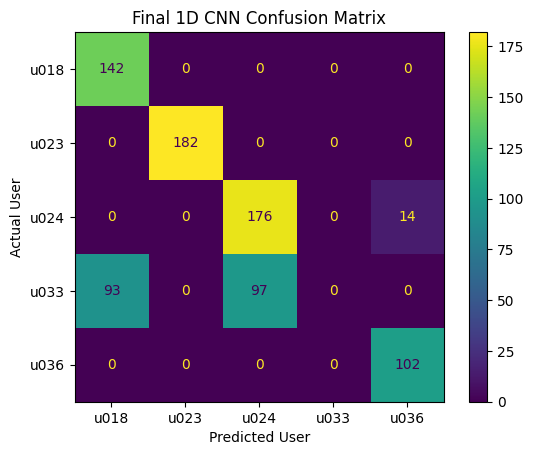

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cnn_cm,
    display_labels=label_encoder_final.classes_
)

disp.plot()

plt.title(
    "Final 1D CNN Confusion Matrix"
)

plt.xlabel("Predicted User")
plt.ylabel("Actual User")

plt.show()

In [98]:
from sklearn.metrics import classification_report

print(
    classification_report(
        cnn_actual_final,
        cnn_predictions_final,
        target_names=label_encoder_final.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u018       0.60      1.00      0.75       142
        u023       1.00      1.00      1.00       182
        u024       0.64      0.93      0.76       190
        u033       0.00      0.00      0.00       190
        u036       0.88      1.00      0.94       102

    accuracy                           0.75       806
   macro avg       0.63      0.79      0.69       806
weighted avg       0.60      0.75      0.66       806



In [99]:
final_cnn_cm_df = pd.DataFrame(
    final_cnn_cm,
    index=label_encoder_final.classes_,
    columns=label_encoder_final.classes_
)

final_cnn_cm_df.to_csv(
    results_path /
    "cnn_final_confusion_matrix.csv"
)

In [100]:
final_cnn_metrics = pd.DataFrame([{
    "Model": "1D CNN",
    "Input": "Raw 300x9 sensor windows",
    "Best_Epoch": best_epoch,
    "Validation_Accuracy": best_val_accuracy,
    "Final_Test_Accuracy": final_cnn_accuracy
}])

final_cnn_metrics.to_csv(
    results_path /
    "cnn_final_metrics.csv",
    index=False
)

print(final_cnn_metrics)

    Model                     Input  Best_Epoch  Validation_Accuracy  \
0  1D CNN  Raw 300x9 sensor windows          12             0.989717   

   Final_Test_Accuracy  
0             0.746898  


In [101]:
torch.save(
    model_final.state_dict(),
    results_path /
    "cnn_1d_final_model.pth"
)

print("Final CNN model saved.")

Final CNN model saved.


In [102]:
print("Training:")
print(pd.Series(y_train_raw_final).value_counts())

print("\nValidation:")
print(pd.Series(y_val_raw).value_counts())

print("\nTest:")
print(pd.Series(y_test_raw_final).value_counts())

Training:
u018    1902
u023    1490
u024     736
u033     561
u036     367
Name: count, dtype: int64

Validation:
u018    231
u023    201
u024    166
u033    102
u036     78
Name: count, dtype: int64

Test:
u024    190
u033    190
u023    182
u018    142
u036    102
Name: count, dtype: int64


In [103]:
print("Training:")
print(pd.Series(y_train_raw_final).value_counts())

print("\nValidation:")
print(pd.Series(y_val_raw).value_counts())

print("\nTest:")
print(pd.Series(y_test_raw_final).value_counts())

Training:
u018    1902
u023    1490
u024     736
u033     561
u036     367
Name: count, dtype: int64

Validation:
u018    231
u023    201
u024    166
u033    102
u036     78
Name: count, dtype: int64

Test:
u024    190
u033    190
u023    182
u018    142
u036    102
Name: count, dtype: int64


In [104]:
print("u033 training:")
print([
    r for r in new_train_recordings
    if r.startswith("u033_")
])

print("\nu033 validation:")
print([
    r for r in validation_recordings
    if r.startswith("u033_")
])

print("\nu033 test:")
print([
    r for r in test_recordings
    if r.startswith("u033_")
])

u033 training:
['u033_w001', 'u033_w002', 'u033_w003', 'u033_w004']

u033 validation:
['u033_w005']

u033 test:
['u033_w007']


In [105]:
u033_info = quality_report[
    quality_report["subject"] == "u033"
][
    [
        "recording",
        "accelerometer_duration_s",
        "gyroscope_duration_s",
        "magnetometer_duration_s",
        "status"
    ]
]

print(
    u033_info.to_string(index=False)
)

recording  accelerometer_duration_s  gyroscope_duration_s  magnetometer_duration_s            status
u033_w001                420.036318            419.448855               419.885745 TECHNICALLY VALID
u033_w002                155.107079            154.647668               155.101372 TECHNICALLY VALID
u033_w003                366.837334            366.368706               366.828697 TECHNICALLY VALID
u033_w004                480.440241            479.975000               480.415430 TECHNICALLY VALID
u033_w005                260.221118            259.753009               260.213000 TECHNICALLY VALID
u033_w006                478.699825            478.235867               478.700436   REVIEW REQUIRED
u033_w007                479.882022            479.410281               479.859348 TECHNICALLY VALID


In [106]:
def recording_statistics(recording_name):

    folder = data_path / recording_name

    acc = prepare_sensor(
        pd.read_csv(
            folder / f"{recording_name}_accelerometer.log",
            sep="\t"
        )
    )

    gyro = prepare_sensor(
        pd.read_csv(
            folder / f"{recording_name}_gyroscope.log",
            sep="\t"
        )
    )

    mag = prepare_sensor(
        pd.read_csv(
            folder / f"{recording_name}_magnetometer.log",
            sep="\t"
        )
    )

    result = {
        "recording": recording_name,

        "acc_mean": acc[["x","y","z"]].values.mean(),
        "acc_std": acc[["x","y","z"]].values.std(),

        "gyro_mean": gyro[["x","y","z"]].values.mean(),
        "gyro_std": gyro[["x","y","z"]].values.std(),

        "mag_mean": mag[["x","y","z"]].values.mean(),
        "mag_std": mag[["x","y","z"]].values.std(),
    }

    return result

In [107]:
u033_recordings = sorted(
    quality_report.loc[
        quality_report["subject"] == "u033",
        "recording"
    ].tolist()
)

u033_stats = pd.DataFrame(
    [
        recording_statistics(r)
        for r in u033_recordings
    ]
)

u033_stats

,recording,acc_mean,acc_std,gyro_mean,gyro_std,mag_mean,mag_std
0,u033_w001,3.600925,5.627079,0.000254,1.146850,-16.322486,24.099476
1,u033_w002,2.957903,6.128110,-0.020717,1.338394,2.342650,22.890923
2,u033_w003,2.898503,6.390296,-0.025668,1.430423,-9.851344,15.974263
3,u033_w004,3.169902,6.334771,0.013877,1.237769,-8.959046,28.472116
4,u033_w005,3.176240,6.255662,-0.034948,1.398355,1.621690,19.403879
5,u033_w006,4.035731,5.092010,0.003143,1.196528,-18.935038,16.515481
6,u033_w007,4.066230,4.950601,0.008324,1.147093,-19.396929,37.802558


In [108]:
print("u033 training:")
print([
    r for r in new_train_recordings
    if r.startswith("u033_")
])

print("\nu033 validation:")
print([
    r for r in validation_recordings
    if r.startswith("u033_")
])

print("\nu033 test:")
print([
    r for r in test_recordings
    if r.startswith("u033_")
])

u033 training:
['u033_w001', 'u033_w002', 'u033_w003', 'u033_w004']

u033 validation:
['u033_w005']

u033 test:
['u033_w007']


In [109]:
print(
    u033_info.to_string(index=False)
)

recording  accelerometer_duration_s  gyroscope_duration_s  magnetometer_duration_s            status
u033_w001                420.036318            419.448855               419.885745 TECHNICALLY VALID
u033_w002                155.107079            154.647668               155.101372 TECHNICALLY VALID
u033_w003                366.837334            366.368706               366.828697 TECHNICALLY VALID
u033_w004                480.440241            479.975000               480.415430 TECHNICALLY VALID
u033_w005                260.221118            259.753009               260.213000 TECHNICALLY VALID
u033_w006                478.699825            478.235867               478.700436   REVIEW REQUIRED
u033_w007                479.882022            479.410281               479.859348 TECHNICALLY VALID


In [110]:
u033_stats

,recording,acc_mean,acc_std,gyro_mean,gyro_std,mag_mean,mag_std
0,u033_w001,3.600925,5.627079,0.000254,1.146850,-16.322486,24.099476
1,u033_w002,2.957903,6.128110,-0.020717,1.338394,2.342650,22.890923
2,u033_w003,2.898503,6.390296,-0.025668,1.430423,-9.851344,15.974263
3,u033_w004,3.169902,6.334771,0.013877,1.237769,-8.959046,28.472116
4,u033_w005,3.176240,6.255662,-0.034948,1.398355,1.621690,19.403879
5,u033_w006,4.035731,5.092010,0.003143,1.196528,-18.935038,16.515481
6,u033_w007,4.066230,4.950601,0.008324,1.147093,-19.396929,37.802558


In [112]:
review = quality_report[
    quality_report["status"] == "REVIEW REQUIRED"
].copy()

print("Review recordings:", len(review))

Review recordings: 16


In [113]:
print("Training:")
print(pd.Series(y_train_raw_final).value_counts())

print("\nValidation:")
print(pd.Series(y_val_raw).value_counts())

print("\nTest:")
print(pd.Series(y_test_raw_final).value_counts())

Training:
u018    1902
u023    1490
u024     736
u033     561
u036     367
Name: count, dtype: int64

Validation:
u018    231
u023    201
u024    166
u033    102
u036     78
Name: count, dtype: int64

Test:
u024    190
u033    190
u023    182
u018    142
u036    102
Name: count, dtype: int64


In [114]:
review[
    review["recording"] == "u033_w006"
]

,recording,subject,accelerometer_exists,accelerometer_samples,accelerometer_missing,accelerometer_duplicates,accelerometer_timestamp_ok,accelerometer_duration_s,accelerometer_rate_hz,accelerometer_constant,...,magnetometer_samples,magnetometer_missing,magnetometer_duplicates,magnetometer_timestamp_ok,magnetometer_duration_s,magnetometer_rate_hz,magnetometer_constant,magnetometer_error,status,duration_difference_s
99,u033_w006,u033,True,57189,0,0,False,478.699825,119.156363,False,...,28595,0,0,False,478.700436,56.888889,False,NaN,REVIEW REQUIRED,0.464569


In [115]:
u033_recordings = sorted(
    quality_report.loc[
        quality_report["subject"] == "u033",
        "recording"
    ].tolist()
)

u033_stats = pd.DataFrame(
    [
        recording_statistics(r)
        for r in u033_recordings
    ]
)

print(u033_stats)

   recording  acc_mean   acc_std  gyro_mean  gyro_std   mag_mean    mag_std
0  u033_w001  3.600925  5.627079   0.000254  1.146850 -16.322486  24.099476
1  u033_w002  2.957903  6.128110  -0.020717  1.338394   2.342650  22.890923
2  u033_w003  2.898503  6.390296  -0.025668  1.430423  -9.851344  15.974263
3  u033_w004  3.169902  6.334771   0.013877  1.237769  -8.959046  28.472116
4  u033_w005  3.176240  6.255662  -0.034948  1.398355   1.621690  19.403879
5  u033_w006  4.035731  5.092010   0.003143  1.196528 -18.935038  16.515481
6  u033_w007  4.066230  4.950601   0.008324  1.147093 -19.396929  37.802558


In [116]:
review[
    review["recording"] == "u033_w006"
]

,recording,subject,accelerometer_exists,accelerometer_samples,accelerometer_missing,accelerometer_duplicates,accelerometer_timestamp_ok,accelerometer_duration_s,accelerometer_rate_hz,accelerometer_constant,...,magnetometer_samples,magnetometer_missing,magnetometer_duplicates,magnetometer_timestamp_ok,magnetometer_duration_s,magnetometer_rate_hz,magnetometer_constant,magnetometer_error,status,duration_difference_s
99,u033_w006,u033,True,57189,0,0,False,478.699825,119.156363,False,...,28595,0,0,False,478.700436,56.888889,False,NaN,REVIEW REQUIRED,0.464569


In [117]:
recording_name = "u033_w006"
folder = data_path / recording_name

acc_raw = pd.read_csv(
    folder / f"{recording_name}_accelerometer.log",
    sep="\t"
)

gyro_raw = pd.read_csv(
    folder / f"{recording_name}_gyroscope.log",
    sep="\t"
)

mag_raw = pd.read_csv(
    folder / f"{recording_name}_magnetometer.log",
    sep="\t"
)

In [118]:
for name, df in [
    ("Accelerometer", acc_raw),
    ("Gyroscope", gyro_raw),
    ("Magnetometer", mag_raw)
]:

    timestamp = pd.to_numeric(
        df.iloc[:, 0],
        errors="coerce"
    )

    diff = timestamp.diff()

    print("\n", name)

    print(
        "Negative differences:",
        (diff < 0).sum()
    )

    print(
        "Zero differences:",
        (diff == 0).sum()
    )

    print(
        "Smallest difference:",
        diff.min()
    )

    print(
        "Median difference:",
        diff.median()
    )


 Accelerometer
Negative differences: 2
Zero differences: 0
Smallest difference: -1123944907.0
Median difference: 8392334.0

 Gyroscope
Negative differences: 2
Zero differences: 0
Smallest difference: -1127912192.0
Median difference: 5035400.0

 Magnetometer
Negative differences: 2
Zero differences: 0
Smallest difference: -1116712241.0
Median difference: 17578125.0


In [119]:
for name, df in [
    ("Accelerometer", acc_raw),
    ("Gyroscope", gyro_raw),
    ("Magnetometer", mag_raw)
]:

    timestamp = pd.to_numeric(
        df.iloc[:, 0],
        errors="coerce"
    )

    diff = timestamp.diff()

    problem_indices = diff[diff <= 0].index

    print("\n" + "=" * 50)
    print(name)
    print("Problem count:", len(problem_indices))

    if len(problem_indices) > 0:

        for idx in problem_indices[:10]:

            start = max(0, idx - 2)
            end = min(len(df), idx + 3)

            print(
                df.iloc[start:end]
            )


Accelerometer
Problem count: 2
       accelerometer_timestamp  accelerometer_x_data  accelerometer_y_data  \
32473      1443644726600398819              0.636597              4.989990   
32474      1443644726608791153              0.752686              5.596283   
32475      1443644725484846246              0.800751              6.770630   
32476      1443644725493238580              1.027725              8.762924   
32477      1443644725501630914              1.834549             11.639725   

       accelerometer_z_data  
32473              3.773453  
32474              4.409073  
32475              5.308350  
32476              6.310837  
32477              7.716568  
       accelerometer_timestamp  accelerometer_x_data  accelerometer_y_data  \
39027      1443644780471393915             -0.951889              4.303818   
39028      1443644780479786249             -0.857300              3.999481   
39029      1443644780302964613             -0.886612              3.775558   
39030  

In [120]:
for name, df in [
    ("Accelerometer", acc_raw),
    ("Gyroscope", gyro_raw),
    ("Magnetometer", mag_raw)
]:

    timestamp = pd.to_numeric(
        df.iloc[:, 0],
        errors="coerce"
    )

    diff = timestamp.diff()

    print(
        name,
        "| negative:",
        (diff < 0).sum(),
        "| zero:",
        (diff == 0).sum(),
        "| min:",
        diff.min(),
        "| median:",
        diff.median()
    )

Accelerometer | negative: 2 | zero: 0 | min: -1123944907.0 | median: 8392334.0
Gyroscope | negative: 2 | zero: 0 | min: -1127912192.0 | median: 5035400.0
Magnetometer | negative: 2 | zero: 0 | min: -1116712241.0 | median: 17578125.0


In [121]:
for name, df in [
    ("Accelerometer", acc_raw),
    ("Gyroscope", gyro_raw),
    ("Magnetometer", mag_raw)
]:

    timestamp = pd.to_numeric(
        df.iloc[:, 0],
        errors="coerce"
    )

    diff = timestamp.diff()

    negative = diff[diff < 0]

    print("\n" + "=" * 50)
    print(name)

    for idx, value in negative.items():

        print(
            "Index:",
            idx,
            "| Jump:",
            value / 1e9,
            "seconds"
        )


Accelerometer
Index: 32475 | Jump: -1.123944907 seconds
Index: 39029 | Jump: -0.176821636 seconds

Gyroscope
Index: 53841 | Jump: -1.127912192 seconds
Index: 64725 | Jump: -0.180483745 seconds

Magnetometer
Index: 16238 | Jump: -1.116712241 seconds
Index: 19515 | Jump: -0.16568272 seconds


In [122]:
def inspect_timestamp_jumps(df, sensor_name):

    timestamp = pd.to_numeric(
        df.iloc[:, 0],
        errors="coerce"
    )

    diff = timestamp.diff()

    problem_indices = diff[diff < 0].index

    print("\n" + "=" * 60)
    print(sensor_name)

    for idx in problem_indices:

        start = max(0, idx - 2)
        end = min(len(df), idx + 3)

        print(
            f"\nProblem around index {idx}:"
        )

        print(
            df.iloc[start:end].to_string(
                index=True
            )
        )

In [123]:
inspect_timestamp_jumps(
    acc_raw,
    "Accelerometer"
)

inspect_timestamp_jumps(
    gyro_raw,
    "Gyroscope"
)

inspect_timestamp_jumps(
    mag_raw,
    "Magnetometer"
)


Accelerometer

Problem around index 32475:
       accelerometer_timestamp  accelerometer_x_data  accelerometer_y_data  accelerometer_z_data
32473      1443644726600398819              0.636597              4.989990              3.773453
32474      1443644726608791153              0.752686              5.596283              4.409073
32475      1443644725484846246              0.800751              6.770630              5.308350
32476      1443644725493238580              1.027725              8.762924              6.310837
32477      1443644725501630914              1.834549             11.639725              7.716568

Problem around index 39029:
       accelerometer_timestamp  accelerometer_x_data  accelerometer_y_data  accelerometer_z_data
39027      1443644780471393915             -0.951889              4.303818              2.263870
39028      1443644780479786249             -0.857300              3.999481              2.637100
39029      1443644780302964613             -0.886612  

In [124]:
for name, df in [
    ("Accelerometer", acc_raw),
    ("Gyroscope", gyro_raw),
    ("Magnetometer", mag_raw)
]:

    timestamp = pd.to_numeric(
        df.iloc[:, 0],
        errors="coerce"
    )

    diff = timestamp.diff()

    negative = diff[diff < 0]

    print("\n", name)

    for idx, value in negative.items():

        print(
            "Index:", idx,
            "| Jump:", value / 1e9,
            "seconds"
        )


 Accelerometer
Index: 32475 | Jump: -1.123944907 seconds
Index: 39029 | Jump: -0.176821636 seconds

 Gyroscope
Index: 53841 | Jump: -1.127912192 seconds
Index: 64725 | Jump: -0.180483745 seconds

 Magnetometer
Index: 16238 | Jump: -1.116712241 seconds
Index: 19515 | Jump: -0.16568272 seconds


In [125]:
from pathlib import Path

results_path = Path(
    r"C:\Users\vatsa\Parkinson_Project\results"
)

results_path.mkdir(
    parents=True,
    exist_ok=True
)

u033_stats.to_csv(
    results_path / "u033_session_statistics.csv",
    index=False
)

print(
    "Saved:",
    results_path / "u033_session_statistics.csv"
)

Saved: C:\Users\vatsa\Parkinson_Project\results\u033_session_statistics.csv


In [126]:
diagnostic_text = f"""
U033 TIMESTAMP DIAGNOSTIC
=========================

Recording:
u033_w006

Status:
REVIEW REQUIRED

Reason:
Non-monotonic timestamps detected in accelerometer,
gyroscope and magnetometer streams.

Accelerometer
-------------
Negative timestamp jumps: 2
Jump 1: -1.123944907 seconds
Jump 2: -0.176821636 seconds

Gyroscope
---------
Negative timestamp jumps: 2
Jump 1: -1.127912192 seconds
Jump 2: -0.180483745 seconds

Magnetometer
------------
Negative timestamp jumps: 2
Jump 1: -1.116712241 seconds
Jump 2: -0.165682720 seconds

Other observations
------------------
Missing values: 0
Duplicate timestamps: 0
Sensor measurements remain numerically present.
Recording duration is approximately 478.7 seconds.

Interpretation
--------------
The recording contains timestamp ordering irregularities
that affect all three main sensor streams at approximately
the same points. The recording is therefore flagged for
review rather than automatically deleted.
"""

diagnostic_path = (
    results_path /
    "u033_w006_timestamp_diagnostic.txt"
)

with open(
    diagnostic_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(diagnostic_text)

print(
    "Saved:",
    diagnostic_path
)

Saved: C:\Users\vatsa\Parkinson_Project\results\u033_w006_timestamp_diagnostic.txt


In [127]:
model_summary = pd.DataFrame([
    {
        "Model": "Random Forest - 63 features",
        "Accuracy": 67.97
    },
    {
        "Model": "Random Forest - 90 features",
        "Accuracy": 74.18
    },
    {
        "Model": "SVM - 90 features",
        "Accuracy": 74.79
    },
    {
        "Model": "1D CNN - Development",
        "Accuracy": 75.93
    },
    {
        "Model": "1D CNN - Proper validation/test",
        "Accuracy": 74.69
    }
])

model_summary.to_csv(
    results_path / "model_results_summary.csv",
    index=False
)

print(
    "Saved:",
    results_path / "model_results_summary.csv"
)

Saved: C:\Users\vatsa\Parkinson_Project\results\model_results_summary.csv


In [128]:
print("Files currently in results folder:\n")

for file in sorted(results_path.iterdir()):
    print(file.name)

Files currently in results folder:

cnn_1d_best_validation.pth
cnn_1d_final_model.pth
cnn_1d_model.pth
cnn_confusion_matrix.csv
cnn_final_confusion_matrix.csv
cnn_final_metrics.csv
cnn_metrics.csv
model_results_summary.csv
random_forest_confusion_matrix.csv
random_forest_confusion_matrix.png
random_forest_model.pkl
svm_confusion_matrix.csv
svm_confusion_matrix.png
svm_model.pkl
u033_session_statistics.csv
u033_w006_timestamp_diagnostic.txt


In [129]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison_final = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Input": "90 handcrafted features",
        "Accuracy (%)": accuracy_score(
            y_test_v2,
            y_pred_v2
        ) * 100,
        "Precision (%)": precision_score(
            y_test_v2,
            y_pred_v2,
            average="macro",
            zero_division=0
        ) * 100,
        "Recall (%)": recall_score(
            y_test_v2,
            y_pred_v2,
            average="macro",
            zero_division=0
        ) * 100,
        "F1 (%)": f1_score(
            y_test_v2,
            y_pred_v2,
            average="macro",
            zero_division=0
        ) * 100
    },
    {
        "Model": "SVM",
        "Input": "90 handcrafted features",
        "Accuracy (%)": accuracy_score(
            y_test_v2,
            y_pred_svm
        ) * 100,
        "Precision (%)": precision_score(
            y_test_v2,
            y_pred_svm,
            average="macro",
            zero_division=0
        ) * 100,
        "Recall (%)": recall_score(
            y_test_v2,
            y_pred_svm,
            average="macro",
            zero_division=0
        ) * 100,
        "F1 (%)": f1_score(
            y_test_v2,
            y_pred_svm,
            average="macro",
            zero_division=0
        ) * 100
    },
    {
        "Model": "1D CNN",
        "Input": "Raw 300×9 windows",
        "Accuracy (%)": accuracy_score(
            cnn_actual_final,
            cnn_predictions_final
        ) * 100,
        "Precision (%)": precision_score(
            cnn_actual_final,
            cnn_predictions_final,
            average="macro",
            zero_division=0
        ) * 100,
        "Recall (%)": recall_score(
            cnn_actual_final,
            cnn_predictions_final,
            average="macro",
            zero_division=0
        ) * 100,
        "F1 (%)": f1_score(
            cnn_actual_final,
            cnn_predictions_final,
            average="macro",
            zero_division=0
        ) * 100
    }
])

comparison_final

NameError: name 'y_test_v2' is not defined

In [130]:
import pandas as pd
from pathlib import Path

results_path = Path(
    r"C:\Users\vatsa\Parkinson_Project\results"
)

comparison_final = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.18
    },
    {
        "Model": "SVM",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.79
    },
    {
        "Model": "1D CNN",
        "Input": "Raw 300×9 windows",
        "Accuracy (%)": 74.69
    }
])

print(comparison_final)

           Model                    Input  Accuracy (%)
0  Random Forest  90 handcrafted features         74.18
1            SVM  90 handcrafted features         74.79
2         1D CNN        Raw 300×9 windows         74.69


In [131]:
comparison_final.to_csv(
    results_path / "final_model_comparison.csv",
    index=False
)

print(
    "Saved:",
    results_path / "final_model_comparison.csv"
)

Saved: C:\Users\vatsa\Parkinson_Project\results\final_model_comparison.csv


In [133]:
import pandas as pd

model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.18
    },
    {
        "Model": "SVM",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.79
    },
    {
        "Model": "1D CNN",
        "Input": "Raw 300x9 sensor windows",
        "Accuracy (%)": 74.69
    }
])

print(model_comparison)

           Model                     Input  Accuracy (%)
0  Random Forest   90 handcrafted features         74.18
1            SVM   90 handcrafted features         74.79
2         1D CNN  Raw 300x9 sensor windows         74.69


In [134]:
model_comparison.to_csv(
    results_path / "all_model_comparison.csv",
    index=False
)

print("Comparison saved.")

Comparison saved.


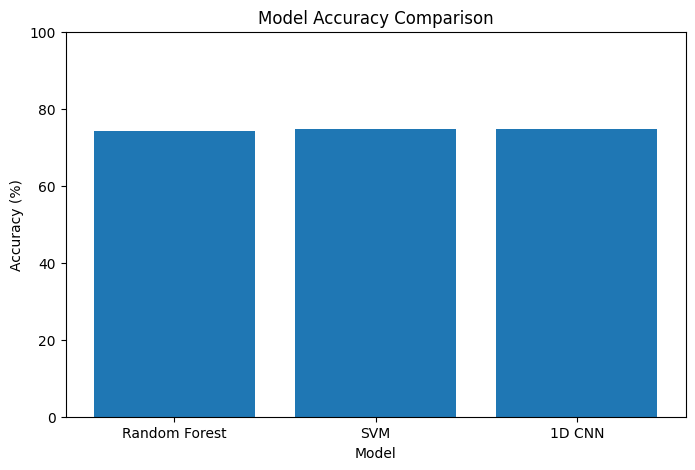

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)

plt.show()

In [137]:
import numpy as np
import pandas as pd

# Class order used in our experiments
selected_users = ['u018', 'u023', 'u024', 'u033', 'u036']

# Random Forest - 90 features
cm_v2 = np.array([
    [178,   0,   0,   0,   0],
    [  0, 149,   0,   0,   0],
    [  0,   0, 179,   5,   7],
    [  0, 200,   0,   0,   0],
    [  0,   0,   0,   0, 103]
])

# SVM - 90 features
cm_svm = np.array([
    [178,   0,   0,   0,   0],
    [  0, 149,   0,   0,   0],
    [  0,   0, 184,   4,   3],
    [  0,  10, 190,   0,   0],
    [  0,   0,   0,   0, 103]
])

# 1D CNN - proper final test
final_cnn_cm = np.array([
    [142,   0,   0,   0,   0],
    [  0, 182,   0,   0,   0],
    [  0,   0, 176,   0,  14],
    [ 93,   0,  97,   0,   0],
    [  0,   0,   0,   0, 102]
])

print("Matrices recreated successfully.")

Matrices recreated successfully.


In [138]:
cm_v2_df = pd.DataFrame(
    cm_v2,
    index=selected_users,
    columns=selected_users
)

cm_svm_df = pd.DataFrame(
    cm_svm,
    index=selected_users,
    columns=selected_users
)

final_cnn_cm_df = pd.DataFrame(
    final_cnn_cm,
    index=selected_users,
    columns=selected_users
)

cm_v2_df.to_csv(
    results_path / "random_forest_90_confusion_matrix.csv"
)

cm_svm_df.to_csv(
    results_path / "svm_confusion_matrix.csv"
)

final_cnn_cm_df.to_csv(
    results_path / "cnn_final_confusion_matrix.csv"
)

print("All three confusion matrices saved.")

All three confusion matrices saved.


In [139]:
for file in [
    "random_forest_90_confusion_matrix.csv",
    "svm_confusion_matrix.csv",
    "cnn_final_confusion_matrix.csv"
]:
    print(
        file,
        "→",
        (results_path / file).exists()
    )

random_forest_90_confusion_matrix.csv → True
svm_confusion_matrix.csv → True
cnn_final_confusion_matrix.csv → True


In [140]:
import pandas as pd

model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.18
    },
    {
        "Model": "SVM",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.79
    },
    {
        "Model": "1D CNN",
        "Input": "Raw 300x9 sensor windows",
        "Accuracy (%)": 74.69
    }
])

print(model_comparison)

           Model                     Input  Accuracy (%)
0  Random Forest   90 handcrafted features         74.18
1            SVM   90 handcrafted features         74.79
2         1D CNN  Raw 300x9 sensor windows         74.69


In [141]:
model_comparison.to_csv(
    results_path / "all_model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


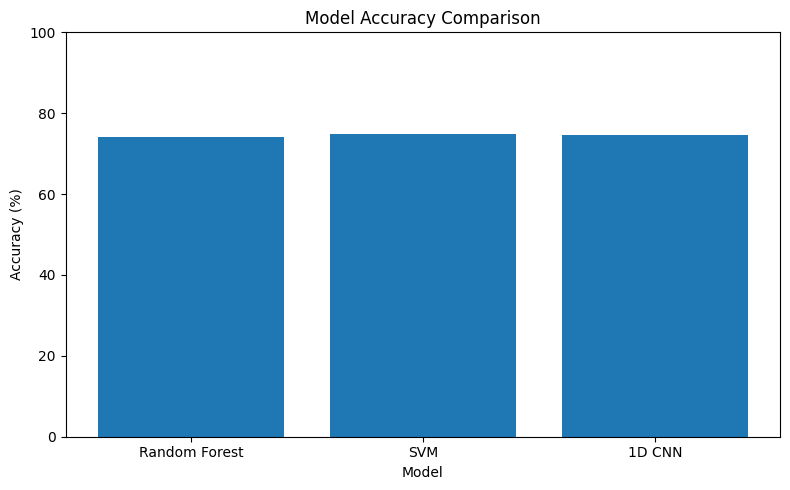

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [143]:
selected_users = [
    "u018",
    "u023",
    "u024",
    "u033",
    "u036"
]

In [144]:
rf_cm_df = pd.DataFrame(
    cm_v2,
    index=selected_users,
    columns=selected_users
)

svm_cm_df = pd.DataFrame(
    cm_svm,
    index=selected_users,
    columns=selected_users
)

cnn_cm_df = pd.DataFrame(
    final_cnn_cm,
    index=selected_users,
    columns=selected_users
)

In [145]:
rf_cm_df.to_csv(
    results_path / "random_forest_90_confusion_matrix.csv"
)

svm_cm_df.to_csv(
    results_path / "svm_confusion_matrix.csv"
)

cnn_cm_df.to_csv(
    results_path / "cnn_final_confusion_matrix.csv"
)

print("All confusion matrices saved.")

All confusion matrices saved.


In [146]:
rf_normalized = rf_cm_df.div(
    rf_cm_df.sum(axis=1),
    axis=0
)

svm_normalized = svm_cm_df.div(
    svm_cm_df.sum(axis=1),
    axis=0
)

cnn_normalized = cnn_cm_df.div(
    cnn_cm_df.sum(axis=1),
    axis=0
)

In [147]:
rf_normalized.to_csv(
    results_path / "random_forest_normalized_confusion.csv"
)

svm_normalized.to_csv(
    results_path / "svm_normalized_confusion.csv"
)

cnn_normalized.to_csv(
    results_path / "cnn_normalized_confusion.csv"
)

In [148]:
summary = """
SAMPLE DATASET MODEL COMPARISON
================================

Dataset:
IDNet sensor dataset used for pipeline validation.

Task:
User-identification classification using sensor recordings.

Models:
1. Random Forest using 90 handcrafted features
2. SVM using 90 handcrafted features
3. 1D CNN using raw 300x9 sensor windows

Results:
Random Forest: 74.18%
SVM: 74.79%
1D CNN: 74.69%

Best proper test result:
SVM - 74.79%

Important observation:
The three models produced similar performance.
The 1D CNN did not show a major advantage over the
traditional ML models in this sample experiment.

The CNN validation accuracy was much higher than its
final test accuracy, showing that session-to-session
generalization is an important issue.

Main difficult class:
u033 was poorly recognized by all models and was
frequently confused with other users.

Purpose:
This experiment validates the sensor-processing,
feature-extraction, model-training and confusion-matrix
pipeline before applying the same methodology to a
properly labelled Parkinson's disease dataset.
"""

with open(
    results_path / "sample_experiment_conclusion.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(summary)

print("Conclusion saved.")

Conclusion saved.


In [150]:
from pathlib import Path

parkinson_path = Path(
    r"C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset"
)

print("Dataset exists:", parkinson_path.exists())

print("\nContents:")
for item in sorted(parkinson_path.iterdir()):
    print(
        "DIR " if item.is_dir() else "FILE",
        item.name
    )

Dataset exists: True

Contents:
DIR  u001_w001
DIR  u001_w002
DIR  u001_w003
DIR  u002_w001
DIR  u002_w002
DIR  u002_w003
DIR  u002_w004
DIR  u003_w001
DIR  u003_w002
DIR  u004_w001
DIR  u004_w002
DIR  u005_w001
DIR  u006_w001
DIR  u007_w001
DIR  u007_w002
DIR  u008_w001
DIR  u009_w001
DIR  u010_w001
DIR  u010_w002
DIR  u010_w003
DIR  u010_w004
DIR  u011_w001
DIR  u012_w001
DIR  u012_w002
DIR  u013_w001
DIR  u014_w001
DIR  u014_w002
DIR  u015_w001
DIR  u016_w001
DIR  u016_w002
DIR  u017_w001
DIR  u018_w001
DIR  u018_w002
DIR  u018_w003
DIR  u018_w004
DIR  u018_w005
DIR  u018_w006
DIR  u018_w007
DIR  u018_w008
DIR  u018_w009
DIR  u018_w010
DIR  u018_w011
DIR  u018_w012
DIR  u018_w013
DIR  u018_w014
DIR  u019_w001
DIR  u019_w002
DIR  u020_w001
DIR  u020_w002
DIR  u021_w001
DIR  u021_w002
DIR  u021_w003
DIR  u022_w001
DIR  u023_w001
DIR  u023_w002
DIR  u023_w003
DIR  u023_w004
DIR  u023_w005
DIR  u023_w006
DIR  u023_w007
DIR  u023_w008
DIR  u023_w009
DIR  u023_w010
DIR  u023_w011
DIR  u02

In [151]:
possible_files = []

for path in parkinson_path.rglob("*"):
    if path.is_file():
        possible_files.append(path)

print("Total files:", len(possible_files))

for path in possible_files:
    print(path)

Total files: 810
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_accelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_gravity.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_gyroscope.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_linearaccelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_magnetometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_rotvec.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_accelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_gravity.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_gyroscope.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_linearaccelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_magnetometer.log

In [152]:
print("Dataset exists:", parkinson_path.exists())

for item in sorted(parkinson_path.iterdir()):
    print(item)

Dataset exists: True
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w003
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w003
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u002_w004
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u003_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u003_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u004_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u004_w002
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u005_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u006_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u007_w001
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u007_w002
C:\Users\vatsa\Downloads\IDNet_dat

In [153]:
for path in parkinson_path.rglob("*"):
    if path.is_file():
        print(path)

C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_accelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_gravity.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_gyroscope.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_linearaccelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_magnetometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w001\u001_w001_rotvec.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_accelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_gravity.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_gyroscope.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_linearaccelerometer.log
C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset\u001_w002\u001_w002_magnetometer.log
C:\Users\vatsa\D

In [154]:
import torch
import torch.nn as nn


class CNNLSTM(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # CNN extracts local temporal patterns
        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_channels=9,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            ),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            )
        )

        # LSTM learns longer temporal relationships
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # Final classifier
        self.classifier = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        # Input:
        # (batch, 9, 300)

        x = self.cnn(x)

        # After CNN:
        # (batch, 64, 150)

        # LSTM requires:
        # (batch, time, features)

        x = x.permute(
            0, 2, 1
        )

        # (batch, 150, 64)

        x, _ = self.lstm(x)

        # Use the final time step
        x = x[:, -1, :]

        x = self.classifier(x)

        return x

In [155]:
num_classes = len(
    label_encoder_final.classes_
)

cnn_lstm_model = CNNLSTM(
    num_classes=num_classes
).to(device)

print(cnn_lstm_model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)


In [156]:
X_batch, y_batch = next(
    iter(train_loader_final)
)

X_batch = X_batch.to(device)

with torch.no_grad():

    output = cnn_lstm_model(
        X_batch
    )

print("Input shape:", X_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 9, 300])
Output shape: torch.Size([64, 5])


In [157]:
criterion_lstm = nn.CrossEntropyLoss()

optimizer_lstm = torch.optim.Adam(
    cnn_lstm_model.parameters(),
    lr=0.001
)

In [158]:
num_epochs = 30
patience = 5

best_val_accuracy_lstm = 0.0
best_epoch_lstm = 0
epochs_without_improvement = 0

train_losses_lstm = []
val_accuracies_lstm = []

best_lstm_path = (
    results_path /
    "cnn_lstm_best_validation.pth"
)

for epoch in range(num_epochs):

    cnn_lstm_model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader_final:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_lstm.zero_grad()

        outputs = cnn_lstm_model(
            X_batch
        )

        loss = criterion_lstm(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer_lstm.step()

        running_loss += loss.item()

    average_loss = (
        running_loss /
        len(train_loader_final)
    )

    val_accuracy = evaluate_accuracy(
        cnn_lstm_model,
        val_loader,
        device
    )

    train_losses_lstm.append(
        average_loss
    )

    val_accuracies_lstm.append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )

    if val_accuracy > best_val_accuracy_lstm:

        best_val_accuracy_lstm = val_accuracy
        best_epoch_lstm = epoch + 1
        epochs_without_improvement = 0

        torch.save(
            cnn_lstm_model.state_dict(),
            best_lstm_path
        )

        print(
            f"  ✓ Best model saved "
            f"(epoch {best_epoch_lstm})"
        )

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}"
        )

        break

print("\nTraining complete.")
print(
    f"Best epoch: {best_epoch_lstm}"
)
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy_lstm * 100:.2f}%"
)

Epoch 01/30 | Loss: 0.6241 | Validation Accuracy: 86.63%
  ✓ Best model saved (epoch 1)
Epoch 02/30 | Loss: 0.1559 | Validation Accuracy: 95.76%
  ✓ Best model saved (epoch 2)
Epoch 03/30 | Loss: 0.1683 | Validation Accuracy: 71.08%
Epoch 04/30 | Loss: 0.1474 | Validation Accuracy: 97.17%
  ✓ Best model saved (epoch 4)
Epoch 05/30 | Loss: 0.0711 | Validation Accuracy: 92.16%
Epoch 06/30 | Loss: 0.0544 | Validation Accuracy: 97.94%
  ✓ Best model saved (epoch 6)
Epoch 07/30 | Loss: 0.0696 | Validation Accuracy: 97.94%
Epoch 08/30 | Loss: 0.0513 | Validation Accuracy: 98.07%
  ✓ Best model saved (epoch 8)
Epoch 09/30 | Loss: 0.0194 | Validation Accuracy: 98.59%
  ✓ Best model saved (epoch 9)
Epoch 10/30 | Loss: 0.0191 | Validation Accuracy: 98.59%
Epoch 11/30 | Loss: 0.0479 | Validation Accuracy: 94.22%
Epoch 12/30 | Loss: 0.0400 | Validation Accuracy: 98.71%
  ✓ Best model saved (epoch 12)
Epoch 13/30 | Loss: 0.0578 | Validation Accuracy: 96.79%
Epoch 14/30 | Loss: 0.0327 | Validation A

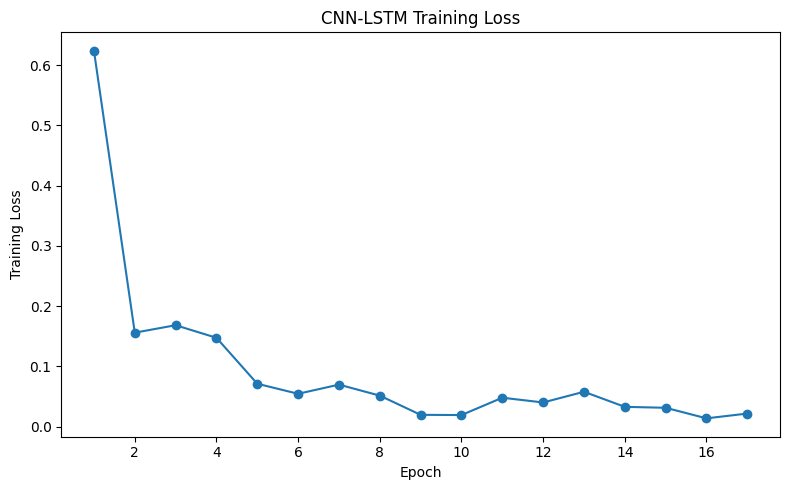

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses_lstm) + 1),
    train_losses_lstm,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN-LSTM Training Loss")

plt.tight_layout()
plt.show()

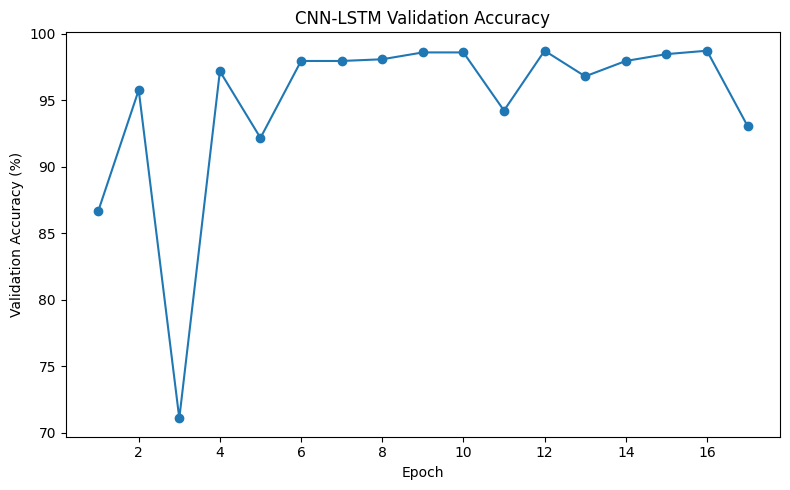

In [161]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(val_accuracies_lstm) + 1),
    np.array(val_accuracies_lstm) * 100,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("CNN-LSTM Validation Accuracy")

plt.tight_layout()
plt.show()

In [162]:
cnn_lstm_model.load_state_dict(
    torch.load(
        best_lstm_path,
        map_location=device
    )
)

cnn_lstm_model.to(device)

print(
    "Best CNN-LSTM model loaded."
)

Best CNN-LSTM model loaded.


In [163]:
cnn_lstm_model.eval()

lstm_actual = []
lstm_predictions = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_final:

        X_batch = X_batch.to(device)

        outputs = cnn_lstm_model(
            X_batch
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        lstm_predictions.extend(
            predictions.cpu().numpy()
        )

        lstm_actual.extend(
            y_batch.numpy()
        )

lstm_actual = np.array(
    lstm_actual
)

lstm_predictions = np.array(
    lstm_predictions
)

In [164]:
cnn_lstm_accuracy = accuracy_score(
    lstm_actual,
    lstm_predictions
)

print(
    f"CNN-LSTM Test Accuracy: "
    f"{cnn_lstm_accuracy * 100:.2f}%"
)

CNN-LSTM Test Accuracy: 53.35%


In [165]:
cnn_lstm_cm = confusion_matrix(
    lstm_actual,
    lstm_predictions
)

print(cnn_lstm_cm)

[[142   0   0   0   0]
 [  0 174   0   8   0]
 [  9   0  12 168   1]
 [139   0  51   0   0]
 [  0   0   0   0 102]]


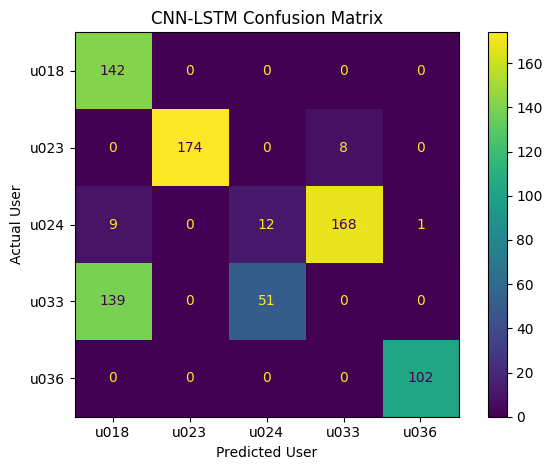

In [166]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_lstm_cm,
    display_labels=label_encoder_final.classes_
)

disp.plot()

plt.title(
    "CNN-LSTM Confusion Matrix"
)

plt.xlabel("Predicted User")
plt.ylabel("Actual User")

plt.tight_layout()
plt.show()

In [167]:
print(
    classification_report(
        lstm_actual,
        lstm_predictions,
        target_names=label_encoder_final.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        u018       0.49      1.00      0.66       142
        u023       1.00      0.96      0.98       182
        u024       0.19      0.06      0.09       190
        u033       0.00      0.00      0.00       190
        u036       0.99      1.00      1.00       102

    accuracy                           0.53       806
   macro avg       0.53      0.60      0.54       806
weighted avg       0.48      0.53      0.48       806



In [168]:
torch.save(
    cnn_lstm_model.state_dict(),
    results_path /
    "cnn_lstm_final_model.pth"
)

In [169]:
cnn_lstm_cm_df = pd.DataFrame(
    cnn_lstm_cm,
    index=label_encoder_final.classes_,
    columns=label_encoder_final.classes_
)

cnn_lstm_cm_df.to_csv(
    results_path /
    "cnn_lstm_confusion_matrix.csv"
)

In [170]:
cnn_lstm_metrics = pd.DataFrame([{
    "Model": "CNN-LSTM",
    "Input": "Raw 300x9 sensor windows",
    "Best_Epoch": best_epoch_lstm,
    "Validation_Accuracy": best_val_accuracy_lstm,
    "Test_Accuracy": cnn_lstm_accuracy
}])

cnn_lstm_metrics.to_csv(
    results_path /
    "cnn_lstm_metrics.csv",
    index=False
)

print(cnn_lstm_metrics)

      Model                     Input  Best_Epoch  Validation_Accuracy  \
0  CNN-LSTM  Raw 300x9 sensor windows          12             0.987147   

   Test_Accuracy  
0       0.533499  


In [171]:
model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.18
    },
    {
        "Model": "SVM",
        "Input": "90 handcrafted features",
        "Accuracy (%)": 74.79
    },
    {
        "Model": "1D CNN",
        "Input": "Raw 300x9 sensor windows",
        "Accuracy (%)": 74.69
    },
    {
        "Model": "CNN-LSTM",
        "Input": "Raw 300x9 sensor windows",
        "Accuracy (%)": cnn_lstm_accuracy * 100
    }
])

print(model_comparison)

           Model                     Input  Accuracy (%)
0  Random Forest   90 handcrafted features     74.180000
1            SVM   90 handcrafted features     74.790000
2         1D CNN  Raw 300x9 sensor windows     74.690000
3       CNN-LSTM  Raw 300x9 sensor windows     53.349876


In [172]:
cnn_lstm_cm_df = pd.DataFrame(
    cnn_lstm_cm,
    index=label_encoder_final.classes_,
    columns=label_encoder_final.classes_
)

cnn_lstm_cm_df.to_csv(
    results_path / "cnn_lstm_confusion_matrix.csv"
)

cnn_lstm_metrics.to_csv(
    results_path / "cnn_lstm_metrics.csv",
    index=False
)

torch.save(
    cnn_lstm_model.state_dict(),
    results_path / "cnn_lstm_final_model.pth"
)

print("CNN-LSTM results saved.")

CNN-LSTM results saved.


In [1]:
print("Notebook opened successfully")

Notebook opened successfully


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
project_path = Path(
    r"C:\Users\vatsa\Parkinson_Project"
)

data_path = Path(
    r"C:\Users\vatsa\Downloads\IDNet_dataset\IDNet_dataset"
)

processed_path = project_path / "processed"
results_path = project_path / "results"

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

results_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Project path:", project_path)
print("Dataset exists:", data_path.exists())
print("Results path:", results_path)

Project path: C:\Users\vatsa\Parkinson_Project
Dataset exists: True
Results path: C:\Users\vatsa\Parkinson_Project\results


In [3]:
train_features_path = (
    processed_path / "train_features_90.csv"
)

test_features_path = (
    processed_path / "test_features_90.csv"
)

print(
    "Train file exists:",
    train_features_path.exists()
)

print(
    "Test file exists:",
    test_features_path.exists()
)

Train file exists: True
Test file exists: True


In [4]:
train_df = pd.read_csv(
    train_features_path
)

test_df = pd.read_csv(
    test_features_path
)

print(
    "Training shape:",
    train_df.shape
)

print(
    "Testing shape:",
    test_df.shape
)

Training shape: (5723, 92)
Testing shape: (821, 92)


In [5]:
print("Training columns:")
print(train_df.columns.tolist())

Training columns:
['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_median', 'acc_x_range', 'acc_x_rms', 'acc_x_zcr', 'acc_x_dominant_freq', 'acc_x_spectral_energy', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_median', 'acc_y_range', 'acc_y_rms', 'acc_y_zcr', 'acc_y_dominant_freq', 'acc_y_spectral_energy', 'acc_z_mean', 'acc_z_std', 'acc_z_min', 'acc_z_max', 'acc_z_median', 'acc_z_range', 'acc_z_rms', 'acc_z_zcr', 'acc_z_dominant_freq', 'acc_z_spectral_energy', 'gyro_x_mean', 'gyro_x_std', 'gyro_x_min', 'gyro_x_max', 'gyro_x_median', 'gyro_x_range', 'gyro_x_rms', 'gyro_x_zcr', 'gyro_x_dominant_freq', 'gyro_x_spectral_energy', 'gyro_y_mean', 'gyro_y_std', 'gyro_y_min', 'gyro_y_max', 'gyro_y_median', 'gyro_y_range', 'gyro_y_rms', 'gyro_y_zcr', 'gyro_y_dominant_freq', 'gyro_y_spectral_energy', 'gyro_z_mean', 'gyro_z_std', 'gyro_z_min', 'gyro_z_max', 'gyro_z_median', 'gyro_z_range', 'gyro_z_rms', 'gyro_z_zcr', 'gyro_z_dominant_freq', 'gyro_z_spectral_energy', 'ma

In [6]:
print(
    train_df["label"].value_counts()
)

print(
    test_df["label"].value_counts()
)

label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [7]:
feature_columns = [
    col for col in train_df.columns
    if col != "label"
]

X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    "label"
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    "label"
].copy()

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "Number of features:",
    len(feature_columns)
)

X_train: (5723, 91)
X_test: (821, 91)
Number of features: 91


In [8]:
print(
    "Missing values in X_train:",
    X_train.isna().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isna().sum().sum()
)

Missing values in X_train: 0
Missing values in X_test: 0


In [9]:
print(
    X_train.describe().T.head(10)
)

                        count           mean            std          min  \
acc_x_mean             5723.0       0.428531       2.157706    -3.486146   
acc_x_std              5723.0       2.947606       0.550797     0.151495   
acc_x_min              5723.0      -9.048715       4.845055   -28.461755   
acc_x_max              5723.0       9.613353       4.554029     0.524427   
acc_x_median           5723.0       0.372476       2.075579    -3.974242   
acc_x_range            5723.0      18.662069       4.931258     0.841384   
acc_x_rms              5723.0       3.438105       1.417749     0.179943   
acc_x_zcr              5723.0       0.150314       0.034841     0.007042   
acc_x_dominant_freq    5723.0       3.468782       1.262149     0.120629   
acc_x_spectral_energy  5723.0  655440.394675  491094.787308  1175.076534   

                                 25%            50%           75%  \
acc_x_mean                 -0.897395       0.074002  8.728834e-01   
acc_x_std                

In [10]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nNumber of features:", len(feature_columns))

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training shape: (5723, 91)
Testing shape: (821, 91)

Number of features: 91

Training labels:
label
u018    2063
u023    1662
u024     866
u033     684
u036     448
Name: count, dtype: int64

Testing labels:
label
u033    200
u024    191
u023    178
u018    149
u036    103
Name: count, dtype: int64


In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_no_norm = SVC(
    kernel="rbf",
    random_state=42
)

svm_no_norm.fit(
    X_train,
    y_train
)

y_pred_no_norm = svm_no_norm.predict(
    X_test
)

accuracy_no_norm = accuracy_score(
    y_test,
    y_pred_no_norm
)

print(
    f"SVM without normalization: "
    f"{accuracy_no_norm * 100:.2f}%"
)

ValueError: could not convert string to float: 'u023_w001'

In [ ]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

X_train_zscore = zscore_scaler.fit_transform(
    X_train
)

X_test_zscore = zscore_scaler.transform(
    X_test
)

print(
    "Training mean:",
    X_train_zscore.mean()
)

print(
    "Training std:",
    X_train_zscore.std()
)

In [12]:
print("Non-numeric training columns:")

print(
    train_df.select_dtypes(
        exclude="number"
    ).columns.tolist()
)

Non-numeric training columns:
['label', 'recording']


In [13]:
feature_columns = train_df.select_dtypes(
    include="number"
).columns.tolist()

print(
    "Number of numeric features:",
    len(feature_columns)
)

print(
    "First 10 features:",
    feature_columns[:10]
)

Number of numeric features: 90
First 10 features: ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_median', 'acc_x_range', 'acc_x_rms', 'acc_x_zcr', 'acc_x_dominant_freq', 'acc_x_spectral_energy']


In [14]:
X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    "label"
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    "label"
].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5723, 90)
X_test shape: (821, 90)


In [15]:
print(
    "All training features numeric:",
    X_train.dtypes.apply(
        lambda x: np.issubdtype(
            x,
            np.number
        )
    ).all()
)

print(
    "All testing features numeric:",
    X_test.dtypes.apply(
        lambda x: np.issubdtype(
            x,
            np.number
        )
    ).all()
)

All training features numeric: True
All testing features numeric: True


In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_no_norm = SVC(
    kernel="rbf",
    random_state=42
)

svm_no_norm.fit(
    X_train,
    y_train
)

y_pred_no_norm = svm_no_norm.predict(
    X_test
)

accuracy_no_norm = accuracy_score(
    y_test,
    y_pred_no_norm
)

print(
    f"SVM without normalization: "
    f"{accuracy_no_norm * 100:.2f}%"
)

SVM without normalization: 39.71%


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

zscore_scaler = StandardScaler()

X_train_zscore = zscore_scaler.fit_transform(X_train)
X_test_zscore = zscore_scaler.transform(X_test)

svm_zscore = SVC(
    kernel="rbf",
    random_state=42
)

svm_zscore.fit(
    X_train_zscore,
    y_train
)

y_pred_zscore = svm_zscore.predict(
    X_test_zscore
)

accuracy_zscore = accuracy_score(
    y_test,
    y_pred_zscore
)

print(
    f"SVM with Z-score normalization: "
    f"{accuracy_zscore * 100:.2f}%"
)

SVM with Z-score normalization: 74.79%


In [18]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    }
])

print(normalization_baseline)

  Normalization Model  Accuracy (%)
0          None   SVM     39.707674
1       Z-score   SVM     74.786845


In [19]:
normalization_baseline.to_csv(
    results_path / "normalization_baseline_results.csv",
    index=False
)

print("Saved:", results_path / "normalization_baseline_results.csv")

Saved: C:\Users\vatsa\Parkinson_Project\results\normalization_baseline_results.csv


In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

linear_scaler = MinMaxScaler()

X_train_linear = linear_scaler.fit_transform(
    X_train
)

X_test_linear = linear_scaler.transform(
    X_test
)

print("Training minimum:", X_train_linear.min())
print("Training maximum:", X_train_linear.max())

Training minimum: 0.0
Training maximum: 1.0000000000000002


In [21]:
svm_linear = SVC(
    kernel="rbf",
    random_state=42
)

svm_linear.fit(
    X_train_linear,
    y_train
)

y_pred_linear = svm_linear.predict(
    X_test_linear
)

accuracy_linear = accuracy_score(
    y_test,
    y_pred_linear
)

print(
    f"SVM with Linear normalization: "
    f"{accuracy_linear * 100:.2f}%"
)

SVM with Linear normalization: 75.15%


In [22]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    },
    {
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": accuracy_linear * 100
    }
])

print(normalization_baseline)

      Normalization Model  Accuracy (%)
0              None   SVM     39.707674
1           Z-score   SVM     74.786845
2  Linear (Min-Max)   SVM     75.152253


In [23]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [24]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Checkpoint saved.")

Checkpoint saved.


In [25]:
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

robust_scaler = RobustScaler()

X_train_robust = robust_scaler.fit_transform(
    X_train
)

X_test_robust = robust_scaler.transform(
    X_test
)

print(
    "Robust-scaled training median:",
    np.median(X_train_robust)
)

Robust-scaled training median: 0.0


In [26]:
svm_robust = SVC(
    kernel="rbf",
    random_state=42
)

svm_robust.fit(
    X_train_robust,
    y_train
)

y_pred_robust = svm_robust.predict(
    X_test_robust
)

accuracy_robust = accuracy_score(
    y_test,
    y_pred_robust
)

print(
    f"SVM with Robust normalization: "
    f"{accuracy_robust * 100:.2f}%"
)

SVM with Robust normalization: 74.79%


In [27]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    },
    {
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": accuracy_linear * 100
    },
    {
        "Normalization": "Robust",
        "Model": "SVM",
        "Accuracy (%)": accuracy_robust * 100
    }
])

print(normalization_baseline)

      Normalization Model  Accuracy (%)
0              None   SVM     39.707674
1           Z-score   SVM     74.786845
2  Linear (Min-Max)   SVM     75.152253
3            Robust   SVM     74.786845


In [28]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Checkpoint saved.")

Checkpoint saved.


In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

gamma = 0.5

X_train_power = (
    np.sign(X_train)
    * np.power(np.abs(X_train), gamma)
)

X_test_power = (
    np.sign(X_test)
    * np.power(np.abs(X_test), gamma)
)

print(
    "Power-law normalization applied."
)

print(
    "Training minimum:",
    X_train_power.min()
)

print(
    "Training maximum:",
    X_train_power.max()
)

Power-law normalization applied.
Training minimum: acc_x_mean                -1.867122
acc_x_std                  0.389223
acc_x_min                 -5.334956
acc_x_max                  0.724173
acc_x_median              -1.993550
                            ...    
mag_z_range                2.291408
mag_z_rms                  2.287192
mag_z_zcr                  0.045038
mag_z_dominant_freq        0.347317
mag_z_spectral_energy    205.389619
Length: 90, dtype: float64
Training maximum: acc_x_mean                   3.160908
acc_x_std                    2.583132
acc_x_min                    1.523097
acc_x_max                    6.089982
acc_x_median                 3.147227
                             ...     
mag_z_range                 17.060075
mag_z_rms                   11.309220
mag_z_zcr                    0.644690
mag_z_dominant_freq          1.554339
mag_z_spectral_energy    10714.404978
Length: 90, dtype: float64


In [30]:
svm_power = SVC(
    kernel="rbf",
    random_state=42
)

svm_power.fit(
    X_train_power,
    y_train
)

y_pred_power = svm_power.predict(
    X_test_power
)

accuracy_power = accuracy_score(
    y_test,
    y_pred_power
)

print(
    f"SVM with Power-law normalization: "
    f"{accuracy_power * 100:.2f}%"
)

SVM with Power-law normalization: 47.38%


In [31]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    },
    {
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": accuracy_linear * 100
    },
    {
        "Normalization": "Robust",
        "Model": "SVM",
        "Accuracy (%)": accuracy_robust * 100
    },
    {
        "Normalization": "Power-law",
        "Model": "SVM",
        "Accuracy (%)": accuracy_power * 100
    }
])

print(normalization_baseline)

      Normalization Model  Accuracy (%)
0              None   SVM     39.707674
1           Z-score   SVM     74.786845
2  Linear (Min-Max)   SVM     75.152253
3            Robust   SVM     74.786845
4         Power-law   SVM     47.381242


In [32]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Checkpoint saved.")

Checkpoint saved.


In [33]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Power-law result saved.")

Power-law result saved.


In [35]:
import numpy as np

# Maximum absolute value of each feature, using TRAINING data only
max_abs_train = X_train.abs().max()

# Number of decimal places required for each feature
decimal_places = np.ceil(
    np.log10(max_abs_train + 1e-12)
).astype(int)

decimal_places = decimal_places.clip(lower=0)

# Convert to NumPy arrays so broadcasting happens column-wise
decimal_scale = (
    10 ** decimal_places.to_numpy()
)

X_train_decimal = (
    X_train.to_numpy(dtype=float)
    / decimal_scale
)

X_test_decimal = (
    X_test.to_numpy(dtype=float)
    / decimal_scale
)

print("Decimal-place normalization applied.")

print(
    "Training shape:",
    X_train_decimal.shape
)

print(
    "Testing shape:",
    X_test_decimal.shape
)

print(
    "Maximum absolute normalized training value:",
    np.max(np.abs(X_train_decimal))
)

Decimal-place normalization applied.
Training shape: (5723, 90)
Testing shape: (821, 90)
Maximum absolute normalized training value: 0.9991338852985663


In [36]:
svm_decimal = SVC(
    kernel="rbf",
    random_state=42
)

svm_decimal.fit(
    X_train_decimal,
    y_train
)

y_pred_decimal = svm_decimal.predict(
    X_test_decimal
)

accuracy_decimal = accuracy_score(
    y_test,
    y_pred_decimal
)

print(
    f"SVM with Decimal-place normalization: "
    f"{accuracy_decimal * 100:.2f}%"
)

SVM with Decimal-place normalization: 71.62%


In [37]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    },
    {
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": accuracy_linear * 100
    },
    {
        "Normalization": "Robust",
        "Model": "SVM",
        "Accuracy (%)": accuracy_robust * 100
    },
    {
        "Normalization": "Power-law",
        "Model": "SVM",
        "Accuracy (%)": accuracy_power * 100
    },
    {
        "Normalization": "Decimal-place",
        "Model": "SVM",
        "Accuracy (%)": accuracy_decimal * 100
    }
])

print(normalization_baseline)

      Normalization Model  Accuracy (%)
0              None   SVM     39.707674
1           Z-score   SVM     74.786845
2  Linear (Min-Max)   SVM     75.152253
3            Robust   SVM     74.786845
4         Power-law   SVM     47.381242
5     Decimal-place   SVM     71.619976


In [38]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [39]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Updated normalization results saved.")

Updated normalization results saved.


In [40]:
import numpy as np

X_train_dynamic = X_train.to_numpy(dtype=float)
X_test_dynamic = X_test.to_numpy(dtype=float)

# Row-wise mean and standard deviation
train_row_mean = X_train_dynamic.mean(axis=1, keepdims=True)
train_row_std = X_train_dynamic.std(axis=1, keepdims=True)

test_row_mean = X_test_dynamic.mean(axis=1, keepdims=True)
test_row_std = X_test_dynamic.std(axis=1, keepdims=True)

# Prevent division by zero
train_row_std[train_row_std == 0] = 1
test_row_std[test_row_std == 0] = 1

# Dynamic Z-score
X_train_dynamic = (
    X_train_dynamic - train_row_mean
) / train_row_std

X_test_dynamic = (
    X_test_dynamic - test_row_mean
) / test_row_std

print("Training shape:", X_train_dynamic.shape)
print("Testing shape:", X_test_dynamic.shape)

print(
    "Mean of first training row:",
    X_train_dynamic[0].mean()
)

print(
    "Std of first training row:",
    X_train_dynamic[0].std()
)

Training shape: (5723, 90)
Testing shape: (821, 90)
Mean of first training row: -2.960594732333751e-17
Std of first training row: 1.0


In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_dynamic = SVC(
    kernel="rbf",
    random_state=42
)

svm_dynamic.fit(
    X_train_dynamic,
    y_train
)

y_pred_dynamic = svm_dynamic.predict(
    X_test_dynamic
)

accuracy_dynamic = accuracy_score(
    y_test,
    y_pred_dynamic
)

print(
    f"SVM with Dynamic Z-score normalization: "
    f"{accuracy_dynamic * 100:.2f}%"
)

SVM with Dynamic Z-score normalization: 27.53%


In [42]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    },
    {
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": accuracy_linear * 100
    },
    {
        "Normalization": "Robust",
        "Model": "SVM",
        "Accuracy (%)": accuracy_robust * 100
    },
    {
        "Normalization": "Power-law",
        "Model": "SVM",
        "Accuracy (%)": accuracy_power * 100
    },
    {
        "Normalization": "Decimal-place",
        "Model": "SVM",
        "Accuracy (%)": accuracy_decimal * 100
    },
    {
        "Normalization": "Dynamic Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_dynamic * 100
    }
])

print(normalization_baseline)

      Normalization Model  Accuracy (%)
0              None   SVM     39.707674
1           Z-score   SVM     74.786845
2  Linear (Min-Max)   SVM     75.152253
3            Robust   SVM     74.786845
4         Power-law   SVM     47.381242
5     Decimal-place   SVM     71.619976
6   Dynamic Z-score   SVM     27.527406


In [43]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Saved.")

Saved.


In [44]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("Dynamic Z-score result saved.")

Dynamic Z-score result saved.


In [45]:
import numpy as np

X_train_array = X_train.to_numpy(dtype=float)
X_test_array = X_test.to_numpy(dtype=float)

# Small value to prevent division by zero
epsilon = 1e-8

# Running statistics
running_mean = np.zeros(
    X_train_array.shape[1],
    dtype=float
)

running_M2 = np.zeros(
    X_train_array.shape[1],
    dtype=float
)

count = 0

X_train_adaptive = np.zeros_like(
    X_train_array
)

# -----------------------------------------
# Sequential adaptive normalization
# -----------------------------------------

for i in range(len(X_train_array)):

    x = X_train_array[i]

    # Use statistics accumulated BEFORE current sample
    if count == 0:

        mean_before = np.zeros_like(x)
        std_before = np.ones_like(x)

    else:

        mean_before = running_mean.copy()

        variance_before = (
            running_M2 / count
        )

        std_before = np.sqrt(
            np.maximum(
                variance_before,
                epsilon
            )
        )

    # Normalize current sample
    X_train_adaptive[i] = (
        x - mean_before
    ) / std_before

    # -----------------------------------------
    # Update running statistics
    # -----------------------------------------

    count += 1

    delta = x - running_mean

    running_mean = (
        running_mean
        + delta / count
    )

    delta2 = x - running_mean

    running_M2 = (
        running_M2
        + delta * delta2
    )


# -----------------------------------------
# Test data:
# use FINAL training statistics only
# -----------------------------------------

final_train_mean = running_mean

final_train_variance = (
    running_M2 / max(count, 1)
)

final_train_std = np.sqrt(
    np.maximum(
        final_train_variance,
        epsilon
    )
)

X_test_adaptive = (
    X_test_array - final_train_mean
) / final_train_std


print(
    "Training shape:",
    X_train_adaptive.shape
)

print(
    "Testing shape:",
    X_test_adaptive.shape
)

Training shape: (5723, 90)
Testing shape: (821, 90)


In [47]:
print("X_train_adaptive:", X_train_adaptive.shape)
print("X_test_adaptive:", X_test_adaptive.shape)

X_train_adaptive: (5723, 90)
X_test_adaptive: (821, 90)


In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_adaptive = SVC(
    kernel="rbf",
    random_state=42
)

svm_adaptive.fit(
    X_train_adaptive,
    y_train
)

y_pred_adaptive = svm_adaptive.predict(
    X_test_adaptive
)

accuracy_adaptive = accuracy_score(
    y_test,
    y_pred_adaptive
)

print(
    f"SVM with Adaptive Sequential normalization: "
    f"{accuracy_adaptive * 100:.2f}%"
)

SVM with Adaptive Sequential normalization: 18.15%


In [49]:
normalization_baseline = pd.DataFrame([
    {
        "Normalization": "None",
        "Model": "SVM",
        "Accuracy (%)": accuracy_no_norm * 100
    },
    {
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_zscore * 100
    },
    {
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": accuracy_linear * 100
    },
    {
        "Normalization": "Robust",
        "Model": "SVM",
        "Accuracy (%)": accuracy_robust * 100
    },
    {
        "Normalization": "Power-law",
        "Model": "SVM",
        "Accuracy (%)": accuracy_power * 100
    },
    {
        "Normalization": "Decimal-place",
        "Model": "SVM",
        "Accuracy (%)": accuracy_decimal * 100
    },
    {
        "Normalization": "Dynamic Z-score",
        "Model": "SVM",
        "Accuracy (%)": accuracy_dynamic * 100
    },
    {
        "Normalization": "Adaptive Sequential",
        "Model": "SVM",
        "Accuracy (%)": accuracy_adaptive * 100
    }
])

print(normalization_baseline)

         Normalization Model  Accuracy (%)
0                 None   SVM     39.707674
1              Z-score   SVM     74.786845
2     Linear (Min-Max)   SVM     75.152253
3               Robust   SVM     74.786845
4            Power-law   SVM     47.381242
5        Decimal-place   SVM     71.619976
6      Dynamic Z-score   SVM     27.527406
7  Adaptive Sequential   SVM     18.148599


In [50]:
normalization_baseline.to_csv(
    results_path / "normalization_svm_holdout_results.csv",
    index=False
)

print("All current normalization results saved.")

All current normalization results saved.


In [51]:
print(
    train_df[["recording", "label"]].head()
)

print(
    "\nNumber of training recordings:",
    train_df["recording"].nunique()
)

print(
    "\nRecordings per class:"
)

print(
    train_df.groupby("label")["recording"]
    .nunique()
)

   recording label
0  u023_w001  u023
1  u023_w001  u023
2  u023_w001  u023
3  u023_w001  u023
4  u023_w001  u023

Number of training recordings: 36

Recordings per class:
label
u018     9
u023    11
u024     7
u033     5
u036     4
Name: recording, dtype: int64


In [52]:
from sklearn.model_selection import train_test_split

recording_info = (
    train_df[["recording", "label"]]
    .drop_duplicates()
)

holdout_train_recordings, holdout_val_recordings = (
    train_test_split(
        recording_info,
        test_size=0.20,
        random_state=42,
        stratify=recording_info["label"]
    )
)

holdout_train_recordings = (
    holdout_train_recordings["recording"]
    .tolist()
)

holdout_val_recordings = (
    holdout_val_recordings["recording"]
    .tolist()
)

print(
    "Training recordings:",
    len(holdout_train_recordings)
)

print(
    "Validation recordings:",
    len(holdout_val_recordings)
)

Training recordings: 28
Validation recordings: 8


In [53]:
print("\nTraining class distribution:")

print(
    train_df[
        train_df["recording"].isin(
            holdout_train_recordings
        )
    ]["label"].value_counts()
)

print("\nValidation class distribution:")

print(
    train_df[
        train_df["recording"].isin(
            holdout_val_recordings
        )
    ]["label"].value_counts()
)


Training class distribution:
label
u018    1710
u023    1388
u024     617
u033     581
u036     331
Name: count, dtype: int64

Validation class distribution:
label
u018    353
u023    274
u024    249
u036    117
u033    103
Name: count, dtype: int64


In [54]:
holdout_train_df = train_df[
    train_df["recording"].isin(
        holdout_train_recordings
    )
].copy()

holdout_val_df = train_df[
    train_df["recording"].isin(
        holdout_val_recordings
    )
].copy()

print(
    "Holdout training shape:",
    holdout_train_df.shape
)

print(
    "Holdout validation shape:",
    holdout_val_df.shape
)

Holdout training shape: (4627, 92)
Holdout validation shape: (1096, 92)


In [55]:
holdout_X_train = holdout_train_df[
    feature_columns
]

holdout_y_train = holdout_train_df[
    "label"
]

holdout_X_val = holdout_val_df[
    feature_columns
]

holdout_y_val = holdout_val_df[
    "label"
]

print(
    "X_train:", holdout_X_train.shape
)

print(
    "X_validation:", holdout_X_val.shape
)

X_train: (4627, 90)
X_validation: (1096, 90)


In [56]:
from sklearn.preprocessing import StandardScaler

holdout_zscore = StandardScaler()

X_holdout_train_z = (
    holdout_zscore.fit_transform(
        holdout_X_train
    )
)

X_holdout_val_z = (
    holdout_zscore.transform(
        holdout_X_val
    )
)

In [58]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_holdout_zscore = SVC(
    kernel="rbf",
    random_state=42
)

svm_holdout_zscore.fit(
    X_holdout_train_z,
    holdout_y_train
)

holdout_pred_zscore = (
    svm_holdout_zscore.predict(
        X_holdout_val_z
    )
)

holdout_zscore_accuracy = (
    accuracy_score(
        holdout_y_val,
        holdout_pred_zscore
    )
)

print(
    f"Holdout + Z-score Accuracy: "
    f"{holdout_zscore_accuracy * 100:.2f}%"
)

Holdout + Z-score Accuracy: 86.31%


In [59]:
from sklearn.preprocessing import MinMaxScaler

holdout_linear = MinMaxScaler()

X_holdout_train_linear = (
    holdout_linear.fit_transform(
        holdout_X_train
    )
)

X_holdout_val_linear = (
    holdout_linear.transform(
        holdout_X_val
    )
)

In [60]:
svm_holdout_linear = SVC(
    kernel="rbf",
    random_state=42
)

svm_holdout_linear.fit(
    X_holdout_train_linear,
    holdout_y_train
)

holdout_pred_linear = (
    svm_holdout_linear.predict(
        X_holdout_val_linear
    )
)

holdout_linear_accuracy = (
    accuracy_score(
        holdout_y_val,
        holdout_pred_linear
    )
)

print(
    f"Holdout + Linear Accuracy: "
    f"{holdout_linear_accuracy * 100:.2f}%"
)

Holdout + Linear Accuracy: 85.40%


In [61]:
holdout_results = pd.DataFrame([
    {
        "Validation": "Holdout",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)":
            holdout_zscore_accuracy * 100
    },
    {
        "Validation": "Holdout",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)":
            holdout_linear_accuracy * 100
    }
])

print(holdout_results)

  Validation     Normalization Model  Accuracy (%)
0    Holdout           Z-score   SVM     86.313869
1    Holdout  Linear (Min-Max)   SVM     85.401460


In [62]:
holdout_results.to_csv(
    results_path /
    "holdout_normalization_results.csv",
    index=False
)

print("Holdout results saved.")

Holdout results saved.


In [63]:
from sklearn.model_selection import KFold

recording_info = (
    train_df[["recording", "label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(
    "Total recordings:",
    len(recording_info)
)

for fold, (train_idx, val_idx) in enumerate(
    kf.split(recording_info),
    start=1
):

    print(
        f"Fold {fold}: "
        f"Train recordings = {len(train_idx)}, "
        f"Validation recordings = {len(val_idx)}"
    )

Total recordings: 36
Fold 1: Train recordings = 28, Validation recordings = 8
Fold 2: Train recordings = 29, Validation recordings = 7
Fold 3: Train recordings = 29, Validation recordings = 7
Fold 4: Train recordings = 29, Validation recordings = 7
Fold 5: Train recordings = 29, Validation recordings = 7


In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kf_zscore_scores = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(recording_info),
    start=1
):

    train_recordings_fold = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings_fold = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings_fold
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings_fold
        )
    ]

    X_fold_train = fold_train[
        feature_columns
    ]

    y_fold_train = fold_train[
        "label"
    ]

    X_fold_val = fold_val[
        feature_columns
    ]

    y_fold_val = fold_val[
        "label"
    ]

    # Fit scaler ONLY on this fold's training data
    scaler = StandardScaler()

    X_fold_train_scaled = (
        scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_val_scaled = (
        scaler.transform(
            X_fold_val
        )
    )

    # Train SVM
    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val_scaled
    )

    accuracy = accuracy_score(
        y_fold_val,
        predictions
    )

    kf_zscore_scores.append(
        accuracy
    )

    print(
        f"Fold {fold}: "
        f"{accuracy * 100:.2f}%"
    )

Fold 1: 94.90%
Fold 2: 89.13%
Fold 3: 94.28%
Fold 4: 70.27%
Fold 5: 80.49%


In [65]:
kf_linear_scores = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(recording_info),
    start=1
):

    train_recordings_fold = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings_fold = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings_fold
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings_fold
        )
    ]

    X_fold_train = fold_train[
        feature_columns
    ]

    y_fold_train = fold_train[
        "label"
    ]

    X_fold_val = fold_val[
        feature_columns
    ]

    y_fold_val = fold_val[
        "label"
    ]

    scaler = MinMaxScaler()

    X_fold_train_scaled = (
        scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_val_scaled = (
        scaler.transform(
            X_fold_val
        )
    )

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val_scaled
    )

    accuracy = accuracy_score(
        y_fold_val,
        predictions
    )

    kf_linear_scores.append(
        accuracy
    )

    print(
        f"Fold {fold}: "
        f"{accuracy * 100:.2f}%"
    )

Fold 1: 84.01%
Fold 2: 89.59%
Fold 3: 92.08%
Fold 4: 73.47%
Fold 5: 82.03%


In [66]:
kf_linear_mean = np.mean(
    kf_linear_scores
)

kf_linear_std = np.std(
    kf_linear_scores
)

print(
    f"\n5-Fold Linear Mean Accuracy: "
    f"{kf_linear_mean * 100:.2f}%"
)

print(
    f"Fold-to-fold Std: "
    f"{kf_linear_std * 100:.2f}%"
)


5-Fold Linear Mean Accuracy: 84.24%
Fold-to-fold Std: 6.50%


In [68]:
print("Z-score fold scores:")
print(kf_zscore_scores)

print("\nLinear fold scores:")
print(kf_linear_scores)

Z-score fold scores:
[0.9490223463687151, 0.8913443830570903, 0.9427732942039618, 0.702728127939793, 0.8048780487804879]

Linear fold scores:
[0.8400837988826816, 0.8959484346224678, 0.9207630227439472, 0.7347130761994356, 0.8202824133504493]


In [69]:
kf_zscore_mean = np.mean(kf_zscore_scores)
kf_zscore_std = np.std(kf_zscore_scores)

kf_linear_mean = np.mean(kf_linear_scores)
kf_linear_std = np.std(kf_linear_scores)

print(
    f"Z-score mean: {kf_zscore_mean * 100:.2f}%"
)

print(
    f"Z-score std: {kf_zscore_std * 100:.2f}%"
)

print(
    f"Linear mean: {kf_linear_mean * 100:.2f}%"
)

print(
    f"Linear std: {kf_linear_std * 100:.2f}%"
)

Z-score mean: 85.81%
Z-score std: 9.33%
Linear mean: 84.24%
Linear std: 6.50%


In [70]:
kfold_results = pd.DataFrame([
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)":
            kf_zscore_mean * 100,
        "Std (%)":
            kf_zscore_std * 100
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)":
            kf_linear_mean * 100,
        "Std (%)":
            kf_linear_std * 100
    }
])

print(kfold_results)

kfold_results.to_csv(
    results_path /
    "kfold_normalization_results.csv",
    index=False
)

print("K-Fold results saved.")

                Validation     Normalization Model  Mean Accuracy (%)  \
0  5-Fold Cross-Validation           Z-score   SVM          85.814924   
1  5-Fold Cross-Validation  Linear (Min-Max)   SVM          84.235815   

    Std (%)  
0  9.328945  
1  6.496032  
K-Fold results saved.


In [71]:
print("Z-score fold scores:")
print(kf_zscore_scores)

print("\nLinear fold scores:")
print(kf_linear_scores)

Z-score fold scores:
[0.9490223463687151, 0.8913443830570903, 0.9427732942039618, 0.702728127939793, 0.8048780487804879]

Linear fold scores:
[0.8400837988826816, 0.8959484346224678, 0.9207630227439472, 0.7347130761994356, 0.8202824133504493]


In [72]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(
    "Total recordings:",
    len(recording_info)
)

Total recordings: 36


In [73]:
for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        recording_info["recording"],
        recording_info["label"]
    ),
    start=1
):

    train_fold = recording_info.iloc[
        train_idx
    ]

    val_fold = recording_info.iloc[
        val_idx
    ]

    print(f"\nFold {fold}")

    print(
        "Training:",
        train_fold["label"].value_counts()
        .to_dict()
    )

    print(
        "Validation:",
        val_fold["label"].value_counts()
        .to_dict()
    )


Fold 1
Training: {'u023': 8, 'u018': 8, 'u024': 5, 'u033': 4, 'u036': 3}
Validation: {'u023': 3, 'u024': 2, 'u018': 1, 'u033': 1, 'u036': 1}

Fold 2
Training: {'u023': 9, 'u018': 7, 'u024': 5, 'u033': 4, 'u036': 4}
Validation: {'u023': 2, 'u018': 2, 'u024': 2, 'u033': 1}

Fold 3
Training: {'u023': 9, 'u018': 7, 'u024': 6, 'u033': 4, 'u036': 3}
Validation: {'u023': 2, 'u018': 2, 'u024': 1, 'u033': 1, 'u036': 1}

Fold 4
Training: {'u023': 9, 'u018': 7, 'u024': 6, 'u033': 4, 'u036': 3}
Validation: {'u023': 2, 'u018': 2, 'u024': 1, 'u033': 1, 'u036': 1}

Fold 5
Training: {'u023': 9, 'u018': 7, 'u024': 6, 'u033': 4, 'u036': 3}
Validation: {'u023': 2, 'u018': 2, 'u024': 1, 'u033': 1, 'u036': 1}


C:\Users\vatsa\.venv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [74]:
skf_zscore_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        recording_info["recording"],
        recording_info["label"]
    ),
    start=1
):

    train_recordings_fold = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings_fold = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings_fold
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings_fold
        )
    ]

    X_fold_train = fold_train[
        feature_columns
    ]

    y_fold_train = fold_train[
        "label"
    ]

    X_fold_val = fold_val[
        feature_columns
    ]

    y_fold_val = fold_val[
        "label"
    ]

    scaler = StandardScaler()

    X_fold_train_scaled = (
        scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_val_scaled = (
        scaler.transform(
            X_fold_val
        )
    )

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val_scaled
    )

    accuracy = accuracy_score(
        y_fold_val,
        predictions
    )

    skf_zscore_scores.append(
        accuracy
    )

    print(
        f"Fold {fold}: "
        f"{accuracy * 100:.2f}%"
    )

C:\Users\vatsa\.venv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: 85.79%
Fold 2: 87.96%
Fold 3: 98.98%
Fold 4: 88.60%
Fold 5: 84.42%


In [75]:
skf_zscore_mean = np.mean(
    skf_zscore_scores
)

skf_zscore_std = np.std(
    skf_zscore_scores
)

print(
    f"\nStratified K-Fold + Z-score:"
    f" {skf_zscore_mean * 100:.2f}%"
)

print(
    f"Standard deviation:"
    f" {skf_zscore_std * 100:.2f}%"
)


Stratified K-Fold + Z-score: 89.15%
Standard deviation: 5.14%


In [76]:
skf_linear_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        recording_info["recording"],
        recording_info["label"]
    ),
    start=1
):

    train_recordings_fold = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings_fold = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings_fold
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings_fold
        )
    ]

    X_fold_train = fold_train[
        feature_columns
    ]

    y_fold_train = fold_train[
        "label"
    ]

    X_fold_val = fold_val[
        feature_columns
    ]

    y_fold_val = fold_val[
        "label"
    ]

    scaler = MinMaxScaler()

    X_fold_train_scaled = (
        scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_val_scaled = (
        scaler.transform(
            X_fold_val
        )
    )

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val_scaled
    )

    accuracy = accuracy_score(
        y_fold_val,
        predictions
    )

    skf_linear_scores.append(
        accuracy
    )

    print(
        f"Fold {fold}: "
        f"{accuracy * 100:.2f}%"
    )

C:\Users\vatsa\.venv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: 84.85%
Fold 2: 91.06%
Fold 3: 99.29%
Fold 4: 88.77%
Fold 5: 85.46%


In [77]:
skf_linear_mean = np.mean(
    skf_linear_scores
)

skf_linear_std = np.std(
    skf_linear_scores
)

print(
    f"\nStratified K-Fold + Linear:"
    f" {skf_linear_mean * 100:.2f}%"
)

print(
    f"Standard deviation:"
    f" {skf_linear_std * 100:.2f}%"
)


Stratified K-Fold + Linear: 89.88%
Standard deviation: 5.21%


In [78]:
stratified_results = pd.DataFrame([
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)":
            skf_zscore_mean * 100,
        "Std (%)":
            skf_zscore_std * 100
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)":
            skf_linear_mean * 100,
        "Std (%)":
            skf_linear_std * 100
    }
])

print(stratified_results)

stratified_results.to_csv(
    results_path /
    "stratified_kfold_results.csv",
    index=False
)

print("Stratified K-Fold results saved.")

          Validation     Normalization Model  Mean Accuracy (%)   Std (%)
0  Stratified 5-Fold           Z-score   SVM          89.148676  5.139748
1  Stratified 5-Fold  Linear (Min-Max)   SVM          89.884838  5.214344
Stratified K-Fold results saved.


In [79]:
validation_summary = pd.DataFrame([
    {
        "Validation": "Holdout",
        "Normalization": "Z-score",
        "Mean Accuracy (%)": 86.313869,
        "Std (%)": np.nan
    },
    {
        "Validation": "Holdout",
        "Normalization": "Linear (Min-Max)",
        "Mean Accuracy (%)": 85.401460,
        "Std (%)": np.nan
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Z-score",
        "Mean Accuracy (%)": 85.814924,
        "Std (%)": 9.328945
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Linear (Min-Max)",
        "Mean Accuracy (%)": 84.235815,
        "Std (%)": 6.496032
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Mean Accuracy (%)": 89.148676,
        "Std (%)": 5.139748
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Mean Accuracy (%)": 89.884838,
        "Std (%)": 5.214344
    }
])

print(validation_summary)

                Validation     Normalization  Mean Accuracy (%)   Std (%)
0                  Holdout           Z-score          86.313869       NaN
1                  Holdout  Linear (Min-Max)          85.401460       NaN
2  5-Fold Cross-Validation           Z-score          85.814924  9.328945
3  5-Fold Cross-Validation  Linear (Min-Max)          84.235815  6.496032
4        Stratified 5-Fold           Z-score          89.148676  5.139748
5        Stratified 5-Fold  Linear (Min-Max)          89.884838  5.214344


In [80]:
validation_summary.to_csv(
    results_path / "validation_normalization_summary.csv",
    index=False
)

print("Validation summary saved.")

Validation summary saved.


In [81]:
import re

time_recording_info = (
    train_df[["recording", "label"]]
    .drop_duplicates()
    .copy()
)

# Extract the trial/session number from u023_w011 → 11
time_recording_info["trial_number"] = (
    time_recording_info["recording"]
    .str.extract(r"_w(\d+)$")[0]
    .astype(int)
)

# Sort chronologically by recording number,
# then by subject
time_recording_info = (
    time_recording_info
    .sort_values(
        ["trial_number", "label"]
    )
    .reset_index(drop=True)
)

print(
    time_recording_info.head(15)
)

print(
    "\nTotal recordings:",
    len(time_recording_info)
)

    recording label  trial_number
0   u018_w001  u018             1
1   u023_w001  u023             1
2   u024_w001  u024             1
3   u033_w001  u033             1
4   u036_w001  u036             1
5   u018_w002  u018             2
6   u023_w002  u023             2
7   u024_w002  u024             2
8   u033_w002  u033             2
9   u036_w002  u036             2
10  u023_w003  u023             3
11  u024_w003  u024             3
12  u033_w003  u033             3
13  u036_w003  u036             3
14  u018_w004  u018             4

Total recordings: 36


In [82]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=4
)

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(time_recording_info),
    start=1
):

    train_fold = (
        time_recording_info.iloc[train_idx]
    )

    val_fold = (
        time_recording_info.iloc[val_idx]
    )

    print(f"\nFold {fold}")

    print(
        "Training recordings:",
        len(train_fold)
    )

    print(
        "Validation recordings:",
        len(val_fold)
    )

    print(
        "Training range:",
        train_fold["trial_number"].min(),
        "to",
        train_fold["trial_number"].max()
    )

    print(
        "Validation range:",
        val_fold["trial_number"].min(),
        "to",
        val_fold["trial_number"].max()
    )


Fold 1
Training recordings: 8
Validation recordings: 7
Training range: 1 to 2
Validation range: 2 to 4

Fold 2
Training recordings: 15
Validation recordings: 7
Training range: 1 to 4
Validation range: 4 to 5

Fold 3
Training recordings: 22
Validation recordings: 7
Training range: 1 to 5
Validation range: 5 to 7

Fold 4
Training recordings: 29
Validation recordings: 7
Training range: 1 to 7
Validation range: 8 to 13


In [83]:
ts_zscore_scores = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(time_recording_info),
    start=1
):

    train_recordings_fold = (
        time_recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings_fold = (
        time_recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings_fold
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings_fold
        )
    ]

    X_fold_train = fold_train[
        feature_columns
    ]

    y_fold_train = fold_train[
        "label"
    ]

    X_fold_val = fold_val[
        feature_columns
    ]

    y_fold_val = fold_val[
        "label"
    ]

    # -------------------------------
    # Z-score
    # -------------------------------

    scaler = StandardScaler()

    X_fold_train_scaled = (
        scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_val_scaled = (
        scaler.transform(
            X_fold_val
        )
    )

    # -------------------------------
    # SVM
    # -------------------------------

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val_scaled
    )

    accuracy = accuracy_score(
        y_fold_val,
        predictions
    )

    ts_zscore_scores.append(
        accuracy
    )

    print(
        f"Fold {fold}: "
        f"{accuracy * 100:.2f}%"
    )

Fold 1: 52.65%
Fold 2: 93.54%
Fold 3: 98.36%
Fold 4: 98.24%


In [84]:
ts_zscore_mean = np.mean(
    ts_zscore_scores
)

ts_zscore_std = np.std(
    ts_zscore_scores
)

print(
    f"\nTime-Series + Z-score Mean: "
    f"{ts_zscore_mean * 100:.2f}%"
)

print(
    f"Standard deviation: "
    f"{ts_zscore_std * 100:.2f}%"
)


Time-Series + Z-score Mean: 85.70%
Standard deviation: 19.18%


In [85]:
ts_linear_scores = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(time_recording_info),
    start=1
):

    train_recordings_fold = (
        time_recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings_fold = (
        time_recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings_fold
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings_fold
        )
    ]

    X_fold_train = fold_train[
        feature_columns
    ]

    y_fold_train = fold_train[
        "label"
    ]

    X_fold_val = fold_val[
        feature_columns
    ]

    y_fold_val = fold_val[
        "label"
    ]

    # -------------------------------
    # Min-Max scaling
    # -------------------------------

    scaler = MinMaxScaler()

    X_fold_train_scaled = (
        scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_val_scaled = (
        scaler.transform(
            X_fold_val
        )
    )

    # -------------------------------
    # SVM
    # -------------------------------

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val_scaled
    )

    accuracy = accuracy_score(
        y_fold_val,
        predictions
    )

    ts_linear_scores.append(
        accuracy
    )

    print(
        f"Fold {fold}: "
        f"{accuracy * 100:.2f}%"
    )

Fold 1: 53.75%
Fold 2: 88.79%
Fold 3: 97.06%
Fold 4: 99.28%


In [86]:
ts_linear_mean = np.mean(
    ts_linear_scores
)

ts_linear_std = np.std(
    ts_linear_scores
)

print(
    f"\nTime-Series + Linear Mean: "
    f"{ts_linear_mean * 100:.2f}%"
)

print(
    f"Standard deviation: "
    f"{ts_linear_std * 100:.2f}%"
)


Time-Series + Linear Mean: 84.72%
Standard deviation: 18.30%


In [87]:
time_series_results = pd.DataFrame([
    {
        "Validation": "Time-Series Split",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)":
            ts_zscore_mean * 100,
        "Std (%)":
            ts_zscore_std * 100
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)":
            ts_linear_mean * 100,
        "Std (%)":
            ts_linear_std * 100
    }
])

print(time_series_results)

time_series_results.to_csv(
    results_path /
    "time_series_normalization_results.csv",
    index=False
)

print("Time-Series results saved.")

          Validation     Normalization Model  Mean Accuracy (%)    Std (%)
0  Time-Series Split           Z-score   SVM           85.69583  19.179494
1  Time-Series Split  Linear (Min-Max)   SVM           84.71867  18.304446
Time-Series results saved.


In [88]:
validation_summary = pd.DataFrame([
    {
        "Validation": "Holdout",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)": 86.313869,
        "Std (%)": np.nan
    },
    {
        "Validation": "Holdout",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)": 85.401460,
        "Std (%)": np.nan
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)": 85.814924,
        "Std (%)": 9.328945
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)": 84.235815,
        "Std (%)": 6.496032
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)": 89.148676,
        "Std (%)": 5.139748
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)": 89.884838,
        "Std (%)": 5.214344
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Mean Accuracy (%)":
            ts_zscore_mean * 100,
        "Std (%)":
            ts_zscore_std * 100
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Mean Accuracy (%)":
            ts_linear_mean * 100,
        "Std (%)":
            ts_linear_std * 100
    }
])

print(validation_summary)

                Validation     Normalization Model  Mean Accuracy (%)  \
0                  Holdout           Z-score   SVM          86.313869   
1                  Holdout  Linear (Min-Max)   SVM          85.401460   
2  5-Fold Cross-Validation           Z-score   SVM          85.814924   
3  5-Fold Cross-Validation  Linear (Min-Max)   SVM          84.235815   
4        Stratified 5-Fold           Z-score   SVM          89.148676   
5        Stratified 5-Fold  Linear (Min-Max)   SVM          89.884838   
6        Time-Series Split           Z-score   SVM          85.695830   
7        Time-Series Split  Linear (Min-Max)   SVM          84.718670   

     Std (%)  
0        NaN  
1        NaN  
2   9.328945  
3   6.496032  
4   5.139748  
5   5.214344  
6  19.179494  
7  18.304446  


In [89]:
validation_summary.to_csv(
    results_path /
    "complete_validation_summary.csv",
    index=False
)

print(
    "Complete validation summary saved."
)

Complete validation summary saved.


In [90]:
from sklearn.metrics import confusion_matrix
import numpy as np

def multiclass_far_frr(y_true, y_pred, labels):
    """
    Calculate one-vs-rest FAR and FRR for each class,
    then return macro-averaged FAR and FRR.
    """

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    far_values = []
    frr_values = []

    for i in range(len(labels)):

        tp = cm[i, i]

        fn = cm[i, :].sum() - tp

        fp = cm[:, i].sum() - tp

        tn = (
            cm.sum()
            - tp
            - fn
            - fp
        )

        far_denominator = fp + tn
        frr_denominator = fn + tp

        far = (
            fp / far_denominator
            if far_denominator > 0
            else 0
        )

        frr = (
            fn / frr_denominator
            if frr_denominator > 0
            else 0
        )

        far_values.append(far)
        frr_values.append(frr)

    return (
        np.mean(far_values),
        np.mean(frr_values)
    )

In [91]:
holdout_z_far, holdout_z_frr = (
    multiclass_far_frr(
        holdout_y_val,
        holdout_pred_zscore,
        selected_users
    )
)

print(
    f"Holdout + Z-score FAR: "
    f"{holdout_z_far * 100:.2f}%"
)

print(
    f"Holdout + Z-score FRR: "
    f"{holdout_z_frr * 100:.2f}%"
)

NameError: name 'selected_users' is not defined

In [92]:
selected_users = [
    "u018",
    "u023",
    "u024",
    "u033",
    "u036"
]

print(selected_users)

['u018', 'u023', 'u024', 'u033', 'u036']


In [93]:
holdout_z_far, holdout_z_frr = (
    multiclass_far_frr(
        holdout_y_val,
        holdout_pred_zscore,
        selected_users
    )
)

print(
    f"Holdout + Z-score FAR: "
    f"{holdout_z_far * 100:.2f}%"
)

print(
    f"Holdout + Z-score FRR: "
    f"{holdout_z_frr * 100:.2f}%"
)

Holdout + Z-score FAR: 3.44%
Holdout + Z-score FRR: 23.15%


In [94]:
holdout_linear_far, holdout_linear_frr = (
    multiclass_far_frr(
        holdout_y_val,
        holdout_pred_linear,
        selected_users
    )
)

print(
    f"Holdout + Linear FAR: "
    f"{holdout_linear_far * 100:.2f}%"
)

print(
    f"Holdout + Linear FRR: "
    f"{holdout_linear_frr * 100:.2f}%"
)

Holdout + Linear FAR: 3.62%
Holdout + Linear FRR: 23.50%


In [95]:
print(sorted(y_train.unique()))
print(sorted(y_test.unique()))
print(selected_users)

['u018', 'u023', 'u024', 'u033', 'u036']
['u018', 'u023', 'u024', 'u033', 'u036']
['u018', 'u023', 'u024', 'u033', 'u036']


In [96]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------
# Z-SCORE
# ---------------------------------------------------

kf_z_true = []
kf_z_pred = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(recording_info),
    start=1
):

    train_recordings = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings
        )
    ]

    Xtr = fold_train[feature_columns]
    ytr = fold_train["label"]

    Xv = fold_val[feature_columns]
    yv = fold_val["label"]

    scaler = StandardScaler()

    Xtr_scaled = scaler.fit_transform(Xtr)
    Xv_scaled = scaler.transform(Xv)

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        Xtr_scaled,
        ytr
    )

    pred = model.predict(Xv_scaled)

    kf_z_true.extend(yv.tolist())
    kf_z_pred.extend(pred.tolist())


# ---------------------------------------------------
# LINEAR / MIN-MAX
# ---------------------------------------------------

kf_linear_true = []
kf_linear_pred = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(recording_info),
    start=1
):

    train_recordings = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings
        )
    ]

    Xtr = fold_train[feature_columns]
    ytr = fold_train["label"]

    Xv = fold_val[feature_columns]
    yv = fold_val["label"]

    scaler = MinMaxScaler()

    Xtr_scaled = scaler.fit_transform(Xtr)
    Xv_scaled = scaler.transform(Xv)

    model = SVC(
        kernel="rbf",
        random_state=42
    )

    model.fit(
        Xtr_scaled,
        ytr
    )

    pred = model.predict(Xv_scaled)

    kf_linear_true.extend(yv.tolist())
    kf_linear_pred.extend(pred.tolist())


print("K-Fold prediction collection complete.")
print(
    "Z-score samples:",
    len(kf_z_true)
)
print(
    "Linear samples:",
    len(kf_linear_true)
)

K-Fold prediction collection complete.
Z-score samples: 5723
Linear samples: 5723


In [97]:
kf_z_far, kf_z_frr = (
    multiclass_far_frr(
        kf_z_true,
        kf_z_pred,
        selected_users
    )
)

kf_linear_far, kf_linear_frr = (
    multiclass_far_frr(
        kf_linear_true,
        kf_linear_pred,
        selected_users
    )
)

print(
    f"K-Fold Z-score FAR: "
    f"{kf_z_far * 100:.2f}%"
)

print(
    f"K-Fold Z-score FRR: "
    f"{kf_z_frr * 100:.2f}%"
)

print(
    f"K-Fold Linear FAR: "
    f"{kf_linear_far * 100:.2f}%"
)

print(
    f"K-Fold Linear FRR: "
    f"{kf_linear_frr * 100:.2f}%"
)

K-Fold Z-score FAR: 3.44%
K-Fold Z-score FRR: 22.53%
K-Fold Linear FAR: 4.15%
K-Fold Linear FRR: 24.98%


In [98]:
kf_z_accuracy = accuracy_score(
    kf_z_true,
    kf_z_pred
)

kf_linear_accuracy = accuracy_score(
    kf_linear_true,
    kf_linear_pred
)

print(
    f"K-Fold Z-score Accuracy: "
    f"{kf_z_accuracy * 100:.2f}%"
)

print(
    f"K-Fold Linear Accuracy: "
    f"{kf_linear_accuracy * 100:.2f}%"
)

K-Fold Z-score Accuracy: 87.12%
K-Fold Linear Accuracy: 84.76%


In [99]:
skf_z_true = []
skf_z_pred = []

skf_linear_true = []
skf_linear_pred = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(
        recording_info["recording"],
        recording_info["label"]
    ),
    start=1
):

    train_recordings = (
        recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings = (
        recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings
        )
    ]

    Xtr = fold_train[feature_columns]
    ytr = fold_train["label"]

    Xv = fold_val[feature_columns]
    yv = fold_val["label"]

    # -------------------------------
    # Z-score
    # -------------------------------

    scaler_z = StandardScaler()

    Xtr_z = scaler_z.fit_transform(Xtr)
    Xv_z = scaler_z.transform(Xv)

    model_z = SVC(
        kernel="rbf",
        random_state=42
    )

    model_z.fit(Xtr_z, ytr)

    pred_z = model_z.predict(Xv_z)

    skf_z_true.extend(yv.tolist())
    skf_z_pred.extend(pred_z.tolist())

    # -------------------------------
    # Linear / Min-Max
    # -------------------------------

    scaler_linear = MinMaxScaler()

    Xtr_linear = scaler_linear.fit_transform(Xtr)
    Xv_linear = scaler_linear.transform(Xv)

    model_linear = SVC(
        kernel="rbf",
        random_state=42
    )

    model_linear.fit(
        Xtr_linear,
        ytr
    )

    pred_linear = model_linear.predict(
        Xv_linear
    )

    skf_linear_true.extend(yv.tolist())
    skf_linear_pred.extend(
        pred_linear.tolist()
    )

    print(
        f"Fold {fold} complete"
    )

print("\nPrediction collection complete.")
print(
    "Z-score samples:",
    len(skf_z_true)
)

print(
    "Linear samples:",
    len(skf_linear_true)
)

C:\Users\vatsa\.venv\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete

Prediction collection complete.
Z-score samples: 5723
Linear samples: 5723


In [100]:
skf_z_accuracy = accuracy_score(
    skf_z_true,
    skf_z_pred
)

skf_linear_accuracy = accuracy_score(
    skf_linear_true,
    skf_linear_pred
)

skf_z_far, skf_z_frr = (
    multiclass_far_frr(
        skf_z_true,
        skf_z_pred,
        selected_users
    )
)

skf_linear_far, skf_linear_frr = (
    multiclass_far_frr(
        skf_linear_true,
        skf_linear_pred,
        selected_users
    )
)

print(
    f"Stratified K-Fold + Z-score"
)

print(
    f"Accuracy: {skf_z_accuracy * 100:.2f}%"
)

print(
    f"FAR: {skf_z_far * 100:.2f}%"
)

print(
    f"FRR: {skf_z_frr * 100:.2f}%"
)

print(
    f"\nStratified K-Fold + Linear"
)

print(
    f"Accuracy: {skf_linear_accuracy * 100:.2f}%"
)

print(
    f"FAR: {skf_linear_far * 100:.2f}%"
)

print(
    f"FRR: {skf_linear_frr * 100:.2f}%"
)

Stratified K-Fold + Z-score
Accuracy: 88.80%
FAR: 2.97%
FRR: 20.52%

Stratified K-Fold + Linear
Accuracy: 89.45%
FAR: 2.73%
FRR: 19.34%


In [101]:
stratified_metrics = pd.DataFrame([
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": skf_z_accuracy * 100,
        "FAR (%)": skf_z_far * 100,
        "FRR (%)": skf_z_frr * 100
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": skf_linear_accuracy * 100,
        "FAR (%)": skf_linear_far * 100,
        "FRR (%)": skf_linear_frr * 100
    }
])

print(stratified_metrics)

stratified_metrics.to_csv(
    results_path /
    "stratified_accuracy_far_frr.csv",
    index=False
)

print("Stratified metrics saved.")

          Validation     Normalization Model  Accuracy (%)   FAR (%)  \
0  Stratified 5-Fold           Z-score   SVM     88.799581  2.972528   
1  Stratified 5-Fold  Linear (Min-Max)   SVM     89.446095  2.729878   

     FRR (%)  
0  20.522064  
1  19.336496  
Stratified metrics saved.


In [102]:
ts_z_true = []
ts_z_pred = []

ts_linear_true = []
ts_linear_pred = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(time_recording_info),
    start=1
):

    train_recordings = (
        time_recording_info
        .iloc[train_idx]["recording"]
        .tolist()
    )

    val_recordings = (
        time_recording_info
        .iloc[val_idx]["recording"]
        .tolist()
    )

    fold_train = train_df[
        train_df["recording"].isin(
            train_recordings
        )
    ]

    fold_val = train_df[
        train_df["recording"].isin(
            val_recordings
        )
    ]

    Xtr = fold_train[feature_columns]
    ytr = fold_train["label"]

    Xv = fold_val[feature_columns]
    yv = fold_val["label"]

    # -------------------------------
    # Z-score
    # -------------------------------

    scaler_z = StandardScaler()

    Xtr_z = scaler_z.fit_transform(Xtr)
    Xv_z = scaler_z.transform(Xv)

    model_z = SVC(
        kernel="rbf",
        random_state=42
    )

    model_z.fit(
        Xtr_z,
        ytr
    )

    pred_z = model_z.predict(
        Xv_z
    )

    ts_z_true.extend(yv.tolist())
    ts_z_pred.extend(pred_z.tolist())

    # -------------------------------
    # Linear / Min-Max
    # -------------------------------

    scaler_linear = MinMaxScaler()

    Xtr_linear = scaler_linear.fit_transform(Xtr)
    Xv_linear = scaler_linear.transform(Xv)

    model_linear = SVC(
        kernel="rbf",
        random_state=42
    )

    model_linear.fit(
        Xtr_linear,
        ytr
    )

    pred_linear = model_linear.predict(
        Xv_linear
    )

    ts_linear_true.extend(yv.tolist())
    ts_linear_pred.extend(
        pred_linear.tolist()
    )

    print(
        f"Fold {fold} complete"
    )

print("\nTime-Series prediction collection complete.")
print(
    "Z-score samples:",
    len(ts_z_true)
)

print(
    "Linear samples:",
    len(ts_linear_true)
)

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete

Time-Series prediction collection complete.
Z-score samples: 4400
Linear samples: 4400


In [103]:
ts_z_accuracy = accuracy_score(
    ts_z_true,
    ts_z_pred
)

ts_linear_accuracy = accuracy_score(
    ts_linear_true,
    ts_linear_pred
)

ts_z_far, ts_z_frr = (
    multiclass_far_frr(
        ts_z_true,
        ts_z_pred,
        selected_users
    )
)

ts_linear_far, ts_linear_frr = (
    multiclass_far_frr(
        ts_linear_true,
        ts_linear_pred,
        selected_users
    )
)

print("Time-Series + Z-score")
print(
    f"Accuracy: {ts_z_accuracy * 100:.2f}%"
)
print(
    f"FAR: {ts_z_far * 100:.2f}%"
)
print(
    f"FRR: {ts_z_frr * 100:.2f}%"
)

print("\nTime-Series + Linear")
print(
    f"Accuracy: {ts_linear_accuracy * 100:.2f}%"
)
print(
    f"FAR: {ts_linear_far * 100:.2f}%"
)
print(
    f"FRR: {ts_linear_frr * 100:.2f}%"
)

Time-Series + Z-score
Accuracy: 86.84%
FAR: 3.17%
FRR: 24.77%

Time-Series + Linear
Accuracy: 85.98%
FAR: 3.78%
FRR: 24.14%


In [104]:
time_series_metrics = pd.DataFrame([
    {
        "Validation": "Time-Series Split",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": ts_z_accuracy * 100,
        "FAR (%)": ts_z_far * 100,
        "FRR (%)": ts_z_frr * 100
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": ts_linear_accuracy * 100,
        "FAR (%)": ts_linear_far * 100,
        "FRR (%)": ts_linear_frr * 100
    }
])

print(time_series_metrics)

time_series_metrics.to_csv(
    results_path /
    "time_series_accuracy_far_frr.csv",
    index=False
)

print("Time-Series metrics saved.")

          Validation     Normalization Model  Accuracy (%)   FAR (%)  \
0  Time-Series Split           Z-score   SVM     86.840909  3.173993   
1  Time-Series Split  Linear (Min-Max)   SVM     85.977273  3.781326   

     FRR (%)  
0  24.773116  
1  24.144107  
Time-Series metrics saved.


In [105]:
validation_summary = pd.DataFrame([
    {
        "Validation": "Holdout",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 86.313869,
        "FAR (%)": 3.44,
        "FRR (%)": 23.15
    },
    {
        "Validation": "Holdout",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 85.401460,
        "FAR (%)": 3.62,
        "FRR (%)": 23.50
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 87.12,
        "FAR (%)": 3.44,
        "FRR (%)": 22.53
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 84.76,
        "FAR (%)": 4.15,
        "FRR (%)": 24.98
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 88.80,
        "FAR (%)": 2.97,
        "FRR (%)": 20.52
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 89.45,
        "FAR (%)": 2.73,
        "FRR (%)": 19.34
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 86.84,
        "FAR (%)": 3.17,
        "FRR (%)": 24.77
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 85.98,
        "FAR (%)": 3.78,
        "FRR (%)": 24.14
    }
])

validation_summary.to_csv(
    results_path / "phase1_validation_accuracy_far_frr.csv",
    index=False
)

print(
    "Saved:",
    results_path / "phase1_validation_accuracy_far_frr.csv"
)

Saved: C:\Users\vatsa\Parkinson_Project\results\phase1_validation_accuracy_far_frr.csv


In [106]:
phase1_master = pd.DataFrame([
    {
        "Validation": "Holdout",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 86.31,
        "FAR (%)": 3.44,
        "FRR (%)": 23.15
    },
    {
        "Validation": "Holdout",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 85.40,
        "FAR (%)": 3.62,
        "FRR (%)": 23.50
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 87.12,
        "FAR (%)": 3.44,
        "FRR (%)": 22.53
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 84.76,
        "FAR (%)": 4.15,
        "FRR (%)": 24.98
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 88.80,
        "FAR (%)": 2.97,
        "FRR (%)": 20.52
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 89.45,
        "FAR (%)": 2.73,
        "FRR (%)": 19.34
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 86.84,
        "FAR (%)": 3.17,
        "FRR (%)": 24.77
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 85.98,
        "FAR (%)": 3.78,
        "FRR (%)": 24.14
    }
])

print(phase1_master)

                Validation     Normalization Model  Accuracy (%)  FAR (%)  \
0                  Holdout           Z-score   SVM         86.31     3.44   
1                  Holdout  Linear (Min-Max)   SVM         85.40     3.62   
2  5-Fold Cross-Validation           Z-score   SVM         87.12     3.44   
3  5-Fold Cross-Validation  Linear (Min-Max)   SVM         84.76     4.15   
4        Stratified 5-Fold           Z-score   SVM         88.80     2.97   
5        Stratified 5-Fold  Linear (Min-Max)   SVM         89.45     2.73   
6        Time-Series Split           Z-score   SVM         86.84     3.17   
7        Time-Series Split  Linear (Min-Max)   SVM         85.98     3.78   

   FRR (%)  
0    23.15  
1    23.50  
2    22.53  
3    24.98  
4    20.52  
5    19.34  
6    24.77  
7    24.14  


In [107]:
phase1_master.to_csv(
    results_path / "PHASE1_MASTER_RESULTS.csv",
    index=False
)

print(
    "Saved:",
    results_path / "PHASE1_MASTER_RESULTS.csv"
)

Saved: C:\Users\vatsa\Parkinson_Project\results\PHASE1_MASTER_RESULTS.csv


In [108]:
best_accuracy_row = phase1_master.loc[
    phase1_master["Accuracy (%)"].idxmax()
]

print("BEST ACCURACY")
print(best_accuracy_row)

BEST ACCURACY
Validation       Stratified 5-Fold
Normalization     Linear (Min-Max)
Model                          SVM
Accuracy (%)                 89.45
FAR (%)                       2.73
FRR (%)                      19.34
Name: 5, dtype: object


In [109]:
best_far_row = phase1_master.loc[
    phase1_master["FAR (%)"].idxmin()
]

print("LOWEST FAR")
print(best_far_row)

LOWEST FAR
Validation       Stratified 5-Fold
Normalization     Linear (Min-Max)
Model                          SVM
Accuracy (%)                 89.45
FAR (%)                       2.73
FRR (%)                      19.34
Name: 5, dtype: object


In [110]:
best_frr_row = phase1_master.loc[
    phase1_master["FRR (%)"].idxmin()
]

print("LOWEST FRR")
print(best_frr_row)

LOWEST FRR
Validation       Stratified 5-Fold
Normalization     Linear (Min-Max)
Model                          SVM
Accuracy (%)                 89.45
FAR (%)                       2.73
FRR (%)                      19.34
Name: 5, dtype: object


In [111]:
worst_accuracy_row = phase1_master.loc[
    phase1_master["Accuracy (%)"].idxmin()
]

print("WORST ACCURACY")
print(worst_accuracy_row)

WORST ACCURACY
Validation       5-Fold Cross-Validation
Normalization           Linear (Min-Max)
Model                                SVM
Accuracy (%)                       84.76
FAR (%)                             4.15
FRR (%)                            24.98
Name: 3, dtype: object


In [112]:
highest_far_row = phase1_master.loc[
    phase1_master["FAR (%)"].idxmax()
]

highest_frr_row = phase1_master.loc[
    phase1_master["FRR (%)"].idxmax()
]

print("HIGHEST FAR")
print(highest_far_row)

print("\nHIGHEST FRR")
print(highest_frr_row)

HIGHEST FAR
Validation       5-Fold Cross-Validation
Normalization           Linear (Min-Max)
Model                                SVM
Accuracy (%)                       84.76
FAR (%)                             4.15
FRR (%)                            24.98
Name: 3, dtype: object

HIGHEST FRR
Validation       5-Fold Cross-Validation
Normalization           Linear (Min-Max)
Model                                SVM
Accuracy (%)                       84.76
FAR (%)                             4.15
FRR (%)                            24.98
Name: 3, dtype: object


In [113]:
best_worst_summary = pd.DataFrame([
    {
        "Category": "Highest Accuracy",
        **best_accuracy_row.to_dict()
    },
    {
        "Category": "Lowest FAR",
        **best_far_row.to_dict()
    },
    {
        "Category": "Lowest FRR",
        **best_frr_row.to_dict()
    },
    {
        "Category": "Lowest Accuracy",
        **worst_accuracy_row.to_dict()
    },
    {
        "Category": "Highest FAR",
        **highest_far_row.to_dict()
    },
    {
        "Category": "Highest FRR",
        **highest_frr_row.to_dict()
    }
])

print(best_worst_summary)

best_worst_summary.to_csv(
    results_path / "PHASE1_BEST_WORST_SUMMARY.csv",
    index=False
)

           Category               Validation     Normalization Model  \
0  Highest Accuracy        Stratified 5-Fold  Linear (Min-Max)   SVM   
1        Lowest FAR        Stratified 5-Fold  Linear (Min-Max)   SVM   
2        Lowest FRR        Stratified 5-Fold  Linear (Min-Max)   SVM   
3   Lowest Accuracy  5-Fold Cross-Validation  Linear (Min-Max)   SVM   
4       Highest FAR  5-Fold Cross-Validation  Linear (Min-Max)   SVM   
5       Highest FRR  5-Fold Cross-Validation  Linear (Min-Max)   SVM   

   Accuracy (%)  FAR (%)  FRR (%)  
0         89.45     2.73    19.34  
1         89.45     2.73    19.34  
2         89.45     2.73    19.34  
3         84.76     4.15    24.98  
4         84.76     4.15    24.98  
5         84.76     4.15    24.98  


In [114]:
best_cm = confusion_matrix(
    skf_linear_true,
    skf_linear_pred,
    labels=selected_users
)

print(best_cm)

[[1994    1   45   23    0]
 [   0 1660    2    0    0]
 [ 128    1  697   36    4]
 [  59    0   38  586    1]
 [   0    0  264    2  182]]


In [116]:
from sklearn.metrics import ConfusionMatrixDisplay

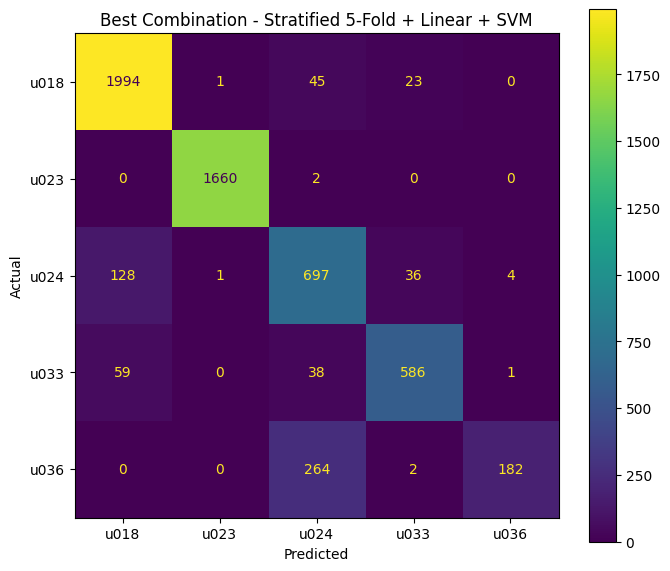

Saved: C:\Users\vatsa\Parkinson_Project\results\BEST_CONFUSION_MATRIX.png


In [117]:
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=selected_users
)

disp.plot(
    ax=plt.gca(),
    values_format="d"
)

plt.title(
    "Best Combination - Stratified 5-Fold + Linear + SVM"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

best_cm_path = (
    results_path /
    "BEST_CONFUSION_MATRIX.png"
)

plt.savefig(
    best_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", best_cm_path)

In [118]:
worst_cm = confusion_matrix(
    kf_linear_true,
    kf_linear_pred,
    labels=selected_users
)

print(worst_cm)

[[1948    0   39   73    3]
 [   0 1660    1    0    1]
 [ 343    0  486   22   15]
 [  81    0   28  575    0]
 [   3    0  262    1  182]]


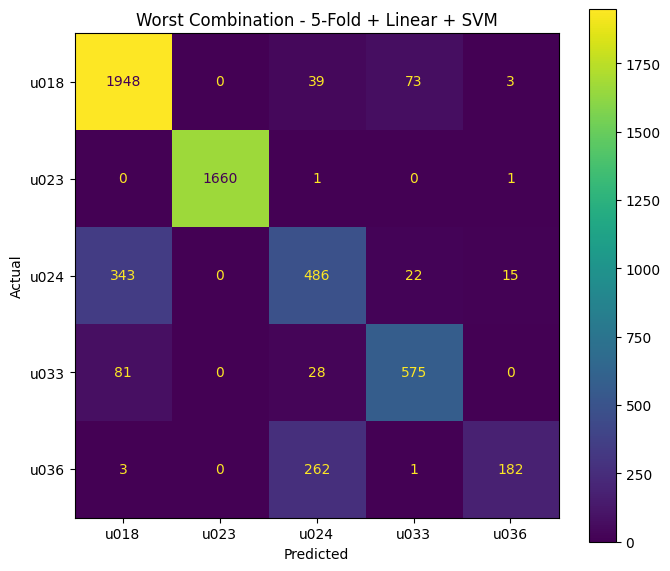

Saved: C:\Users\vatsa\Parkinson_Project\results\WORST_CONFUSION_MATRIX.png


In [119]:
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=worst_cm,
    display_labels=selected_users
)

disp.plot(
    ax=plt.gca(),
    values_format="d"
)

plt.title(
    "Worst Combination - 5-Fold + Linear + SVM"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

worst_cm_path = (
    results_path /
    "WORST_CONFUSION_MATRIX.png"
)

plt.savefig(
    worst_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", worst_cm_path)

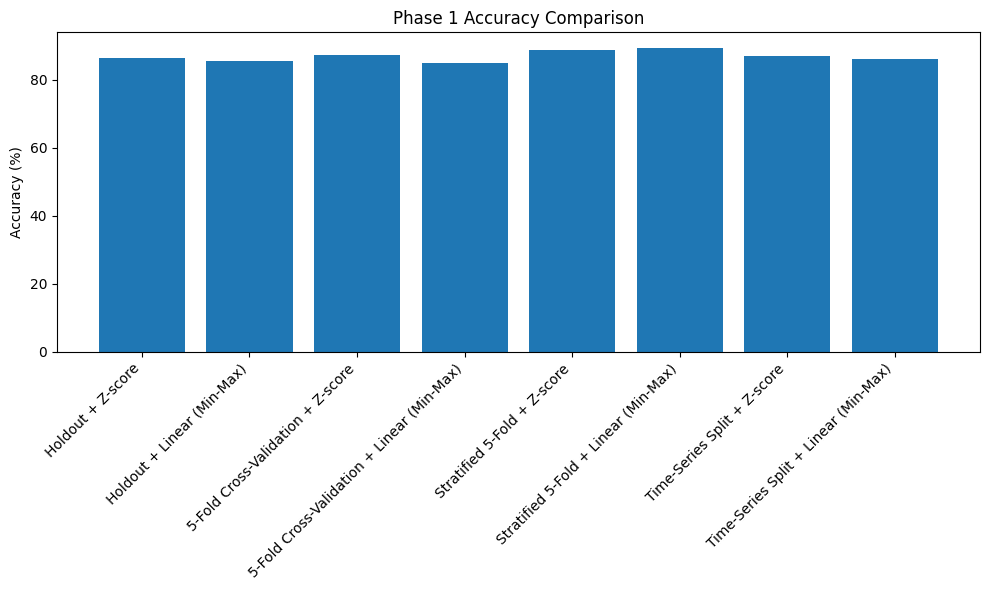

In [120]:
plt.figure(figsize=(10, 6))

labels = (
    phase1_master["Validation"]
    + " + "
    + phase1_master["Normalization"]
)

plt.bar(
    range(len(phase1_master)),
    phase1_master["Accuracy (%)"]
)

plt.xticks(
    range(len(phase1_master)),
    labels,
    rotation=45,
    ha="right"
)

plt.ylabel("Accuracy (%)")
plt.title("Phase 1 Accuracy Comparison")

plt.tight_layout()

plt.savefig(
    results_path / "PHASE1_ACCURACY_COMPARISON.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

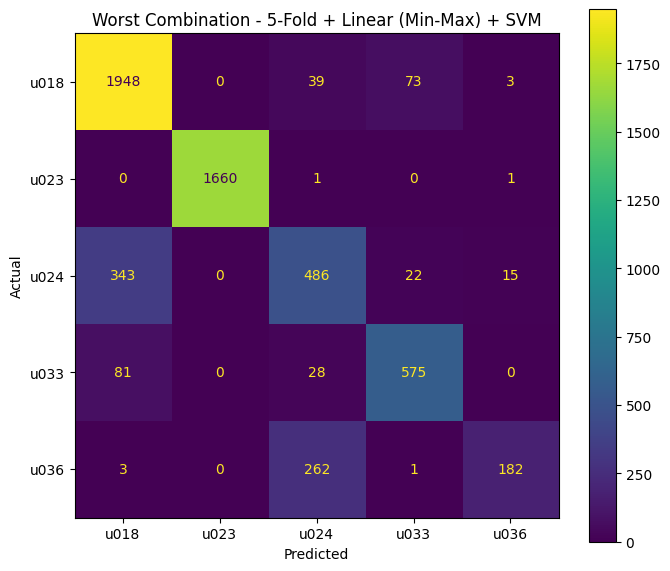

Saved: C:\Users\vatsa\Parkinson_Project\results\WORST_CONFUSION_MATRIX.png


In [121]:
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=worst_cm,
    display_labels=selected_users
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Worst Combination - 5-Fold + Linear (Min-Max) + SVM"
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()

worst_cm_path = (
    results_path /
    "WORST_CONFUSION_MATRIX.png"
)

plt.savefig(
    worst_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    worst_cm_path
)

In [123]:
best_cm_df = pd.DataFrame(
    best_cm,
    index=selected_users,
    columns=selected_users
)

worst_cm_df = pd.DataFrame(
    worst_cm,
    index=selected_users,
    columns=selected_users
)

best_cm_df.to_csv(
    results_path /
    "BEST_CONFUSION_MATRIX.csv"
)

worst_cm_df.to_csv(
    results_path /
    "WORST_CONFUSION_MATRIX.csv"
)

print("Best and worst confusion matrices saved as CSV.")


Best and worst confusion matrices saved as CSV.


In [124]:
phase1_results = pd.DataFrame([
    {
        "Validation": "Holdout",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 86.31,
        "FAR (%)": 3.44,
        "FRR (%)": 23.15
    },
    {
        "Validation": "Holdout",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 85.40,
        "FAR (%)": 3.62,
        "FRR (%)": 23.50
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 87.12,
        "FAR (%)": 3.44,
        "FRR (%)": 22.53
    },
    {
        "Validation": "5-Fold Cross-Validation",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 84.76,
        "FAR (%)": 4.15,
        "FRR (%)": 24.98
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 88.80,
        "FAR (%)": 2.97,
        "FRR (%)": 20.52
    },
    {
        "Validation": "Stratified 5-Fold",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 89.45,
        "FAR (%)": 2.73,
        "FRR (%)": 19.34
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Z-score",
        "Model": "SVM",
        "Accuracy (%)": 86.84,
        "FAR (%)": 3.17,
        "FRR (%)": 24.77
    },
    {
        "Validation": "Time-Series Split",
        "Normalization": "Linear (Min-Max)",
        "Model": "SVM",
        "Accuracy (%)": 85.98,
        "FAR (%)": 3.78,
        "FRR (%)": 24.14
    }
])

print(phase1_results)

                Validation     Normalization Model  Accuracy (%)  FAR (%)  \
0                  Holdout           Z-score   SVM         86.31     3.44   
1                  Holdout  Linear (Min-Max)   SVM         85.40     3.62   
2  5-Fold Cross-Validation           Z-score   SVM         87.12     3.44   
3  5-Fold Cross-Validation  Linear (Min-Max)   SVM         84.76     4.15   
4        Stratified 5-Fold           Z-score   SVM         88.80     2.97   
5        Stratified 5-Fold  Linear (Min-Max)   SVM         89.45     2.73   
6        Time-Series Split           Z-score   SVM         86.84     3.17   
7        Time-Series Split  Linear (Min-Max)   SVM         85.98     3.78   

   FRR (%)  
0    23.15  
1    23.50  
2    22.53  
3    24.98  
4    20.52  
5    19.34  
6    24.77  
7    24.14  


In [125]:
best_accuracy = phase1_results.loc[
    phase1_results["Accuracy (%)"].idxmax()
]

worst_accuracy = phase1_results.loc[
    phase1_results["Accuracy (%)"].idxmin()
]

lowest_far = phase1_results.loc[
    phase1_results["FAR (%)"].idxmin()
]

lowest_frr = phase1_results.loc[
    phase1_results["FRR (%)"].idxmin()
]

print("BEST ACCURACY:")
print(best_accuracy)

print("\nWORST ACCURACY:")
print(worst_accuracy)

print("\nLOWEST FAR:")
print(lowest_far)

print("\nLOWEST FRR:")
print(lowest_frr)

BEST ACCURACY:
Validation       Stratified 5-Fold
Normalization     Linear (Min-Max)
Model                          SVM
Accuracy (%)                 89.45
FAR (%)                       2.73
FRR (%)                      19.34
Name: 5, dtype: object

WORST ACCURACY:
Validation       5-Fold Cross-Validation
Normalization           Linear (Min-Max)
Model                                SVM
Accuracy (%)                       84.76
FAR (%)                             4.15
FRR (%)                            24.98
Name: 3, dtype: object

LOWEST FAR:
Validation       Stratified 5-Fold
Normalization     Linear (Min-Max)
Model                          SVM
Accuracy (%)                 89.45
FAR (%)                       2.73
FRR (%)                      19.34
Name: 5, dtype: object

LOWEST FRR:
Validation       Stratified 5-Fold
Normalization     Linear (Min-Max)
Model                          SVM
Accuracy (%)                 89.45
FAR (%)                       2.73
FRR (%)                      19.

In [126]:
phase1_results.to_csv(
    results_path /
    "PHASE1_COMPLETE_RESULTS.csv",
    index=False
)

print(
    "Saved:",
    results_path / "PHASE1_COMPLETE_RESULTS.csv"
)

Saved: C:\Users\vatsa\Parkinson_Project\results\PHASE1_COMPLETE_RESULTS.csv


In [128]:
best_val = best_accuracy["Validation"]
best_norm = best_accuracy["Normalization"]
best_model = best_accuracy["Model"]

conclusion = f"""
PHASE 1 PRELIMINARY CONCLUSION
==============================

Among the completed normalization and validation experiments,
the highest observed accuracy was obtained using:

Validation:
{best_val}

Normalization:
{best_norm}

Model:
{best_model}

Accuracy:
{best_accuracy["Accuracy (%)"]:.2f}%

FAR:
{best_accuracy["FAR (%)"]:.2f}%

FRR:
{best_accuracy["FRR (%)"]:.2f}%

The same combination also produced the lowest FAR and FRR
among the currently completed combinations.

The lowest-accuracy completed combination was:

Validation:
{worst_accuracy["Validation"]}

Normalization:
{worst_accuracy["Normalization"]}

Model:
{worst_accuracy["Model"]}

Accuracy:
{worst_accuracy["Accuracy (%)"]:.2f}%

These results are based on the IDNet sample dataset and
therefore demonstrate the behavior of the processing and
classification pipeline rather than Parkinson disease
diagnosis.

Some normalization techniques specified in the project
instructions still require their exact intended definitions
before they can be included in the complete normalization
comparison.
"""

with open(
    results_path /
    "PHASE1_PRELIMINARY_CONCLUSION.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(conclusion)

print("Conclusion saved.")

Conclusion saved.


In [130]:
print("Training recordings:", len(holdout_train_recordings))
print("Validation recordings:", len(holdout_val_recordings))

print(
    "Overlap:",
    set(holdout_train_recordings)
    & set(holdout_val_recordings)
)

Training recordings: 28
Validation recordings: 8
Overlap: set()


In [131]:
print("CNN train data available:",
      "X_train_raw_final" in globals())

print("CNN test/validation data available:",
      "X_val_raw_final" in globals())

CNN train data available: False
CNN test/validation data available: False


In [132]:
selected_users = [
    "u018",
    "u023",
    "u024",
    "u033",
    "u036"
]

print(selected_users)

['u018', 'u023', 'u024', 'u033', 'u036']


In [133]:
phase1_checkpoint = results_path / "PHASE1_RESULTS_CHECKPOINT.csv"

phase1_results.to_csv(
    phase1_checkpoint,
    index=False
)

print(
    "Checkpoint saved:",
    phase1_checkpoint
)

Checkpoint saved: C:\Users\vatsa\Parkinson_Project\results\PHASE1_RESULTS_CHECKPOINT.csv


In [134]:
print("prepare_sensor:", "prepare_sensor" in globals())
print("process_recording:", "process_recording" in globals())

prepare_sensor: False
process_recording: False


In [136]:
print("prepare_sensor:", "prepare_sensor" in globals())
print("process_recording:", "process_recording" in globals())

print("window function candidates:")

for name in globals():
    if "window" in name.lower():
        print(name)

prepare_sensor: False
process_recording: False
window function candidates:


In [140]:
print("prepare_sensor" in globals())

True


In [145]:
print("data" in globals())

False


In [146]:
for name in globals():
    if name.lower() == "data":
        print(name)

In [147]:
def load_sensor_data(recording_name):
    """
    Load the main sensor files for a given IDNet recording.
    """

    folder = data_path / recording_name

    files = {
        "accelerometer":
            folder / f"{recording_name}_accelerometer.log",

        "gyroscope":
            folder / f"{recording_name}_gyroscope.log",

        "magnetometer":
            folder / f"{recording_name}_magnetometer.log"
    }

    sensor_data = {}

    for name, path in files.items():

        if not path.exists():
            raise FileNotFoundError(
                f"Missing {name} file: {path}"
            )

        df = pd.read_csv(
            path,
            sep="\t"
        )

        sensor_data[name] = df

    return sensor_data

In [148]:
test_sensor_data = load_sensor_data(
    "u001_w001"
)

print(
    test_sensor_data.keys()
)

for name, df in test_sensor_data.items():
    print(
        name,
        df.shape
    )

dict_keys(['accelerometer', 'gyroscope', 'magnetometer'])
accelerometer (31977, 4)
gyroscope (52900, 4)
magnetometer (15985, 4)


In [155]:
print("process_recording" in globals())

True


In [156]:
test_windows = process_recording(
    data_path / "u001_w001"
)

print("Shape:", test_windows.shape)
print("One window:", test_windows[0].shape)

Shape: (106, 300, 9)
One window: (300, 9)


In [157]:
# --------------------------------------------------
# Process holdout training recordings
# --------------------------------------------------

X_ensemble_train_raw = []
y_ensemble_train_raw = []

for recording_name in holdout_train_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    X_ensemble_train_raw.append(
        windows
    )

    y_ensemble_train_raw.extend(
        [label] * len(windows)
    )

    print(
        f"TRAIN: {recording_name} → {windows.shape}"
    )


# --------------------------------------------------
# Process holdout validation recordings
# --------------------------------------------------

X_ensemble_val_raw = []
y_ensemble_val_raw = []

for recording_name in holdout_val_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    X_ensemble_val_raw.append(
        windows
    )

    y_ensemble_val_raw.extend(
        [label] * len(windows)
    )

    print(
        f"VAL: {recording_name} → {windows.shape}"
    )


# Combine recordings
X_ensemble_train_raw = np.concatenate(
    X_ensemble_train_raw,
    axis=0
)

X_ensemble_val_raw = np.concatenate(
    X_ensemble_val_raw,
    axis=0
)

y_ensemble_train_raw = np.array(
    y_ensemble_train_raw
)

y_ensemble_val_raw = np.array(
    y_ensemble_val_raw
)

print("\nFinal ensemble CNN data:")
print(
    "Training:",
    X_ensemble_train_raw.shape,
    y_ensemble_train_raw.shape
)

print(
    "Validation:",
    X_ensemble_val_raw.shape,
    y_ensemble_val_raw.shape
)

TRAIN: u018_w010 → (166, 300, 9)
TRAIN: u018_w004 → (238, 300, 9)
TRAIN: u024_w005 → (124, 300, 9)
TRAIN: u036_w001 → (99, 300, 9)
TRAIN: u023_w004 → (170, 300, 9)
TRAIN: u023_w001 → (137, 300, 9)
TRAIN: u033_w002 → (60, 300, 9)
TRAIN: u023_w002 → (144, 300, 9)
TRAIN: u023_w011 → (201, 300, 9)
TRAIN: u036_w004 → (78, 300, 9)
TRAIN: u033_w004 → (190, 300, 9)
TRAIN: u033_w003 → (145, 300, 9)
TRAIN: u024_w006 → (109, 300, 9)
TRAIN: u018_w001 → (329, 300, 9)
TRAIN: u018_w002 → (238, 300, 9)
TRAIN: u024_w003 → (102, 300, 9)
TRAIN: u023_w006 → (186, 300, 9)
TRAIN: u018_w006 → (166, 300, 9)
TRAIN: u033_w001 → (166, 300, 9)
TRAIN: u018_w013 → (231, 300, 9)
TRAIN: u018_w007 → (385, 300, 9)
TRAIN: u024_w001 → (142, 300, 9)
TRAIN: u023_w009 → (225, 300, 9)
TRAIN: u024_w007 → (166, 300, 9)
TRAIN: u036_w002 → (151, 300, 9)
TRAIN: u023_w005 → (114, 300, 9)
TRAIN: u023_w008 → (87, 300, 9)
TRAIN: u023_w010 → (147, 300, 9)
VAL: u024_w002 → (94, 300, 9)
VAL: u036_w003 → (117, 300, 9)
VAL: u018_w005 → (1

In [158]:
# Convert to float
X_ensemble_train_raw = (
    X_ensemble_train_raw.astype(np.float32)
)

X_ensemble_val_raw = (
    X_ensemble_val_raw.astype(np.float32)
)

# Channel-wise mean/std from TRAINING data only
cnn_mean = X_ensemble_train_raw.mean(
    axis=(0, 1),
    keepdims=True
)

cnn_std = X_ensemble_train_raw.std(
    axis=(0, 1),
    keepdims=True
)

cnn_std[cnn_std == 0] = 1.0

# Normalize
X_ensemble_train_scaled = (
    X_ensemble_train_raw - cnn_mean
) / cnn_std

X_ensemble_val_scaled = (
    X_ensemble_val_raw - cnn_mean
) / cnn_std

print(
    "Training mean:",
    X_ensemble_train_scaled.mean()
)

print(
    "Training std:",
    X_ensemble_train_scaled.std()
)

print(
    "Training shape:",
    X_ensemble_train_scaled.shape
)

print(
    "Validation shape:",
    X_ensemble_val_scaled.shape
)

Training mean: -3.4921388e-06
Training std: 1.0003769
Training shape: (4696, 300, 9)
Validation shape: (1138, 300, 9)


In [159]:
selected_users = [
    "u018",
    "u023",
    "u024",
    "u033",
    "u036"
]

In [160]:
from sklearn.preprocessing import LabelEncoder

ensemble_label_encoder = LabelEncoder()

ensemble_label_encoder.fit(
    selected_users
)

y_ensemble_train_encoded = (
    ensemble_label_encoder.transform(
        y_ensemble_train_raw
    )
)

y_ensemble_val_encoded = (
    ensemble_label_encoder.transform(
        y_ensemble_val_raw
    )
)

print(
    "Classes:",
    ensemble_label_encoder.classes_
)

Classes: ['u018' 'u023' 'u024' 'u033' 'u036']


In [161]:
import torch

X_ensemble_train_tensor = torch.tensor(
    X_ensemble_train_scaled,
    dtype=torch.float32
).permute(0, 2, 1)

X_ensemble_val_tensor = torch.tensor(
    X_ensemble_val_scaled,
    dtype=torch.float32
).permute(0, 2, 1)

y_ensemble_train_tensor = torch.tensor(
    y_ensemble_train_encoded,
    dtype=torch.long
)

y_ensemble_val_tensor = torch.tensor(
    y_ensemble_val_encoded,
    dtype=torch.long
)

print(
    "Training:",
    X_ensemble_train_tensor.shape,
    y_ensemble_train_tensor.shape
)

print(
    "Validation:",
    X_ensemble_val_tensor.shape,
    y_ensemble_val_tensor.shape
)

Training: torch.Size([4696, 9, 300]) torch.Size([4696])
Validation: torch.Size([1138, 9, 300]) torch.Size([1138])


In [162]:
from torch.utils.data import TensorDataset, DataLoader

ensemble_train_dataset = TensorDataset(
    X_ensemble_train_tensor,
    y_ensemble_train_tensor
)

ensemble_val_dataset = TensorDataset(
    X_ensemble_val_tensor,
    y_ensemble_val_tensor
)

ensemble_train_loader = DataLoader(
    ensemble_train_dataset,
    batch_size=64,
    shuffle=True
)

ensemble_val_loader = DataLoader(
    ensemble_val_dataset,
    batch_size=64,
    shuffle=False
)

print(
    "Training batches:",
    len(ensemble_train_loader)
)

print(
    "Validation batches:",
    len(ensemble_val_loader)
)

Training batches: 74
Validation batches: 18


In [164]:
import torch
import torch.nn as nn

In [165]:
import torch.nn as nn

class EnsembleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                9,
                32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [166]:
ensemble_cnn = EnsembleCNN(
    num_classes=5
).to(device)

print(ensemble_cnn)

NameError: name 'device' is not defined

In [167]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [168]:
ensemble_cnn = EnsembleCNN(
    num_classes=5
).to(device)

print(ensemble_cnn)

EnsembleCNN(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [169]:
criterion_ensemble = nn.CrossEntropyLoss()

optimizer_ensemble = torch.optim.Adam(
    ensemble_cnn.parameters(),
    lr=0.001
)

num_epochs = 20

best_val_acc_ensemble = 0.0

best_ensemble_path = (
    results_path /
    "ensemble_holdout_cnn_best.pth"
)

for epoch in range(num_epochs):

    ensemble_cnn.train()

    running_loss = 0.0

    for X_batch, y_batch in ensemble_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_ensemble.zero_grad()

        outputs = ensemble_cnn(X_batch)

        loss = criterion_ensemble(
            outputs,
            y_batch
        )

        loss.backward()
        optimizer_ensemble.step()

        running_loss += loss.item()

    avg_loss = (
        running_loss /
        len(ensemble_train_loader)
    )

    ensemble_cnn.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in ensemble_val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = ensemble_cnn(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    val_acc = correct / total

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Validation Accuracy: {val_acc * 100:.2f}%"
    )

    if val_acc > best_val_acc_ensemble:

        best_val_acc_ensemble = val_acc

        torch.save(
            ensemble_cnn.state_dict(),
            best_ensemble_path
        )

        print("  ✓ Best model saved")

Epoch 01/20 | Loss: 0.8740 | Validation Accuracy: 69.07%
  ✓ Best model saved
Epoch 02/20 | Loss: 0.2322 | Validation Accuracy: 71.53%
  ✓ Best model saved
Epoch 03/20 | Loss: 0.1251 | Validation Accuracy: 68.80%
Epoch 04/20 | Loss: 0.0874 | Validation Accuracy: 71.35%
Epoch 05/20 | Loss: 0.0624 | Validation Accuracy: 73.37%
  ✓ Best model saved
Epoch 06/20 | Loss: 0.0469 | Validation Accuracy: 72.85%
Epoch 07/20 | Loss: 0.0377 | Validation Accuracy: 74.78%
  ✓ Best model saved
Epoch 08/20 | Loss: 0.0282 | Validation Accuracy: 76.63%
  ✓ Best model saved
Epoch 09/20 | Loss: 0.0221 | Validation Accuracy: 73.73%
Epoch 10/20 | Loss: 0.0172 | Validation Accuracy: 76.01%
Epoch 11/20 | Loss: 0.0140 | Validation Accuracy: 74.96%
Epoch 12/20 | Loss: 0.0117 | Validation Accuracy: 73.99%
Epoch 13/20 | Loss: 0.0095 | Validation Accuracy: 75.48%
Epoch 14/20 | Loss: 0.0081 | Validation Accuracy: 75.04%
Epoch 15/20 | Loss: 0.0067 | Validation Accuracy: 72.93%
Epoch 16/20 | Loss: 0.0058 | Validation 

In [170]:
import torch.nn as nn

class EnsembleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                9,
                32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [171]:
ensemble_cnn = EnsembleCNN(
    num_classes=5
).to(device)

print(ensemble_cnn)

EnsembleCNN(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [172]:
# Load the best CNN checkpoint
ensemble_cnn.load_state_dict(
    torch.load(
        best_ensemble_path,
        map_location=device
    )
)

ensemble_cnn.eval()

cnn_ensemble_predictions = []
cnn_ensemble_actual = []

with torch.no_grad():

    for X_batch, y_batch in ensemble_val_loader:

        X_batch = X_batch.to(device)

        outputs = ensemble_cnn(
            X_batch
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        cnn_ensemble_predictions.extend(
            predictions.cpu().numpy()
        )

        cnn_ensemble_actual.extend(
            y_batch.numpy()
        )

cnn_ensemble_predictions = np.array(
    cnn_ensemble_predictions
)

cnn_ensemble_actual = np.array(
    cnn_ensemble_actual
)

print(
    "CNN prediction shape:",
    cnn_ensemble_predictions.shape
)

print(
    "Actual shape:",
    cnn_ensemble_actual.shape
)

CNN prediction shape: (1138,)
Actual shape: (1138,)


In [173]:
cnn_ensemble_labels = (
    ensemble_label_encoder.inverse_transform(
        cnn_ensemble_predictions
    )
)

cnn_ensemble_actual_labels = (
    ensemble_label_encoder.inverse_transform(
        cnn_ensemble_actual
    )
)

cnn_holdout_accuracy = accuracy_score(
    cnn_ensemble_actual_labels,
    cnn_ensemble_labels
)

print(
    f"CNN Holdout Accuracy: "
    f"{cnn_holdout_accuracy * 100:.2f}%"
)

CNN Holdout Accuracy: 76.63%


In [174]:
print(
    "SVM prediction count:",
    len(holdout_pred_zscore)
)

print(
    "SVM actual count:",
    len(holdout_y_val)
)

SVM prediction count: 1096
SVM actual count: 1096


In [175]:
print(
    "SVM validation samples:",
    len(holdout_pred_zscore)
)

print(
    "CNN validation samples:",
    len(cnn_ensemble_predictions)
)

print(
    "SVM actual samples:",
    len(holdout_y_val)
)

print(
    "CNN actual samples:",
    len(cnn_ensemble_actual_labels)
)

SVM validation samples: 1096
CNN validation samples: 1138
SVM actual samples: 1096
CNN actual samples: 1138


In [176]:
# Count CNN windows for each validation recording
cnn_counts = {}

for recording_name in holdout_val_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    cnn_counts[recording_name] = len(windows)


# Count SVM feature rows for each validation recording
svm_counts = (
    holdout_val_df
    .groupby("recording")
    .size()
    .to_dict()
)

print("Recording-wise comparison:\n")

for recording_name in holdout_val_recordings:

    print(
        f"{recording_name}: "
        f"CNN = {cnn_counts.get(recording_name, 0)}, "
        f"SVM = {svm_counts.get(recording_name, 0)}"
    )

Recording-wise comparison:

u024_w002: CNN = 94, SVM = 83
u036_w003: CNN = 117, SVM = 117
u018_w005: CNN = 142, SVM = 141
u018_w008: CNN = 238, SVM = 212
u023_w007: CNN = 105, SVM = 102
u024_w004: CNN = 165, SVM = 166
u023_w003: CNN = 175, SVM = 172
u033_w005: CNN = 102, SVM = 103


In [177]:
print("CNN validation label counts:")
print(
    pd.Series(
        y_ensemble_val_raw
    ).value_counts()
)

print("\nSVM validation label counts:")
print(
    holdout_y_val.value_counts()
)

CNN validation label counts:
u018    380
u023    280
u024    259
u036    117
u033    102
Name: count, dtype: int64

SVM validation label counts:
label
u018    353
u023    274
u024    249
u036    117
u033    103
Name: count, dtype: int64


In [178]:
# --------------------------------------------------
# Generate 90 features from the SAME windows
# used by the CNN ensemble pipeline
# --------------------------------------------------

ensemble_train_features = []
ensemble_train_labels = []
ensemble_train_recordings = []
ensemble_train_window_ids = []

ensemble_val_features = []
ensemble_val_labels = []
ensemble_val_recordings = []
ensemble_val_window_ids = []


# ==================================================
# TRAINING RECORDINGS
# ==================================================

for recording_name in holdout_train_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window_id, window in enumerate(windows):

        features = extract_improved_features(
            window
        )

        ensemble_train_features.append(
            features
        )

        ensemble_train_labels.append(
            label
        )

        ensemble_train_recordings.append(
            recording_name
        )

        ensemble_train_window_ids.append(
            window_id
        )

    print(
        f"TRAIN: {recording_name} → "
        f"{len(windows)} windows"
    )


# ==================================================
# VALIDATION RECORDINGS
# ==================================================

for recording_name in holdout_val_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window_id, window in enumerate(windows):

        features = extract_improved_features(
            window
        )

        ensemble_val_features.append(
            features
        )

        ensemble_val_labels.append(
            label
        )

        ensemble_val_recordings.append(
            recording_name
        )

        ensemble_val_window_ids.append(
            window_id
        )

    print(
        f"VAL: {recording_name} → "
        f"{len(windows)} windows"
    )


# ==================================================
# Convert to DataFrames
# ==================================================

ensemble_train_features_df = pd.DataFrame(
    ensemble_train_features
)

ensemble_val_features_df = pd.DataFrame(
    ensemble_val_features
)

# Add metadata
ensemble_train_features_df["recording"] = (
    ensemble_train_recordings
)

ensemble_train_features_df["window_id"] = (
    ensemble_train_window_ids
)

ensemble_train_features_df["label"] = (
    ensemble_train_labels
)

ensemble_val_features_df["recording"] = (
    ensemble_val_recordings
)

ensemble_val_features_df["window_id"] = (
    ensemble_val_window_ids
)

ensemble_val_features_df["label"] = (
    ensemble_val_labels
)


print("\nGenerated feature data:")

print(
    "Training:",
    ensemble_train_features_df.shape
)

print(
    "Validation:",
    ensemble_val_features_df.shape
)

NameError: name 'extract_improved_features' is not defined

In [187]:
print("extract_improved_features:", "extract_improved_features" in globals())
print("extract_frequency_features:", "extract_frequency_features" in globals())
print("zero_crossing_rate:", "zero_crossing_rate" in globals())

extract_improved_features: True
extract_frequency_features: False
zero_crossing_rate: False


In [192]:
print(
    "zero_crossing_rate:",
    "zero_crossing_rate" in globals()
)

zero_crossing_rate: True


In [197]:
print(
    "extract_frequency_features:",
    "extract_frequency_features" in globals()
)

extract_frequency_features: True


In [198]:
print(
    "extract_improved_features:",
    "extract_improved_features" in globals()
)

print(
    "extract_frequency_features:",
    "extract_frequency_features" in globals()
)

print(
    "zero_crossing_rate:",
    "zero_crossing_rate" in globals()
)

extract_improved_features: True
extract_frequency_features: True
zero_crossing_rate: True


In [199]:
# --------------------------------------------------
# Generate 90 features from the SAME windows
# used by the CNN ensemble pipeline
# --------------------------------------------------

ensemble_train_features = []
ensemble_train_labels = []
ensemble_train_recordings = []
ensemble_train_window_ids = []

ensemble_val_features = []
ensemble_val_labels = []
ensemble_val_recordings = []
ensemble_val_window_ids = []


# ==================================================
# TRAINING RECORDINGS
# ==================================================

for recording_name in holdout_train_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window_id, window in enumerate(windows):

        features = extract_improved_features(
            window
        )

        ensemble_train_features.append(features)
        ensemble_train_labels.append(label)
        ensemble_train_recordings.append(recording_name)
        ensemble_train_window_ids.append(window_id)

    print(
        f"TRAIN: {recording_name} → "
        f"{len(windows)} windows"
    )


# ==================================================
# VALIDATION RECORDINGS
# ==================================================

for recording_name in holdout_val_recordings:

    windows = process_recording(
        data_path / recording_name
    )

    label = recording_name.split("_")[0]

    for window_id, window in enumerate(windows):

        features = extract_improved_features(
            window
        )

        ensemble_val_features.append(features)
        ensemble_val_labels.append(label)
        ensemble_val_recordings.append(recording_name)
        ensemble_val_window_ids.append(window_id)

    print(
        f"VAL: {recording_name} → "
        f"{len(windows)} windows"
    )


# ==================================================
# Convert to DataFrames
# ==================================================

ensemble_train_features_df = pd.DataFrame(
    ensemble_train_features
)

ensemble_val_features_df = pd.DataFrame(
    ensemble_val_features
)

# Add metadata
ensemble_train_features_df["recording"] = (
    ensemble_train_recordings
)

ensemble_train_features_df["window_id"] = (
    ensemble_train_window_ids
)

ensemble_train_features_df["label"] = (
    ensemble_train_labels
)

ensemble_val_features_df["recording"] = (
    ensemble_val_recordings
)

ensemble_val_features_df["window_id"] = (
    ensemble_val_window_ids
)

ensemble_val_features_df["label"] = (
    ensemble_val_labels
)


print("\nGenerated feature data:")

print(
    "Training:",
    ensemble_train_features_df.shape
)

print(
    "Validation:",
    ensemble_val_features_df.shape
)

TRAIN: u018_w010 → 166 windows
TRAIN: u018_w004 → 238 windows
TRAIN: u024_w005 → 124 windows
TRAIN: u036_w001 → 99 windows
TRAIN: u023_w004 → 170 windows
TRAIN: u023_w001 → 137 windows
TRAIN: u033_w002 → 60 windows
TRAIN: u023_w002 → 144 windows
TRAIN: u023_w011 → 201 windows
TRAIN: u036_w004 → 78 windows
TRAIN: u033_w004 → 190 windows
TRAIN: u033_w003 → 145 windows
TRAIN: u024_w006 → 109 windows
TRAIN: u018_w001 → 329 windows
TRAIN: u018_w002 → 238 windows
TRAIN: u024_w003 → 102 windows
TRAIN: u023_w006 → 186 windows
TRAIN: u018_w006 → 166 windows
TRAIN: u033_w001 → 166 windows
TRAIN: u018_w013 → 231 windows
TRAIN: u018_w007 → 385 windows
TRAIN: u024_w001 → 142 windows
TRAIN: u023_w009 → 225 windows
TRAIN: u024_w007 → 166 windows
TRAIN: u036_w002 → 151 windows
TRAIN: u023_w005 → 114 windows
TRAIN: u023_w008 → 87 windows
TRAIN: u023_w010 → 147 windows
VAL: u024_w002 → 94 windows
VAL: u036_w003 → 117 windows
VAL: u018_w005 → 142 windows
VAL: u018_w008 → 238 windows
VAL: u023_w007 → 105 

In [200]:
print(
    "CNN training windows:",
    len(X_ensemble_train_raw)
)

print(
    "Feature training rows:",
    len(ensemble_train_features_df)
)

print(
    "CNN validation windows:",
    len(X_ensemble_val_raw)
)

print(
    "Feature validation rows:",
    len(ensemble_val_features_df)
)

CNN training windows: 4696
Feature training rows: 4696
CNN validation windows: 1138
Feature validation rows: 1138


In [201]:
cnn_keys = list(
    zip(
        ensemble_train_recordings,
        ensemble_train_window_ids
    )
)

feature_train_keys = list(
    zip(
        ensemble_train_features_df["recording"],
        ensemble_train_features_df["window_id"]
    )
)

cnn_val_keys = list(
    zip(
        ensemble_val_recordings,
        ensemble_val_window_ids
    )
)

feature_val_keys = list(
    zip(
        ensemble_val_features_df["recording"],
        ensemble_val_features_df["window_id"]
    )
)

print(
    "Training order matches:",
    cnn_keys == feature_train_keys
)

print(
    "Validation order matches:",
    cnn_val_keys == feature_val_keys
)

Training order matches: True
Validation order matches: True


In [202]:
print(
    "Training labels match:",
    np.array_equal(
        y_ensemble_train_raw,
        ensemble_train_features_df["label"].to_numpy()
    )
)

print(
    "Validation labels match:",
    np.array_equal(
        y_ensemble_val_raw,
        ensemble_val_features_df["label"].to_numpy()
    )
)

Training labels match: True
Validation labels match: True


In [203]:
ensemble_X_train_rf = ensemble_train_features_df[
    ensemble_feature_columns
]

ensemble_X_val_rf = ensemble_val_features_df[
    ensemble_feature_columns
]

ensemble_y_train_rf = ensemble_train_features_df[
    "label"
]

ensemble_y_val_rf = ensemble_val_features_df[
    "label"
]

NameError: name 'ensemble_feature_columns' is not defined

In [204]:
ensemble_feature_columns = [
    col
    for col in ensemble_train_features_df.columns
    if col not in [
        "recording",
        "window_id",
        "label"
    ]
]

print(
    "Number of ensemble features:",
    len(ensemble_feature_columns)
)

print(
    "First 10 features:",
    ensemble_feature_columns[:10]
)

Number of ensemble features: 90
First 10 features: ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_median', 'acc_x_range', 'acc_x_rms', 'acc_x_zcr', 'acc_x_dominant_freq', 'acc_x_spectral_energy']


In [205]:
ensemble_X_train_rf = ensemble_train_features_df[
    ensemble_feature_columns
]

ensemble_X_val_rf = ensemble_val_features_df[
    ensemble_feature_columns
]

ensemble_y_train_rf = ensemble_train_features_df[
    "label"
]

ensemble_y_val_rf = ensemble_val_features_df[
    "label"
]

print(
    "RF training shape:",
    ensemble_X_train_rf.shape
)

print(
    "RF validation shape:",
    ensemble_X_val_rf.shape
)

RF training shape: (4696, 90)
RF validation shape: (1138, 90)


In [206]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

ensemble_rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

ensemble_rf.fit(
    ensemble_X_train_rf,
    ensemble_y_train_rf
)

rf_ensemble_predictions = ensemble_rf.predict(
    ensemble_X_val_rf
)

rf_ensemble_accuracy = accuracy_score(
    ensemble_y_val_rf,
    rf_ensemble_predictions
)

print(
    "RF predictions:",
    len(rf_ensemble_predictions)
)

print(
    f"RF Holdout Accuracy: "
    f"{rf_ensemble_accuracy * 100:.2f}%"
)

RF predictions: 1138
RF Holdout Accuracy: 84.01%


In [207]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

ensemble_svm_scaler = StandardScaler()

X_svm_train = ensemble_svm_scaler.fit_transform(
    ensemble_X_train_rf
)

X_svm_val = ensemble_svm_scaler.transform(
    ensemble_X_val_rf
)

ensemble_svm = SVC(
    kernel="rbf",
    random_state=42
)

ensemble_svm.fit(
    X_svm_train,
    ensemble_y_train_rf
)

svm_ensemble_predictions = ensemble_svm.predict(
    X_svm_val
)

svm_ensemble_accuracy = accuracy_score(
    ensemble_y_val_rf,
    svm_ensemble_predictions
)

print(
    "SVM predictions:",
    len(svm_ensemble_predictions)
)

print(
    f"SVM Holdout Accuracy: "
    f"{svm_ensemble_accuracy * 100:.2f}%"
)

SVM predictions: 1138
SVM Holdout Accuracy: 86.20%


In [208]:
print(
    "RF predictions:",
    len(rf_ensemble_predictions)
)

print(
    "SVM predictions:",
    len(svm_ensemble_predictions)
)

print(
    "CNN predictions:",
    len(cnn_ensemble_predictions)
)

print(
    "Actual labels:",
    len(ensemble_y_val_rf)
)

RF predictions: 1138
SVM predictions: 1138
CNN predictions: 1138
Actual labels: 1138


In [209]:
cnn_actual_labels = (
    ensemble_label_encoder.inverse_transform(
        cnn_ensemble_actual
    )
)

print(
    "RF actual == CNN actual:",
    np.array_equal(
        ensemble_y_val_rf.to_numpy(),
        cnn_actual_labels
    )
)

RF actual == CNN actual: True


In [210]:
from collections import Counter
import numpy as np

rf_predictions = np.array(
    rf_ensemble_predictions
)

svm_predictions = np.array(
    svm_ensemble_predictions
)

cnn_predictions = np.array(
    cnn_ensemble_labels
)

actual_labels = np.array(
    ensemble_y_val_rf
)

ensemble_predictions = []

for rf_pred, svm_pred, cnn_pred in zip(
    rf_predictions,
    svm_predictions,
    cnn_predictions
):

    votes = [
        rf_pred,
        svm_pred,
        cnn_pred
    ]

    majority_vote = Counter(
        votes
    ).most_common(1)[0][0]

    ensemble_predictions.append(
        majority_vote
    )

ensemble_predictions = np.array(
    ensemble_predictions
)

print(
    "Ensemble predictions:",
    len(ensemble_predictions)
)

Ensemble predictions: 1138


In [211]:
ensemble_accuracy = accuracy_score(
    actual_labels,
    ensemble_predictions
)

print(
    f"RF + SVM + CNN Ensemble Accuracy: "
    f"{ensemble_accuracy * 100:.2f}%"
)

RF + SVM + CNN Ensemble Accuracy: 84.80%


In [212]:
ensemble_far, ensemble_frr = (
    multiclass_far_frr(
        actual_labels,
        ensemble_predictions,
        selected_users
    )
)

print(
    f"Ensemble FAR: "
    f"{ensemble_far * 100:.2f}%"
)

print(
    f"Ensemble FRR: "
    f"{ensemble_frr * 100:.2f}%"
)

Ensemble FAR: 3.80%
Ensemble FRR: 25.03%


In [213]:
ensemble_cm = confusion_matrix(
    actual_labels,
    ensemble_predictions,
    labels=selected_users
)

print(
    "Ensemble confusion matrix:"
)

print(ensemble_cm)

Ensemble confusion matrix:
[[380   0   0   0   0]
 [  0 279   1   0   0]
 [  2   2 210  45   0]
 [  2   0   4  96   0]
 [  0   3 114   0   0]]


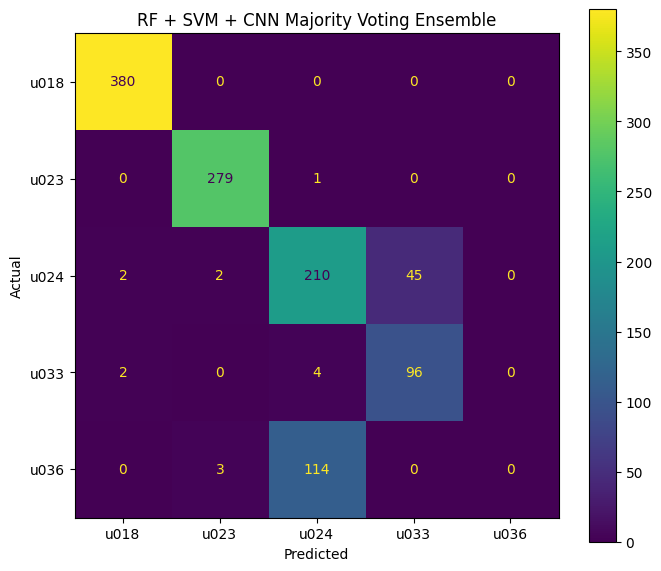

Saved: C:\Users\vatsa\Parkinson_Project\results\RF_SVM_CNN_ENSEMBLE_CONFUSION_MATRIX.png


In [214]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(7, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_cm,
    display_labels=selected_users
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "RF + SVM + CNN Majority Voting Ensemble"
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()

ensemble_cm_path = (
    results_path /
    "RF_SVM_CNN_ENSEMBLE_CONFUSION_MATRIX.png"
)

plt.savefig(
    ensemble_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    ensemble_cm_path
)

In [215]:
ensemble_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Input": "90 handcrafted features",
        "Validation": "Holdout",
        "Accuracy (%)": rf_ensemble_accuracy * 100
    },
    {
        "Model": "SVM",
        "Input": "90 handcrafted features + Z-score",
        "Validation": "Holdout",
        "Accuracy (%)": svm_ensemble_accuracy * 100
    },
    {
        "Model": "1D CNN",
        "Input": "Raw 300x9 windows + Z-score",
        "Validation": "Holdout",
        "Accuracy (%)": cnn_holdout_accuracy * 100
    },
    {
        "Model": "RF + SVM + CNN Ensemble",
        "Input": "Majority voting",
        "Validation": "Holdout",
        "Accuracy (%)": ensemble_accuracy * 100,
        "FAR (%)": ensemble_far * 100,
        "FRR (%)": ensemble_frr * 100
    }
])

print(ensemble_results)

ensemble_results.to_csv(
    results_path /
    "MODEL_ENSEMBLE_RESULTS.csv",
    index=False
)

print(
    "Saved:",
    results_path / "MODEL_ENSEMBLE_RESULTS.csv"
)

                     Model                              Input Validation  \
0            Random Forest            90 handcrafted features    Holdout   
1                      SVM  90 handcrafted features + Z-score    Holdout   
2                   1D CNN        Raw 300x9 windows + Z-score    Holdout   
3  RF + SVM + CNN Ensemble                    Majority voting    Holdout   

   Accuracy (%)   FAR (%)    FRR (%)  
0     84.007030       NaN        NaN  
1     86.203866       NaN        NaN  
2     76.625659       NaN        NaN  
3     84.797891  3.798439  25.031683  
Saved: C:\Users\vatsa\Parkinson_Project\results\MODEL_ENSEMBLE_RESULTS.csv


In [216]:
ensemble_cm_df = pd.DataFrame(
    ensemble_cm,
    index=selected_users,
    columns=selected_users
)

ensemble_cm_df.to_csv(
    results_path / "RF_SVM_CNN_ENSEMBLE_CONFUSION_MATRIX.csv"
)

print("Ensemble confusion matrix saved.")

Ensemble confusion matrix saved.


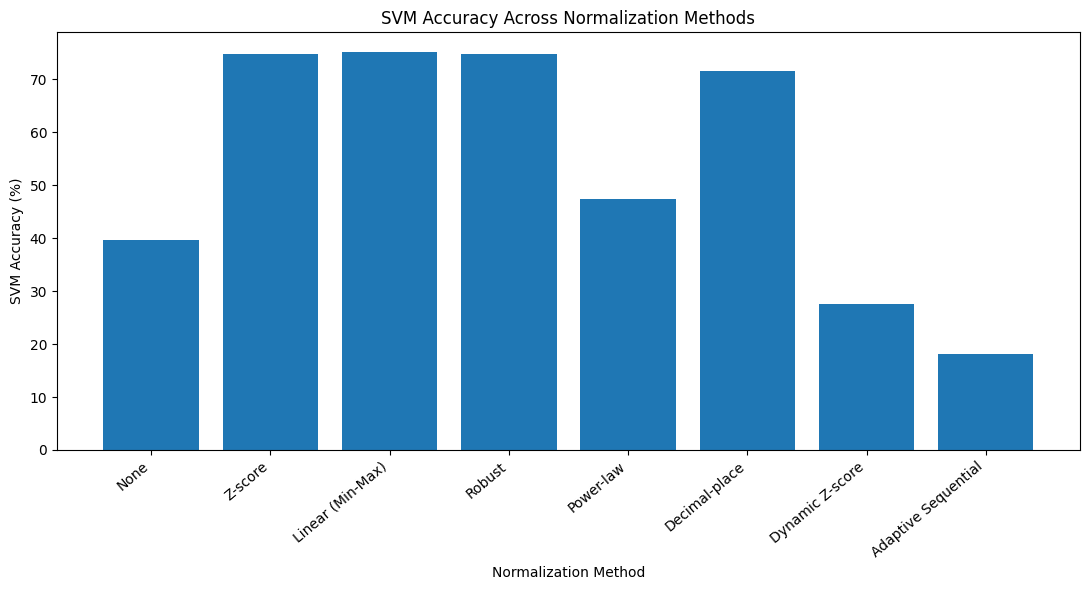

Saved: C:\Users\vatsa\Parkinson_Project\results\NORMALIZATION_SVM_ACCURACY_COMPARISON.png


In [217]:
import matplotlib.pyplot as plt

norm_results_plot = normalization_baseline.copy()

plt.figure(figsize=(11, 6))

plt.bar(
    norm_results_plot["Normalization"],
    norm_results_plot["Accuracy (%)"]
)

plt.ylabel("SVM Accuracy (%)")
plt.xlabel("Normalization Method")
plt.title(
    "SVM Accuracy Across Normalization Methods"
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.tight_layout()

normalization_plot_path = (
    results_path /
    "NORMALIZATION_SVM_ACCURACY_COMPARISON.png"
)

plt.savefig(
    normalization_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    normalization_plot_path
)

In [218]:
normalization_report = normalization_baseline.copy()

normalization_report = (
    normalization_report
    .sort_values(
        "Accuracy (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

normalization_report.to_csv(
    results_path /
    "NORMALIZATION_COMPARISON_FINAL.csv",
    index=False
)

print(normalization_report)

         Normalization Model  Accuracy (%)
0     Linear (Min-Max)   SVM     75.152253
1              Z-score   SVM     74.786845
2               Robust   SVM     74.786845
3        Decimal-place   SVM     71.619976
4            Power-law   SVM     47.381242
5                 None   SVM     39.707674
6      Dynamic Z-score   SVM     27.527406
7  Adaptive Sequential   SVM     18.148599


In [219]:
best_norm = normalization_report.iloc[0]
worst_norm = normalization_report.iloc[-1]

observation = f"""
Normalization experiment observation
====================================

Model:
SVM

Evaluation:
Holdout test split used for this normalization comparison.

Highest observed accuracy:
{best_norm["Normalization"]} = {best_norm["Accuracy (%)"]:.2f}%

Lowest observed accuracy:
{worst_norm["Normalization"]} = {worst_norm["Accuracy (%)"]:.2f}%

The results show that normalization substantially changes
SVM performance for this feature set.

The best observed method in this experiment was
Linear (Min-Max) normalization at 75.15%.

The worst observed method was Adaptive Sequential
normalization at 18.15%.

These observations are specific to the current IDNet sample
dataset, feature representation, SVM configuration, and
holdout experiment.
"""

with open(
    results_path /
    "NORMALIZATION_OBSERVATIONS.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(observation)

print("Observation saved.")

Observation saved.
